In [25]:
import pickle
import pandas as pd

tcn_bigru = pickle.load(open("results_tcn_bigru.pkl", "rb"))
tcn       = pickle.load(open("results_tcn.pkl", "rb"))
bigru     = pickle.load(open("results_bigru.pkl", "rb"))

# Langsung pakai
metrics_data = {
    "Model": ["TCN-BiGRU", "TCN", "BiGRU"],
    "RMSE":  [tcn_bigru["rmse"],  tcn["rmse"],  bigru["rmse"]],
    "MAE":   [tcn_bigru["mae"],   tcn["mae"],   bigru["mae"]],
    "MAPE":  [tcn_bigru["mape"],  tcn["mape"],  bigru["mape"]],
    "R²":    [tcn_bigru["r2"],    tcn["r2"],    bigru["r2"]],
}

forecast_h1 = {
    "Model":        ["TCN-BiGRU", "TCN", "BiGRU"],
    "Forecast H+1": [tcn_bigru["forecast_h1"], tcn["forecast_h1"], bigru["forecast_h1"]],
}

forecast_dates        = pd.to_datetime(tcn_bigru["forecast_30_dates"])  # tanggal sama semua
forecast_30_tcn_bigru = tcn_bigru["forecast_30_prices"]
forecast_30_tcn       = tcn["forecast_30_prices"]
forecast_30_bigru     = bigru["forecast_30_prices"]

best_splits = {
    "TCN-BiGRU":  tcn_bigru["best_split"],
    "TCN":   tcn["best_split"],
    "BiGRU": bigru["best_split"],
}

last_actual_price = tcn_bigru["last_actual_price"]
last_actual_date  = tcn_bigru["last_actual_date"]

In [24]:
print("Isi key tcn_bigru:", tcn_bigru.keys())

Isi key tcn_bigru: dict_keys(['rmse', 'mae', 'mape', 'r2', 'forecast_h1', 'forecast_30_dates', 'forecast_30_prices', 'best_split', 'last_actual_price', 'last_actual_date', 'total_time', 'tuning_times', 'all_results', 'tuning_table_data'])


In [3]:
print("TCN-BiGRU best_params:", tcn_bigru["best_split"], "→", tcn_bigru.get("all_results", [{}])[0].get("best_params"))
print("TCN       best_params:", tcn["all_results"][0].get("best_params"))
print("BiGRU     best_params:", bigru["all_results"][0].get("best_params"))

# Atau cek langsung semua keys
print("\nSemua keys TCN-BiGRU:", list(tcn_bigru.keys()))

TCN-BiGRU best_params: (0.6, 0.2, 0.2) → (64, 3, (1, 2, 4), 64, 0.2, 8, 0.0015)
TCN       best_params: (64, 2, (1, 2, 4), 0.1, 16, 0.0015)
BiGRU     best_params: (64, 0.2, 8, 0.001)

Semua keys TCN-BiGRU: ['rmse', 'mae', 'mape', 'r2', 'forecast_h1', 'forecast_30_dates', 'forecast_30_prices', 'best_split', 'last_actual_price', 'last_actual_date', 'total_time', 'tuning_times', 'all_results', 'tuning_table_data']


TABEL RANGKUMAN AKHIR — SEMUA MODEL

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_summary_final = pd.DataFrame([
    {
        "Model":        "TCN",
        "Best Split":   str(tcn["best_split"]),
        "RMSE":         round(tcn["rmse"], 4),
        "MAE":          round(tcn["mae"], 4),
        "MAPE (%)":     round(tcn["mape"], 4),
        "R²":           round(tcn["r2"], 4),
        "Forecast H+1": round(tcn["forecast_h1"], 3),
        # Mengambil waktu dari best model via 'training_time_sec'
        "Time Processing (s)": round(tcn["all_results"][0].get("training_time_sec", 0), 3),
    },
    {
        "Model":        "BiGRU",
        "Best Split":   str(bigru["best_split"]),
        "RMSE":         round(bigru["rmse"], 4),
        "MAE":          round(bigru["mae"], 4),
        "MAPE (%)":     round(bigru["mape"], 4),
        "R²":           round(bigru["r2"], 4),
        "Forecast H+1": round(bigru["forecast_h1"], 3),
        "Time Processing (s)": round(bigru["all_results"][0].get("training_time_sec", 0), 3),
    },
    {
        "Model":        "TCN-BiGRU",
        "Best Split":   str(tcn_bigru["best_split"]),
        "RMSE":         round(tcn_bigru["rmse"], 4),
        "MAE":          round(tcn_bigru["mae"], 4),
        "MAPE (%)":     round(tcn_bigru["mape"], 4),
        "R²":           round(tcn_bigru["r2"], 4),
        "Forecast H+1": round(tcn_bigru["forecast_h1"], 3),
        "Time Processing (s)": round(tcn_bigru["all_results"][0].get("training_time_sec", 0), 3),
    }
])

print("=" * 70)
print("TABEL RANGKUMAN AKHIR — SEMUA MODEL")
print("=" * 70)
display(df_summary_final)

TABEL RANGKUMAN AKHIR — SEMUA MODEL


,Model,Best Split,RMSE,MAE,MAPE (%),R²,Forecast H+1,Time Processing (s)
0,TCN,"(0.6, 0.2, 0.2)",108.5263,76.0323,1.0580,0.9779,7161.611816,302.357
1,BiGRU,"(0.6, 0.2, 0.2)",107.1779,76.1017,1.0595,0.9785,7186.766113,288.594
2,TCN-BiGRU,"(0.6, 0.2, 0.2)",108.8965,75.6244,1.0565,0.9778,7187.790039,1481.517


In [5]:
print("Waktu TCN (Best Split & Params)      :", tcn["all_results"][0]["training_time_sec"], "detik")
print("Waktu BiGRU (Best Split & Params)    :", bigru["all_results"][0]["training_time_sec"], "detik")
print("Waktu TCN-BiGRU (Best Split & Params):", tcn_bigru["all_results"][0]["training_time_sec"], "detik")

Waktu TCN (Best Split & Params)      : 302.35713601112366 detik
Waktu BiGRU (Best Split & Params)    : 288.59364080429077 detik
Waktu TCN-BiGRU (Best Split & Params): 1481.5166347026825 detik


In [6]:
print("Keys asli dari best model:", list(tcn_bigru["all_results"][0].keys()))

Keys asli dari best model: ['split', 'best_mape', 'best_params', 'best_epoch', 'training_time_sec']


In [7]:
# ===============================
# TABEL PARAMETER TERBAIK PER MODEL
# ===============================

# Unpack best_params dari all_results (ambil yang best_split cocok)
def get_best_params(pkl):
    best_split_str = "-".join(str(x) for x in pkl["best_split"])
    match = next((r for r in pkl["all_results"] if r["split"] == best_split_str), None)
    return match["best_params"] if match else None

params_tcn_bigru = get_best_params(tcn_bigru)
params_tcn       = get_best_params(tcn)
params_bigru     = get_best_params(bigru)

# Susun tabel — kolom disesuaikan per algo
df_params = pd.DataFrame([
    {
        "Model":       "TCN",
        "Filter":      params_tcn[0],
        "Kernel Size": params_tcn[1],
        "Dilations":   str(params_tcn[2]),
        "GRU Units":   "-",
        "Dropout":     params_tcn[3],
        "Batch Size":  params_tcn[4],
        "LR":          params_tcn[5],
    },
    {
        "Model":       "BiGRU",
        "Filter":      "-",
        "Kernel Size": "-",
        "Dilations":   "-",
        "GRU Units":   params_bigru[0],
        "Dropout":     params_bigru[1],
        "Batch Size":  params_bigru[2],
        "LR":          params_bigru[3],
    },
        {
        "Model":       "TCN-BiGRU",
        "Filter":      params_tcn_bigru[0],
        "Kernel Size": params_tcn_bigru[1],
        "Dilations":   str(params_tcn_bigru[2]),
        "GRU Units":   params_tcn_bigru[3],
        "Dropout":     params_tcn_bigru[4],
        "Batch Size":  params_tcn_bigru[5],
        "LR":          params_tcn_bigru[6],
    }
])

print("=" * 70)
print("TABEL PARAMETER TERBAIK PER MODEL")
print("=" * 70)
display(df_params)

# ===============================
# GABUNG DENGAN TABEL RANGKUMAN
# ===============================
df_combined = df_summary_final.merge(df_params, on="Model")

print("\n" + "=" * 70)
print("TABEL RANGKUMAN LENGKAP — METRIK + PARAMETER TERBAIK")
print("=" * 70)
display(df_combined)

TABEL PARAMETER TERBAIK PER MODEL


,Model,Filter,Kernel Size,Dilations,GRU Units,Dropout,Batch Size,LR
0,TCN,64,2,"(1, 2, 4)",-,0.1,16,0.0015
1,BiGRU,-,-,-,64,0.2,8,0.0010
2,TCN-BiGRU,64,3,"(1, 2, 4)",64,0.2,8,0.0015



TABEL RANGKUMAN LENGKAP — METRIK + PARAMETER TERBAIK


,Model,Best Split,RMSE,MAE,MAPE (%),R²,Forecast H+1,Time Processing (s),Filter,Kernel Size,Dilations,GRU Units,Dropout,Batch Size,LR
0,TCN,"(0.6, 0.2, 0.2)",108.5263,76.0323,1.0580,0.9779,7161.611816,302.357,64,2,"(1, 2, 4)",-,0.1,16,0.0015
1,BiGRU,"(0.6, 0.2, 0.2)",107.1779,76.1017,1.0595,0.9785,7186.766113,288.594,-,-,-,64,0.2,8,0.0010
2,TCN-BiGRU,"(0.6, 0.2, 0.2)",108.8965,75.6244,1.0565,0.9778,7187.790039,1481.517,64,3,"(1, 2, 4)",64,0.2,8,0.0015


BAR CHART METRIK


FORECAST H+1 MASING-MASING MODEL


,Model,Forecast H+1 (Rp)
0,TCN-BiGRU,7188
1,TCN,7162
2,BiGRU,7187


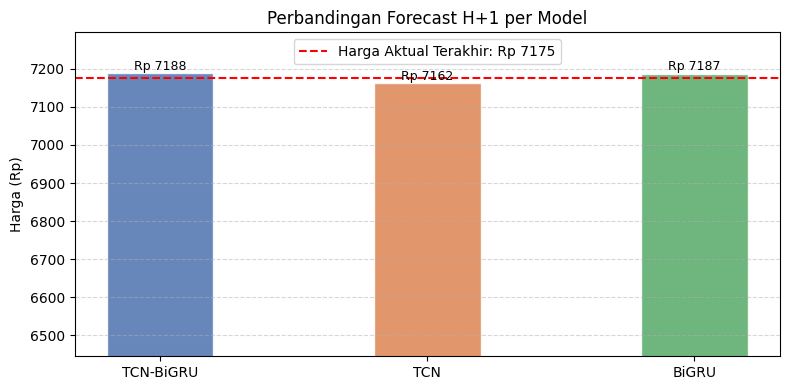

In [8]:
# ===============================
# TABEL + CHART FORECAST H+1
# ===============================
df_h1 = pd.DataFrame(forecast_h1)
df_h1 = df_h1.rename(columns={"Forecast H+1": "Forecast H+1 (Rp)"})
df_h1["Forecast H+1 (Rp)"] = df_h1["Forecast H+1 (Rp)"].map(lambda x: f"{x:.0f}")
print("\n" + "=" * 40)
print("FORECAST H+1 MASING-MASING MODEL")
print("=" * 40)
display(df_h1)

colors = ["#4C72B0", "#DD8452", "#55A868"]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(forecast_h1["Model"], forecast_h1["Forecast H+1"],
              color=colors, alpha=0.85, edgecolor='white', width=0.4)

ax.axhline(y=last_actual_price, color='red', linestyle='--', linewidth=1.5,
           label=f'Harga Aktual Terakhir: Rp {last_actual_price}')

for bar, val in zip(bars, forecast_h1["Forecast H+1"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (max(forecast_h1["Forecast H+1"]) - min(forecast_h1["Forecast H+1"])) * 0.05,
            f"Rp {val:.0f}", ha='center', va='bottom', fontsize=9)

# ← INI KUNCINYA: set ylim mulai dari sedikit di bawah nilai terendah
all_values = forecast_h1["Forecast H+1"] + [last_actual_price]
y_min = min(all_values) * 0.9   # 9% di bawah nilai terkecil
y_max = max(all_values) * 1.015   # 1.5% di atas nilai terbesar
ax.set_ylim(y_min, y_max)

ax.set_title("Perbandingan Forecast H+1 per Model")
ax.set_ylabel("Harga (Rp)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Perbandingan Metrik Antar Model

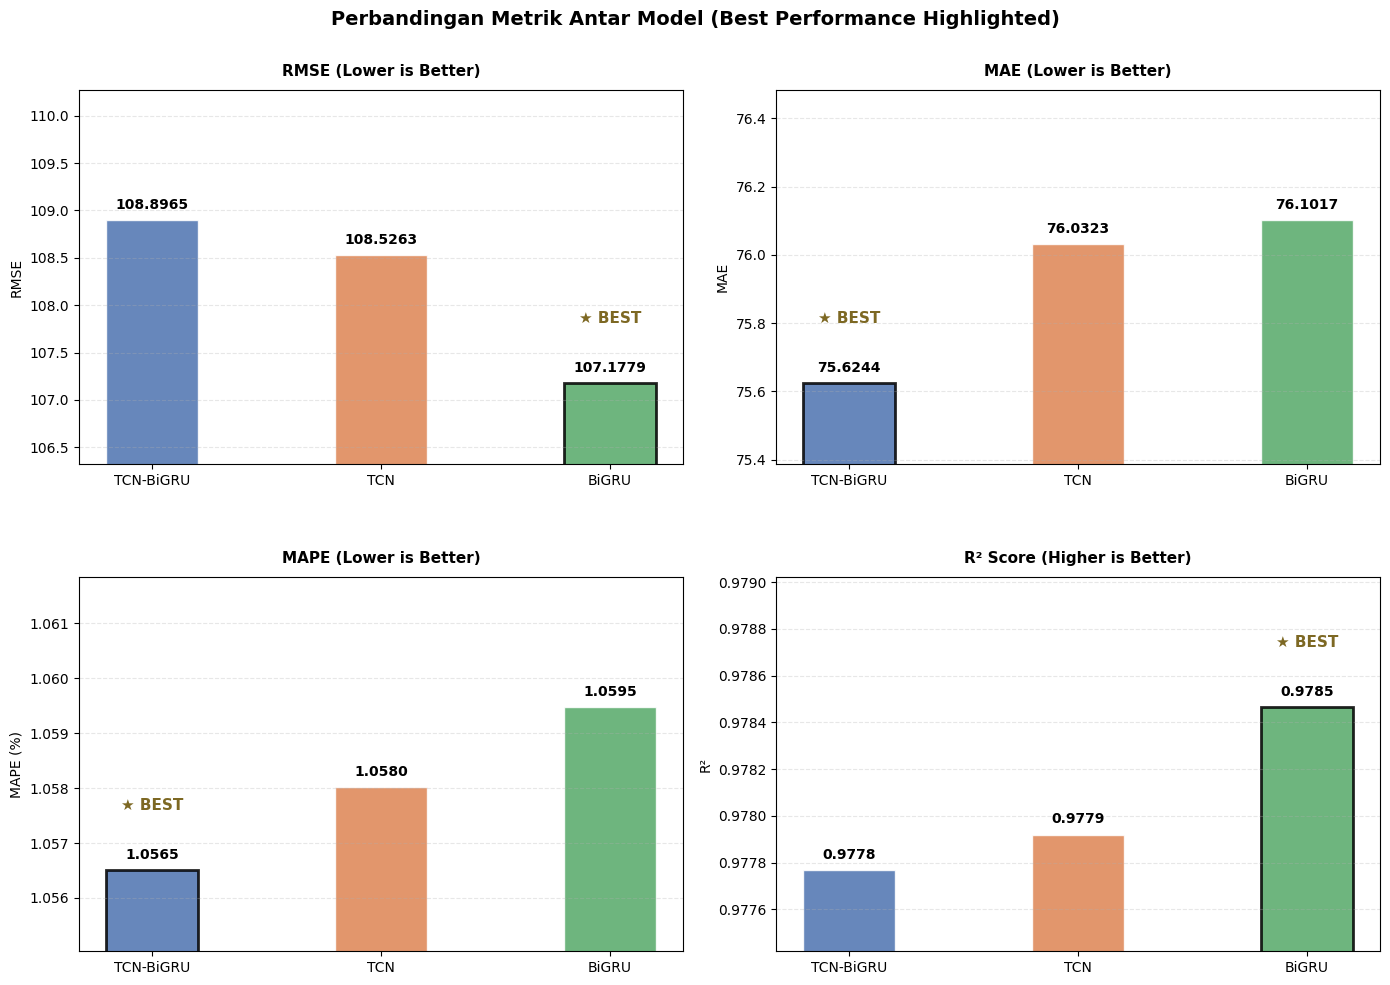

In [9]:
import numpy as np
import matplotlib.pyplot as plt

models  = ["TCN-BiGRU", "TCN", "BiGRU"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
x       = np.arange(len(models))
width   = 0.4  # Sedikit diperkecil dari 0.5 agar proporsi bar di layout 2x2 lebih pas

# Data dummy (pastikan variabel asli Anda sudah terdefinisi)
metric_info = [
    ("RMSE",     [tcn_bigru["rmse"],  tcn["rmse"],  bigru["rmse"]],  "RMSE (Lower is Better)"),
    ("MAE",      [tcn_bigru["mae"],   tcn["mae"],   bigru["mae"]],   "MAE (Lower is Better)"),
    ("MAPE (%)", [tcn_bigru["mape"],  tcn["mape"],  bigru["mape"]],  "MAPE (Lower is Better)"),
    ("R²",       [tcn_bigru["r2"],    tcn["r2"],    bigru["r2"]],    "R² Score (Higher is Better)"),
]

# --- REVISI LAYOUT: Diubah jadi 2 baris, 2 kolom dengan ukuran proporsional ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) 
fig.suptitle("Perbandingan Metrik Antar Model (Best Performance Highlighted)", fontsize=14, fontweight='bold', y=0.98)

# --- REVISI LOOPING: Gunakan axes.flatten() karena layout sekarang 2 dimensi ---
for ax, (ylabel, values, title) in zip(axes.flatten(), metric_info):
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=width)
    
    # --- BAGIAN ZOOM (SCALING) ---
    min_val = min(values)
    max_val = max(values)
    
    # Set limit y agar fokus pada rentang data (bukan mulai dari 0)
    ax.set_ylim(min_val - (max_val - min_val) * 0.5, max_val + (max_val - min_val) * 0.8)
    # ------------------------------------------

    # 1. Tentukan indeks "Best"
    if ylabel == "R²":
        best_idx = np.argmax(values)
    else:
        best_idx = np.argmin(values)

    # 2. Styling bar terbaik
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

    # 3. Tambahkan Teks Nilai dan Bintang
    for i, (bar, val) in enumerate(zip(bars, values)):
        # Teks angka di atas bar
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (max_val - min_val) * 0.05,
                f"{val:.4f}", ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
        
        # Tambahkan ★ BEST
        if i == best_idx:
            ax.text(bar.get_x() + bar.get_width()/2,
                    val + (max_val - min_val) * 0.35,
                    "★ BEST", ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color="#7D6823")

    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
# Menyesuaikan jarak bagian atas agar judul utama tidak menabrak sub-grafik
plt.subplots_adjust(top=0.90, hspace=0.3) 
plt.show()

ANALISIS TIME PROCESS

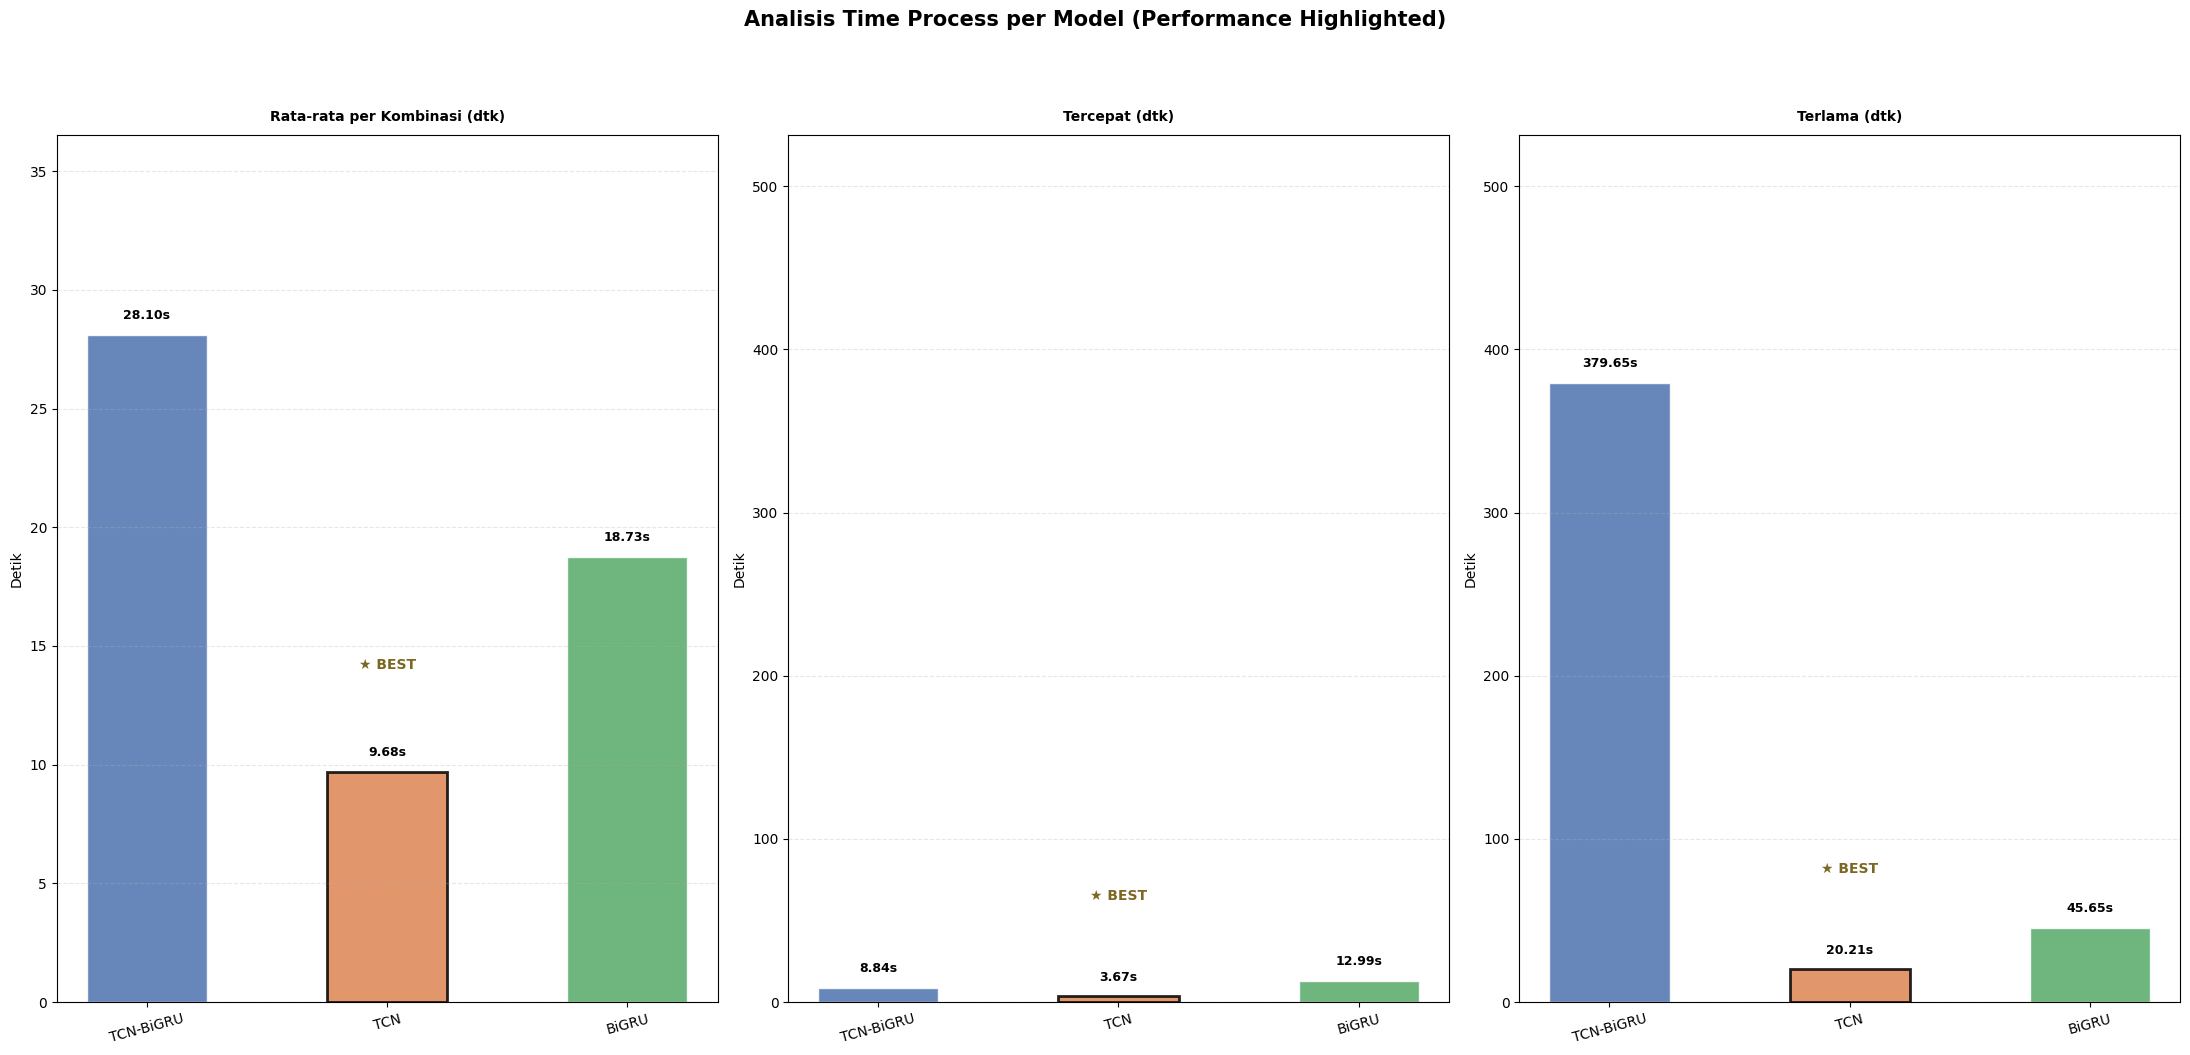

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Update Fungsi Statistik (Total Time dalam Detik)
def time_stats(pkl, model_name):
    times = pkl["tuning_times"]
    return {
        "Model":                          model_name,
        "Rata-rata per Kombinasi (dtk)":  round(np.mean(times), 2),
        "Tercepat (dtk)":                  round(np.min(times), 2),
        "Terlama (dtk)":                   round(np.max(times), 2),
        "Jumlah Kombinasi":                len(times),
    }

df_time = pd.DataFrame([
    time_stats(tcn_bigru, "TCN-BiGRU"),
    time_stats(tcn,       "TCN"),
    time_stats(bigru,     "BiGRU"),
])

# --- HITUNG SKALA Y GLOBAL UNTUK GRAFIK 2, 3, 4 ---
# Kita ambil nilai maksimum dari metrik rata-rata, tercepat, dan terlama saja
metrics_to_sync = ["Rata-rata per Kombinasi (dtk)", "Tercepat (dtk)", "Terlama (dtk)"]
global_max_sync = df_time[metrics_to_sync].values.max()
y_limit_sync = global_max_sync * 1.4 # Padding 40% untuk bintang

# --- PLOTTING ---
models  = df_time["Model"].tolist()
colors  = ["#4C72B0", "#DD8452", "#55A868"]
width   = 0.5

fig, axes = plt.subplots(1, 3, figsize=(22, 10))
fig.suptitle("Analisis Time Process per Model (Performance Highlighted)", fontsize=15, fontweight='bold', y=1.05)

time_metrics = [
    ("Rata-rata per Kombinasi (dtk)", df_time["Rata-rata per Kombinasi (dtk)"].tolist(), "Detik"),
    ("Tercepat (dtk)", df_time["Tercepat (dtk)"].tolist(), "Detik"),
    ("Terlama (dtk)", df_time["Terlama (dtk)"].tolist(), "Detik"),
]

for i, (ax, (title, values, ylabel)) in enumerate(zip(axes, time_metrics)):
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=width)
    
    # Cari yang TERCEPAT (best untuk waktu adalah nilai minimum)
    best_idx = np.argmin(values)
    
    # Set Skala Y
    if i == 0:
        # Grafik 1: Skala mandiri karena angkanya pasti jauh lebih besar
        current_max = max(values)
        ax.set_ylim(0, current_max * 1.3)
    else:
        # Grafik 2, 3, 4: Skala disamakan
        current_max = global_max_sync
        ax.set_ylim(0, y_limit_sync)

    # Anotasi
    for j, (bar, val) in enumerate(zip(bars, values)):
        # Teks Nilai
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (current_max * 0.02),
                f"{val:.2f}s", ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Bintang Gold untuk yang Best (Paling Cepat)
        if j == best_idx:
            bars[j].set_edgecolor('black')
            bars[j].set_linewidth(2)
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (current_max * 0.15),
                    "★ BEST", ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color="#7D6823")

    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

drop total training timenya

bisa coba pakai boxplot

FORECAST 30 HARI PERALGORITMA

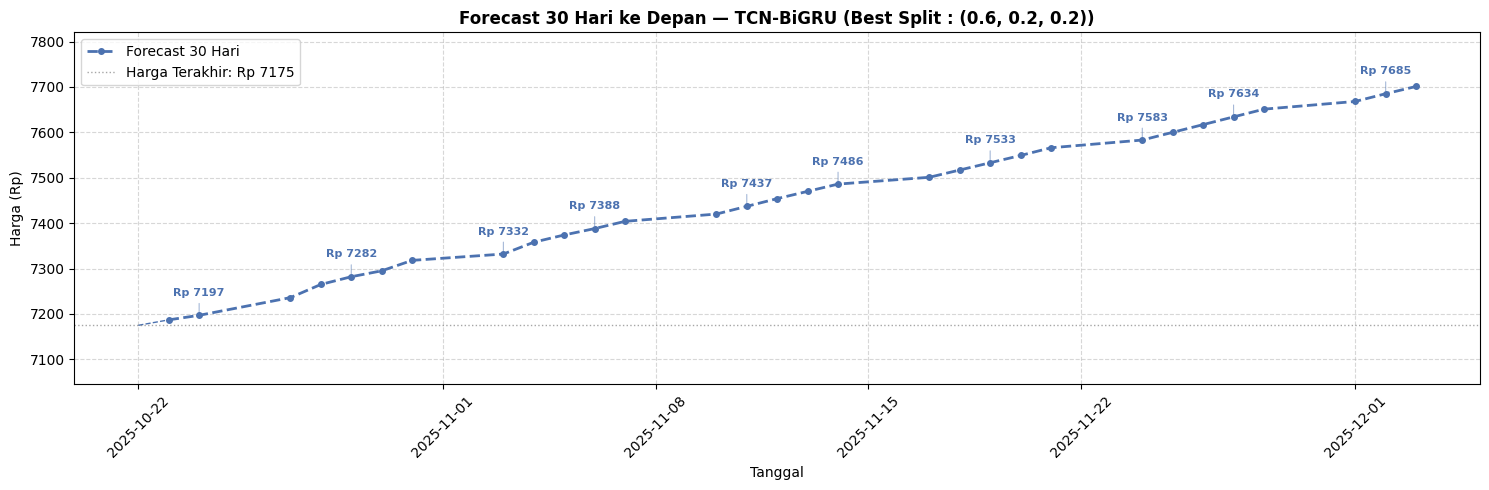

TCN-BiGRU
  Forecast Hari ke-1  : Rp 7187
  Forecast Hari ke-30 : Rp 7701



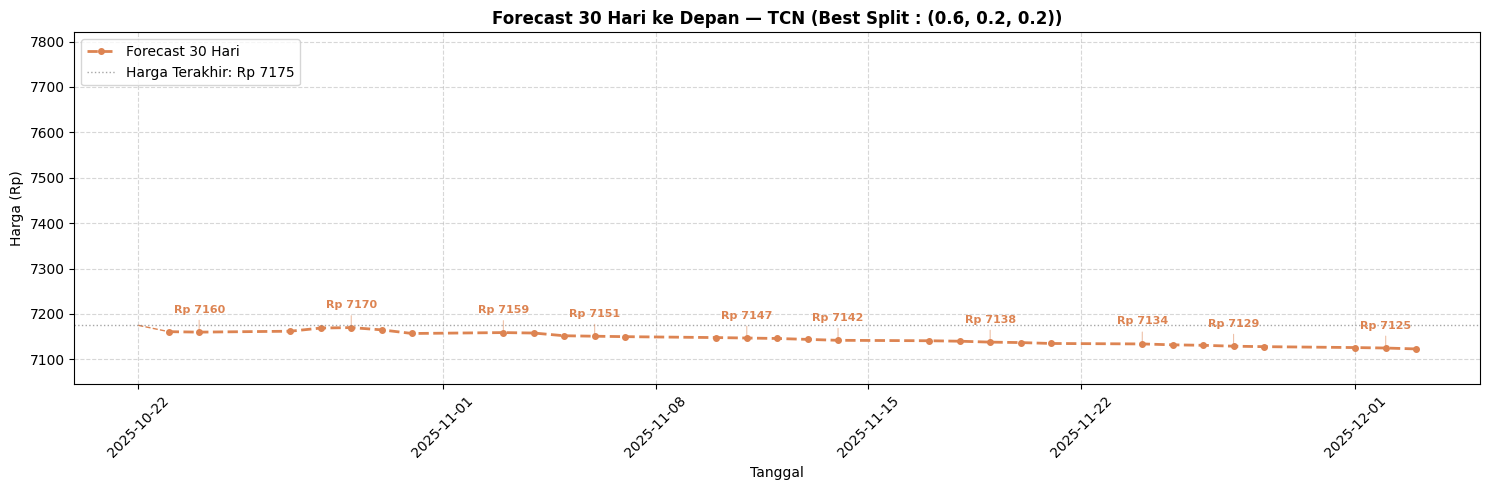

TCN
  Forecast Hari ke-1  : Rp 7161
  Forecast Hari ke-30 : Rp 7123



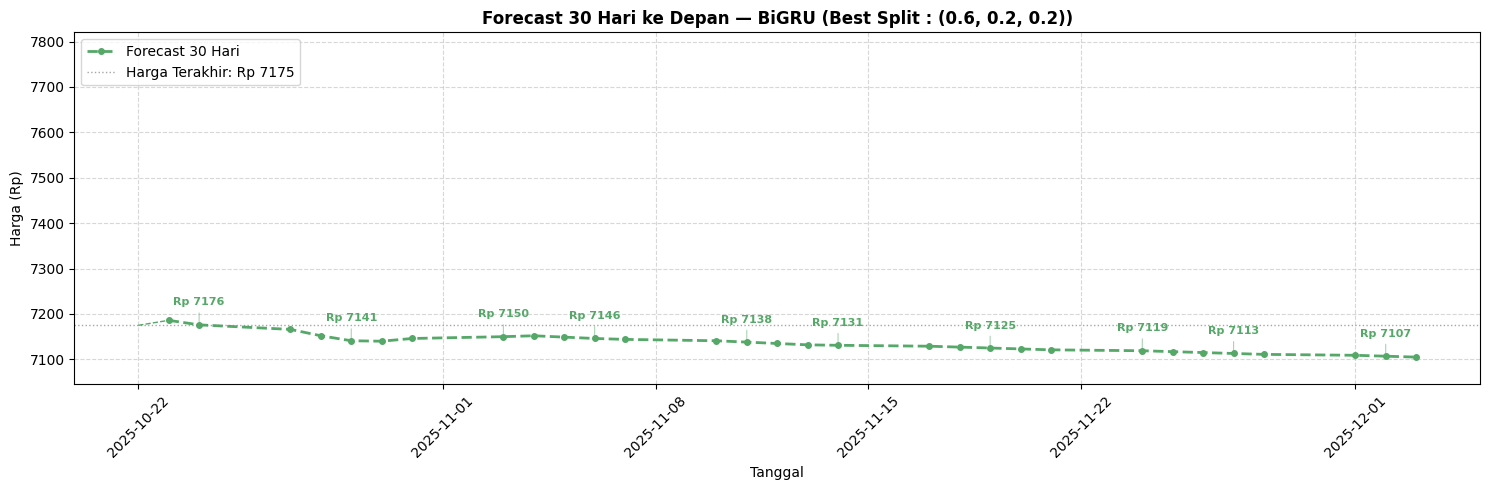

BiGRU
  Forecast Hari ke-1  : Rp 7186
  Forecast Hari ke-30 : Rp 7105



In [11]:
# =============================================================
# FORECAST 30 HARI DENGAN SUMBU Y DISERAGAMKAN
# =============================================================

forecast_data = [
    ("TCN-BiGRU",  forecast_30_tcn_bigru, colors[0], best_splits["TCN-BiGRU"]),
    ("TCN",   forecast_30_tcn,        colors[1], best_splits["TCN"]),
    ("BiGRU", forecast_30_bigru,      colors[2], best_splits["BiGRU"]),
]

# 1. CARI MIN & MAX GLOBAL UNTUK SEMUA MODEL
# Masukkan juga harga terakhir (last_actual_price) agar tidak terpotong
all_forecast_values = [last_actual_price]
for _, forecast_prices, _, _ in forecast_data:
    all_forecast_values.extend(forecast_prices)

y_min_global = min(all_forecast_values)
y_max_global = max(all_forecast_values)

# Tambahkan padding (misal 10%) agar anotasi teks tidak menabrak atap grafik
y_range = y_max_global - y_min_global
y_limit_lower = y_min_global - (y_range * 0.1)
y_limit_upper = y_max_global + (y_range * 0.2) 

# 2. LOOPING PLOT DENGAN SKALA YANG SAMA
for model_name, forecast_prices, color, best_split in forecast_data:
    fig, ax = plt.subplots(figsize=(15, 5))

    # Garis penghubung dari harga terakhir ke forecast hari ke-1
    ax.plot([last_actual_date, forecast_dates[0]],
            [last_actual_price, forecast_prices[0]],
            color=color, linestyle='--', linewidth=1)

    # Line forecast 30 hari
    ax.plot(forecast_dates, forecast_prices,
            label='Forecast 30 Hari', color=color,
            linestyle='--', linewidth=2, marker='o', markersize=4)

    # Anotasi harga tiap beberapa hari
    for j in [1, 4, 7, 10, 13, 16, 19, 22, 25, 28]:
        price = forecast_prices[j]
        date  = forecast_dates[j]
        ax.annotate(
            f"Rp {price:.0f}",
            xy=(date, price),
            xytext=(0, 14),
            textcoords="offset points",
            ha='center',
            fontsize=8,
            color=color,
            fontweight='bold',
            arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.5)
        )

    # Garis referensi harga terakhir
    ax.axhline(y=last_actual_price, color='gray', linestyle=':', linewidth=1,
               alpha=0.7, label=f'Harga Terakhir: Rp {last_actual_price:.0f}')

    # --- KUNCI: Set skala sumbu Y agar sama di semua grafik ---
    ax.set_ylim(y_limit_lower, y_limit_upper)

    ax.set_title(f"Forecast 30 Hari ke Depan — {model_name} (Best Split : {best_split})",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Harga (Rp)")
    ax.legend(loc='upper left') # Pindah posisi legend agar tidak menutupi garis
    ax.grid(linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"{model_name}")
    print(f"  Forecast Hari ke-1  : Rp {forecast_prices[0]:.0f}")
    print(f"  Forecast Hari ke-30 : Rp {forecast_prices[-1]:.0f}\n")

TABEL FORECAST 30 HARI LENGKAP

In [12]:
forecast_dates = pd.to_datetime(tcn_bigru["forecast_30_dates"])

df_forecast_all = pd.DataFrame({
    "Hari Ke-":    range(1, 31),
    "Tanggal":     [d.strftime('%Y-%m-%d') for d in forecast_dates],
    "TCN-BiGRU (Rp)":  [round(v, 3) for v in tcn_bigru["forecast_30_prices"]],
    "TCN (Rp)":   [round(v, 3) for v in tcn["forecast_30_prices"]],
    "BiGRU (Rp)": [round(v, 3) for v in bigru["forecast_30_prices"]],
})

print("=" * 60)
print("TABEL FORECAST 30 HARI — SEMUA MODEL")
print("=" * 60)
display(df_forecast_all)

# Menyimpan DataFrame ke dalam file CSV
df_forecast_all.to_csv("forecast_tcn_bigru-tcnbigru.csv", index=False)
print("✅ File CSV berhasil disimpan dengan nama: 'forecast_tcn_bigru-tcnbigru.csv'")

TABEL FORECAST 30 HARI — SEMUA MODEL


,Hari Ke-,Tanggal,TCN-BiGRU (Rp),TCN (Rp),BiGRU (Rp)
0,1,2025-10-23,7187,7161,7186
1,2,2025-10-24,7197,7160,7176
2,3,2025-10-27,7236,7162,7166
3,4,2025-10-28,7265,7169,7152
4,5,2025-10-29,7282,7170,7141
5,6,2025-10-30,7295,7165,7140
6,7,2025-10-31,7318,7157,7146
7,8,2025-11-03,7332,7159,7150
8,9,2025-11-04,7358,7158,7152
9,10,2025-11-05,7374,7152,7149


✅ File CSV berhasil disimpan dengan nama: 'forecast_tcn_bigru-tcnbigru.csv'


CHART FORECAST 30 HARI (3 model dalam 1 plot)

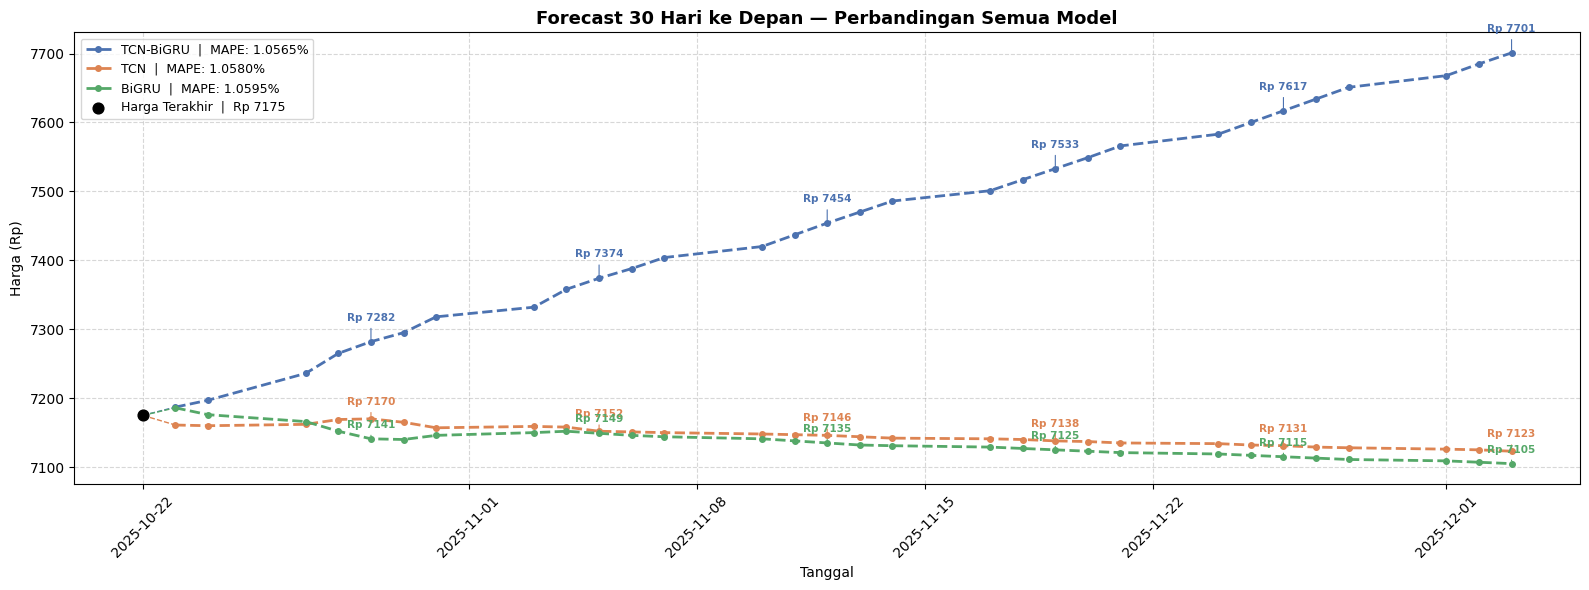

In [13]:
last_actual_price = tcn_bigru["last_actual_price"]
last_actual_date  = pd.to_datetime(tcn_bigru["last_actual_date"])

fig, ax = plt.subplots(figsize=(16, 6))

for i, (model_name, pkl, color) in enumerate([
    ("TCN-BiGRU",  tcn_bigru, colors[0]),
    ("TCN",   tcn,       colors[1]),
    ("BiGRU", bigru,     colors[2]),
]):
    prices = pkl["forecast_30_prices"]
    dates  = pd.to_datetime(pkl["forecast_30_dates"])
    mape   = pkl["mape"]

    # Garis dari harga terakhir ke hari ke-1
    ax.plot([last_actual_date, dates[0]],
            [last_actual_price, prices[0]],
            color=color, linestyle='--', linewidth=1)

    # Line forecast — label sekarang include MAPE
    ax.plot(dates, prices,
            label=f"{model_name}  |  MAPE: {mape:.4f}%",
            color=color, linestyle='--', linewidth=2,
            marker='o', markersize=4)

    # Anotasi harga tiap 5 hari (hari ke-5, 10, 15, 20, 25, 30)
    for j, (date, price) in enumerate(zip(dates, prices)):
        if (j + 1) % 5 == 0:  # hari ke-5, 10, 15, 20, 25, 30
            # offset vertikal beda tiap model biar tidak tumpuk
            offset = [15, 10, 8][i]
            ax.annotate(
                f"Rp {price:.0f}",
                xy=(date, price),
                xytext=(0, offset),
                textcoords="offset points",
                ha='center',
                fontsize=7.5,
                color=color,
                fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8)
            )

# Titik aktual terakhir
ax.scatter(last_actual_date, last_actual_price,
           color='black', zorder=5, s=60,
           label=f'Harga Terakhir  |  Rp {last_actual_price:.0f}')

ax.set_title("Forecast 30 Hari ke Depan — Perbandingan Semua Model",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Tanggal")
ax.set_ylabel("Harga (Rp)")
ax.legend(loc='best', fontsize=9)
ax.grid(linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--- CEK DATA 20 HARI TERAKHIR ---
        Tanggal  Terakhir
2385 2025-09-11    7475.0
2386 2025-09-12    7550.0
2387 2025-09-15    7650.0
2388 2025-09-16    7650.0
2389 2025-09-17    7775.0
2390 2025-09-18    7650.0
2391 2025-09-19    7825.0
2392 2025-09-22    7850.0
2393 2025-09-23    7775.0
2394 2025-09-24    7875.0
2395 2025-09-25    7750.0
2396 2025-09-26    7650.0
2397 2025-09-29    7575.0
2398 2025-09-30    7225.0
2399 2025-10-01    7100.0
2400 2025-10-02    7025.0
2401 2025-10-03    7150.0
2402 2025-10-06    7100.0
2403 2025-10-07    7225.0
2404 2025-10-08    7250.0
2405 2025-10-09    7150.0
2406 2025-10-10    7200.0
2407 2025-10-13    7200.0
2408 2025-10-14    7050.0
2409 2025-10-15    6900.0
2410 2025-10-16    7075.0
2411 2025-10-17    7125.0
2412 2025-10-20    7250.0
2413 2025-10-21    7275.0
2414 2025-10-22    7175.0


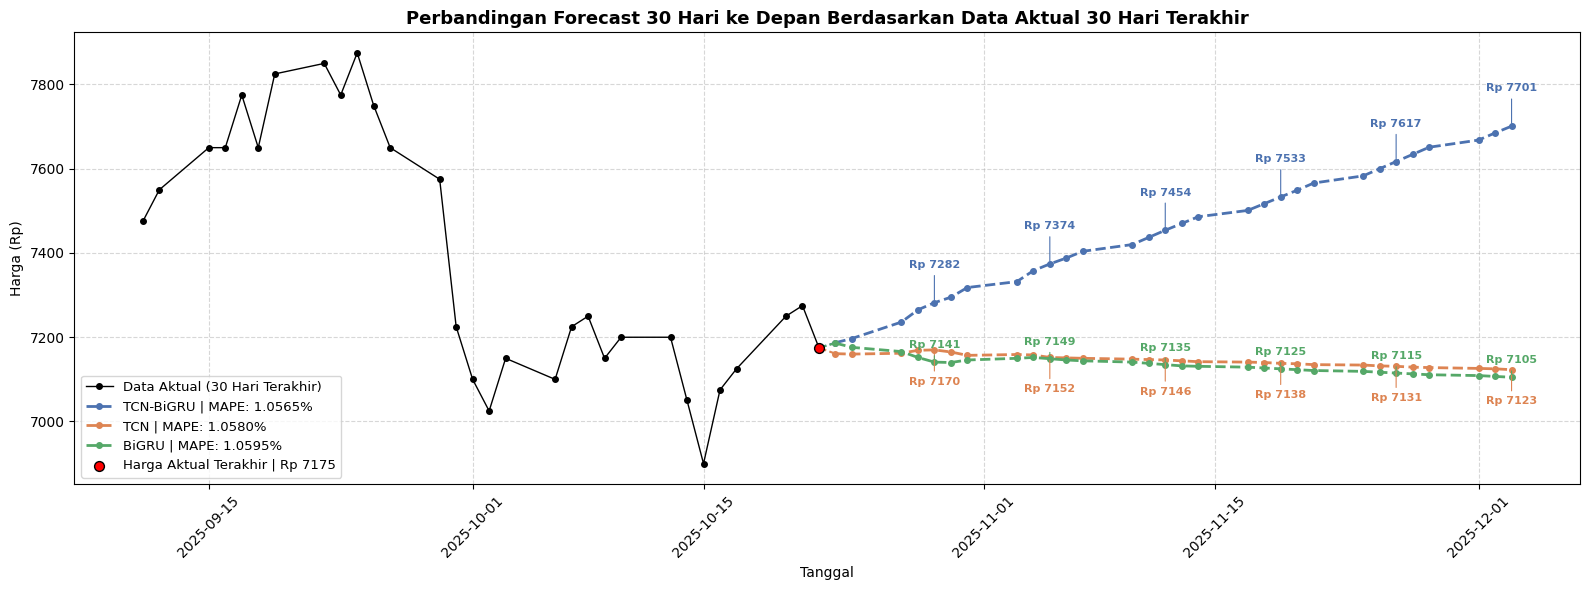

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Membaca data historis aktual dari Excel
df_aktual = pd.read_csv("Data Historis INDF.csv", delimiter=";") 

# Memastikan kolom Tanggal terbaca sebagai datetime
df_aktual["Tanggal"] = pd.to_datetime(df_aktual["Tanggal"], format="%d/%m/%y")

# --- PERBAIKAN TOTAL DI SINI: Logika Konversi Ribuan yang Aman ---
# Pastikan tipe datanya adalah numerik (float/int) terlebih dahulu
df_aktual["Terakhir"] = pd.to_numeric(df_aktual["Terakhir"], errors='coerce')

# JIKA angka kurang dari 10 (misal 7.875 atau 7.1), MAKA kalikan dengan 1000
# Ini akan mengubah 7.875 menjadi 7875, dan 7.1 menjadi 7100 secara akurat!
df_aktual["Terakhir"] = df_aktual["Terakhir"].apply(lambda x: x * 1000 if x < 10 else x)

# Hapus data jika ada yang kosong setelah konversi
df_aktual = df_aktual.dropna(subset=["Terakhir"])
# -------------------------------------------------------------------

# Mengurutkan data berdasarkan tanggal dari terlama ke terbaru
df_aktual = df_aktual.sort_values("Tanggal").reset_index(drop=True)

# Mengambil 20 data aktual terakhir untuk visualisasi
df_20_aktual = df_aktual.tail(30)

# Ambil tanggal dan harga untuk plot garis aktual
aktual_dates = df_20_aktual["Tanggal"].tolist()
aktual_prices = df_20_aktual["Terakhir"].tolist()

# Cetak ke terminal untuk memastikan data sudah benar
print("--- CEK DATA 20 HARI TERAKHIR ---")
print(df_20_aktual[["Tanggal", "Terakhir"]])

# Nilai aktual terakhir yang sesungguhnya (titik sambung)
last_actual_price = aktual_prices[-1]
last_actual_date = aktual_dates[-1]

# 2. Proses Visualisasi (Gunakan kode visualisasi yang sama)
fig, ax = plt.subplots(figsize=(16, 6))

# Plot Garis Data Aktual 20 Hari Terakhir (Warna Hitam Solid)
ax.plot(aktual_dates, aktual_prices, 
        color='black', linestyle='-', linewidth=1, 
        label='Data Aktual (30 Hari Terakhir)', marker='o', markersize=4)

# Loop untuk plotting hasil forecast masing-masing model
for i, (model_name, pkl, color) in enumerate([
    ("TCN-BiGRU", tcn_bigru, colors[0]),
    ("TCN", tcn, colors[1]),
    ("BiGRU", bigru, colors[2]),
]):
    prices = pkl["forecast_30_prices"]
    dates = pd.to_datetime(pkl["forecast_30_dates"])
    mape = pkl["mape"]
    
    # Garis putus-putus penghubung dari harga aktual terakhir ke hari ke-1 forecast
    ax.plot([last_actual_date, dates[0]],
            [last_actual_price, prices[0]],
            color=color, linestyle='--', linewidth=1.5)
    
    # Line forecast masing-masing model
    ax.plot(dates, prices,
            label=f"{model_name} | MAPE: {mape:.4f}%",
            color=color, linestyle='--', linewidth=2,
            marker='o', markersize=4)
    
    # Anotasi harga tiap 5 hari
    for j, (date, price) in enumerate(zip(dates, prices)):
        if (j + 1) % 5 == 0: 
            # Sesuaikan kembali offset agar teks tidak menumpuk di atas grafik
            offset = [25, -25, 10][i] 
            ax.annotate(
                f"Rp {price:.0f}",
                xy=(date, price),
                xytext=(0, offset),
                textcoords="offset points",
                ha='center',
                fontsize=8,
                color=color,
                fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8)
            )

# Menandai titik aktual terakhir sebagai titik pivot sambungan
ax.scatter(last_actual_date, last_actual_price,
           color='red', zorder=5, s=50, edgecolors='black',
           label=f'Harga Aktual Terakhir | Rp {last_actual_price:.0f}')

# Atribut Grafik
ax.set_title("Perbandingan Forecast 30 Hari ke Depan Berdasarkan Data Aktual 30 Hari Terakhir",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Tanggal")
ax.set_ylabel("Harga (Rp)")
ax.legend(loc='best', fontsize=9.5)
ax.grid(linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

tambahkan visualisasinya pake data actual (testingnya aja)

KESIMPULAN

In [15]:
models_list = ["TCN-BiGRU", "TCN", "BiGRU"]
pkls        = [tcn_bigru, tcn, bigru]

mapes   = [p["mape"]  for p in pkls]
maes    = [p["mae"]   for p in pkls]
rmses   = [p["rmse"]  for p in pkls]
r2s     = [p["r2"]    for p in pkls]
times   = [p["total_time"] for p in pkls]
h1s     = [p["forecast_h1"] for p in pkls]

best_mape  = models_list[mapes.index(min(mapes))]
best_mae   = models_list[maes.index(min(maes))]
best_rmse  = models_list[rmses.index(min(rmses))]
best_r2    = models_list[r2s.index(max(r2s))]
best_time  = models_list[times.index(min(times))]
highest_h1 = models_list[h1s.index(max(h1s))]
lowest_h1  = models_list[h1s.index(min(h1s))]

mape_hybrid  = tcn_bigru["mape"]
mape_tcn     = tcn["mape"]
time_hybrid  = tcn_bigru["total_time"]
time_tcn     = tcn["total_time"]
mape_gap     = abs(mape_hybrid - mape_tcn)
time_gap     = abs(time_hybrid - time_tcn)

# Model terbaik overall: MAPE terkecil + R² terbesar (skor gabungan)
# Normalisasi: MAPE makin kecil makin baik, R² makin besar makin baik
import numpy as np
mape_norm = [(m - min(mapes)) / (max(mapes) - min(mapes)) if max(mapes) != min(mapes) else 0 for m in mapes]
r2_norm   = [(max(r2s) - r) / (max(r2s) - min(r2s)) if max(r2s) != min(r2s) else 0 for r in r2s]
scores    = [m + r for m, r in zip(mape_norm, r2_norm)]  # makin kecil makin baik
best_overall = models_list[scores.index(min(scores))]

print("=" * 60)
print("📋 KESIMPULAN PERBANDINGAN MODEL")
print("=" * 60)
print(f"1. 🏆 MAPE terbaik (terendah)    : {best_mape.ljust(12)} ({min(mapes):.4f}%)")
print(f"2. 📉 RMSE terkecil              : {best_rmse.ljust(12)} ({min(rmses):.4f})")
print(f"3. 📏 MAE terkecil               : {best_mae.ljust(12)} ({min(maes):.4f})")
print(f"4. 📈 R² terbesar                : {best_r2.ljust(12)} ({max(r2s):.4f})")
print(f"5. ⚡ Training time tercepat      : {best_time.ljust(12)} ({min(times):.2f} detik)")
print(f"6. 📊 Forecast H+1 tertinggi     : {highest_h1.ljust(12)} (Rp {max(h1s):.3f})")
print(f"7. 📊 Forecast H+1 terendah      : {lowest_h1.ljust(12)} (Rp {min(h1s):.3f})")
print(f"8. 🥇 Model terbaik keseluruhan  : {best_overall.ljust(12)}")
if best_mape == best_rmse == best_r2:
    print(f"9. ✅ Model {best_mape} konsisten terbaik di MAPE, RMSE, dan R²")
else:
    print(f"9. ⚠️  Tidak ada model yang dominan di semua metrik sekaligus")
if best_mape == best_time:
    print(f"10. ✅ {best_mape} unggul di akurasi sekaligus training tercepat")
else:
    print(f"10. ⚖️  Trade-off: akurasi terbaik={best_mape}, tercepat={best_time}")
mape_gap = max(mapes) - min(mapes)
print(f"11. 📐 Selisih MAPE terbesar-terkecil : {mape_gap:.4f}%")
if mape_gap < 0.5:
    print(f"     → Perbedaan antar model sangat kecil (<0.5%), performa relatif setara")
elif mape_gap < 2:
    print(f"     → Perbedaan antar model moderat")
else:
    print(f"     → Perbedaan antar model cukup signifikan")
print("=" * 60)
for name, h1 in zip(models_list, h1s):
    arah = "naik ↑" if h1 > last_actual_price else "turun ↓"
    selisih = abs(h1 - last_actual_price)
    # Contoh output yang lebih rapi
    print(f"{name.ljust(12)} Forecast: Rp {int(h1):.0f} | Arah: {arah} (Selisih: Rp {selisih:.0f})")
print("=" * 60)
# if best_mape != best_rmse:
#     print(f"TCN unggul MAPE & MAE, tapi BiGRU unggul RMSE & R²")
#     print(f"TCN lebih baik di error rata-rata harian")
#     print(f"BiGRU lebih baik menangani lonjakan error ekstrem")
# print("=" * 60)
# print(f"🤔 Apakah TCN-BiGRU masih relevan?")
# print(f"     MAPE TCN-BiGRU : {mape_hybrid:.4f}%")
# print(f"     MAPE TCN       : {mape_tcn:.4f}%")
# print(f"     Selisih MAPE   : {mape_gap:.4f}%")
# print(f"     Selisih waktu  : {time_gap:.2f} detik atau {time_gap/60:.2f} menit lebih lama")

# if mape_gap < 0.5 and time_hybrid > time_tcn:
#     print(f"TCN-BiGRU TIDAK signifikan lebih baik dari TCN,")
#     print(f"sementara membutuhkan {time_gap:.2f} detik atau {time_gap/60:.2f} menit lebih lama.")
#     print(f"Untuk kasus ini, TCN lebih direkomendasikan")
#     print(f"karena lebih efisien tanpa kehilangan akurasi berarti.")
# elif mape_hybrid < mape_tcn and mape_gap >= 0.5:
#     print(f"TCN-BiGRU terbukti lebih akurat secara signifikan (>{0.5}%),")
#     print(f"kompleksitas tambahan BiGRU memberikan manfaat nyata.")
# elif mape_hybrid > mape_tcn:
#     print(f"TCN bahkan lebih akurat dari TCN-BiGRU.")
#     print(f"Penambahan BiGRU tidak memberikan manfaat pada dataset ini.")
# print("=" * 60)

📋 KESIMPULAN PERBANDINGAN MODEL
1. 🏆 MAPE terbaik (terendah)    : TCN-BiGRU    (1.0565%)
2. 📉 RMSE terkecil              : BiGRU        (107.1779)
3. 📏 MAE terkecil               : TCN-BiGRU    (75.6244)
4. 📈 R² terbesar                : BiGRU        (0.9785)
5. ⚡ Training time tercepat      : BiGRU        (929.37 detik)
6. 📊 Forecast H+1 tertinggi     : TCN-BiGRU    (Rp 7187.790)
7. 📊 Forecast H+1 terendah      : TCN          (Rp 7161.612)
8. 🥇 Model terbaik keseluruhan  : TCN-BiGRU   
9. ⚠️  Tidak ada model yang dominan di semua metrik sekaligus
10. ⚖️  Trade-off: akurasi terbaik=TCN-BiGRU, tercepat=BiGRU
11. 📐 Selisih MAPE terbesar-terkecil : 0.0030%
     → Perbedaan antar model sangat kecil (<0.5%), performa relatif setara
TCN-BiGRU    Forecast: Rp 7187 | Arah: naik ↑ (Selisih: Rp 13)
TCN          Forecast: Rp 7161 | Arah: turun ↓ (Selisih: Rp 13)
BiGRU        Forecast: Rp 7186 | Arah: naik ↑ (Selisih: Rp 12)


In [16]:
import pickle
import pandas as pd

tcn_bigru = pickle.load(open("results_tcn_bigru.pkl", "rb"))
tcn       = pickle.load(open("results_tcn.pkl", "rb"))
bigru     = pickle.load(open("results_bigru.pkl", "rb"))

# ===============================
# ANALISIS PER SPLIT — PERBANDINGAN ANTAR ALGO
# ===============================
split_labels = ["0.6-0.2-0.2", "0.7-0.15-0.15", "0.8-0.1-0.1"]
split_display = ["60/20/20", "70/15/15", "80/10/10"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
algo_names = ["TCN", "BiGRU", "TCN-BiGRU"]
algo_pkls  = [tcn, bigru, tcn_bigru]

# ===============================
# SUSUN DATA PER SPLIT PER ALGO
# ===============================
split_data = []
for split_label, split_disp in zip(split_labels, split_display):
    row = {"Split": split_disp}
    for algo_name, pkl in zip(algo_names, algo_pkls):
        match = next((r for r in pkl["all_results"] if r["split"] == split_label), None)
        if match:
            row[f"MAPE {algo_name} (%)"]  = round(match["best_mape"], 4)
            row[f"Time {algo_name} (dtk)"] = round(match["training_time_sec"], 2)
            row[f"Params {algo_name}"]     = str(match["best_params"])
    split_data.append(row)

df_split = pd.DataFrame(split_data)

# ===============================
# TABEL: MAPE per Split per Algo
# ===============================
print("=" * 70)
print("TABEL PERBANDINGAN MAPE PER SPLIT PER ALGORITMA")
print("=" * 70)
df_mape_split = df_split[["Split"] + [f"MAPE {a} (%)" for a in algo_names]]
display(df_mape_split)

# ===============================
# TABEL: PARAMETER per Split per Algo
# ===============================
print("=" * 70)
print("TABEL PARAMETER TERBAIK PER SPLIT PER ALGORITMA")
print("=" * 70)
df_params_split = df_split[["Split"] + [f"Params {a}" for a in algo_names]]
display(df_params_split)

# ===============================
# INSIGHT OTOMATIS
# ===============================
print("=" * 60)
print("💡 INSIGHT ANALISIS PER SPLIT")
print("=" * 60)

for algo_name in algo_names:
    mapes_per_split = [row[f"MAPE {algo_name} (%)"] for row in split_data]
    best_split_idx  = mapes_per_split.index(min(mapes_per_split))
    trend = "menurun ↓" if mapes_per_split[-1] < mapes_per_split[0] else "meningkat ↑"

    print(f"\n📌 {algo_name}")
    print(f"   MAPE per split : {' → '.join([f'{m:.4f}%' for m in mapes_per_split])}")
    print(f"   Trend          : {trend} seiring bertambahnya data train")
    print(f"   Skenario terbaik  : {split_display[best_split_idx]} (MAPE {min(mapes_per_split):.4f}%)")

# Insight antar algo per split
print(f"\n📊 Perbandingan antar algoritma per split:")
for row, split_disp in zip(split_data, split_display):
    mapes = {a: row[f"MAPE {a} (%)"] for a in algo_names}
    best_algo = min(mapes, key=mapes.get)
    worst_algo = max(mapes, key=mapes.get)
    print(f"   Skenario {split_disp} → Terbaik: {best_algo} ({mapes[best_algo]:.4f}%), "
          f"Terburuk: {worst_algo} ({mapes[worst_algo]:.4f}%)")

print("=" * 60)

TABEL PERBANDINGAN MAPE PER SPLIT PER ALGORITMA


,Split,MAPE TCN (%),MAPE BiGRU (%),MAPE TCN-BiGRU (%)
0,60/20/20,1.0580,1.0595,1.0565
1,70/15/15,1.1807,1.1874,1.1823
2,80/10/10,1.3044,1.3084,1.3076


TABEL PARAMETER TERBAIK PER SPLIT PER ALGORITMA


,Split,Params TCN,Params BiGRU,Params TCN-BiGRU
0,60/20/20,"(64, 2, (1, 2, 4), 0.1, 16, 0.0015)","(64, 0.2, 8, 0.001)","(64, 3, (1, 2, 4), 64, 0.2, 8, 0.0015)"
1,70/15/15,"(32, 2, (1, 2, 4), 0.2, 8, 0.001)","(32, 0.2, 8, 0.0015)","(64, 3, (1, 2, 4), 32, 0.2, 16, 0.001)"
2,80/10/10,"(32, 3, (1, 2, 4), 0.1, 16, 0.0015)","(64, 0.2, 8, 0.0015)","(64, 3, (1, 2, 4), 64, 0.1, 8, 0.0015)"


💡 INSIGHT ANALISIS PER SPLIT

📌 TCN
   MAPE per split : 1.0580% → 1.1807% → 1.3044%
   Trend          : meningkat ↑ seiring bertambahnya data train
   Skenario terbaik  : 60/20/20 (MAPE 1.0580%)

📌 BiGRU
   MAPE per split : 1.0595% → 1.1874% → 1.3084%
   Trend          : meningkat ↑ seiring bertambahnya data train
   Skenario terbaik  : 60/20/20 (MAPE 1.0595%)

📌 TCN-BiGRU
   MAPE per split : 1.0565% → 1.1823% → 1.3076%
   Trend          : meningkat ↑ seiring bertambahnya data train
   Skenario terbaik  : 60/20/20 (MAPE 1.0565%)

📊 Perbandingan antar algoritma per split:
   Skenario 60/20/20 → Terbaik: TCN-BiGRU (1.0565%), Terburuk: BiGRU (1.0595%)
   Skenario 70/15/15 → Terbaik: TCN (1.1807%), Terburuk: BiGRU (1.1874%)
   Skenario 80/10/10 → Terbaik: TCN (1.3044%), Terburuk: BiGRU (1.3084%)


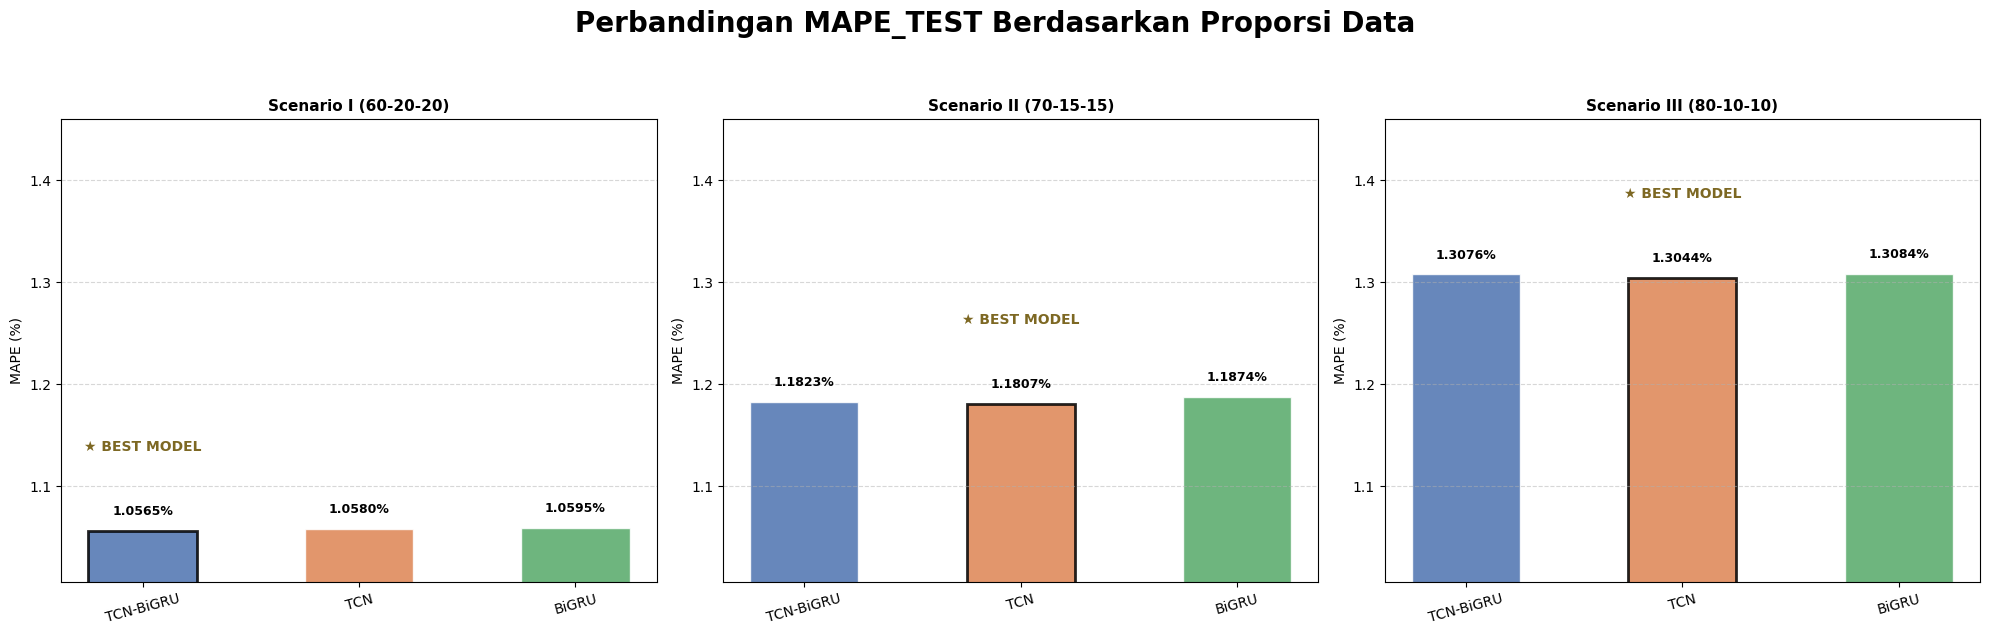

In [17]:
# =============================================================
# MAPE PER SCENARIO SPLIT
# =============================================================
split_labels  = ["0.6-0.2-0.2", "0.7-0.15-0.15", "0.8-0.1-0.1"]
split_titles  = ["Scenario I (60-20-20)", "Scenario II (70-15-15)", "Scenario III (80-10-10)"]
models        = ["TCN-BiGRU", "TCN", "BiGRU"]
colors        = ["#4C72B0", "#DD8452", "#55A868"]
width         = 0.5

# Menyiapkan data mape per split untuk looping
split_info = []
all_mape_values = [] # Untuk mencari min/max global

for label, title in zip(split_labels, split_titles):
    mape_values = []
    for pkl in [tcn_bigru, tcn, bigru]:
        match = next((r for r in pkl["all_results"] if r["split"] == label), None)
        val = match["best_mape"] if match else 0
        mape_values.append(val)
        all_mape_values.append(val)
    split_info.append((title, mape_values))

# --- HITUNG SKALA Y GLOBAL ---
global_min = min(all_mape_values)
global_max = max(all_mape_values)
global_range = global_max - global_min
y_limit_lower = global_min - (global_range * 0.2)
y_limit_upper = global_max + (global_range * 0.6) # Ruang ekstra untuk bintang gold

# Membuat Figure dengan 3 Subplot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Perbandingan MAPE_TEST Berdasarkan Proporsi Data", fontsize=20, fontweight='bold', y=1.05)

for ax, (title, values) in zip(axes, split_info):
    # Plot Bar
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=width)
    
    # Styling Subplot
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("MAPE (%)")
    
    # Atur skala Y disamakan untuk semua subplot
    ax.set_ylim(y_limit_lower, y_limit_upper)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=15)

    # Cari nilai terkecil (Best) untuk skenario ini
    min_mape = min(values)

    # Anotasi angka dan Label ★ BEST MODEL (Gold)
    for bar, val in zip(bars, values):
        # Tampilkan angka MAPE di atas setiap bar
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (global_range * 0.05),
                f"{val:.4f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Logika khusus untuk MAPE paling kecil (Best Performance)
        if val == min_mape:
            bar.set_edgecolor('black')
            bar.set_linewidth(2)
            
            # Tambahkan teks ★ BEST MODEL dengan warna Gold (#7D6823)
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (global_range * 0.3),
                    "★ BEST MODEL", 
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color='#7D6823')

plt.tight_layout()
plt.show()

/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_33164/1205732293.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algos, rotation=15, fontsize=10)
/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_33164/1205732293.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algos, rotation=15, fontsize=10)
/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_33164/1205732293.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algos, rotation=15, fontsize=10)


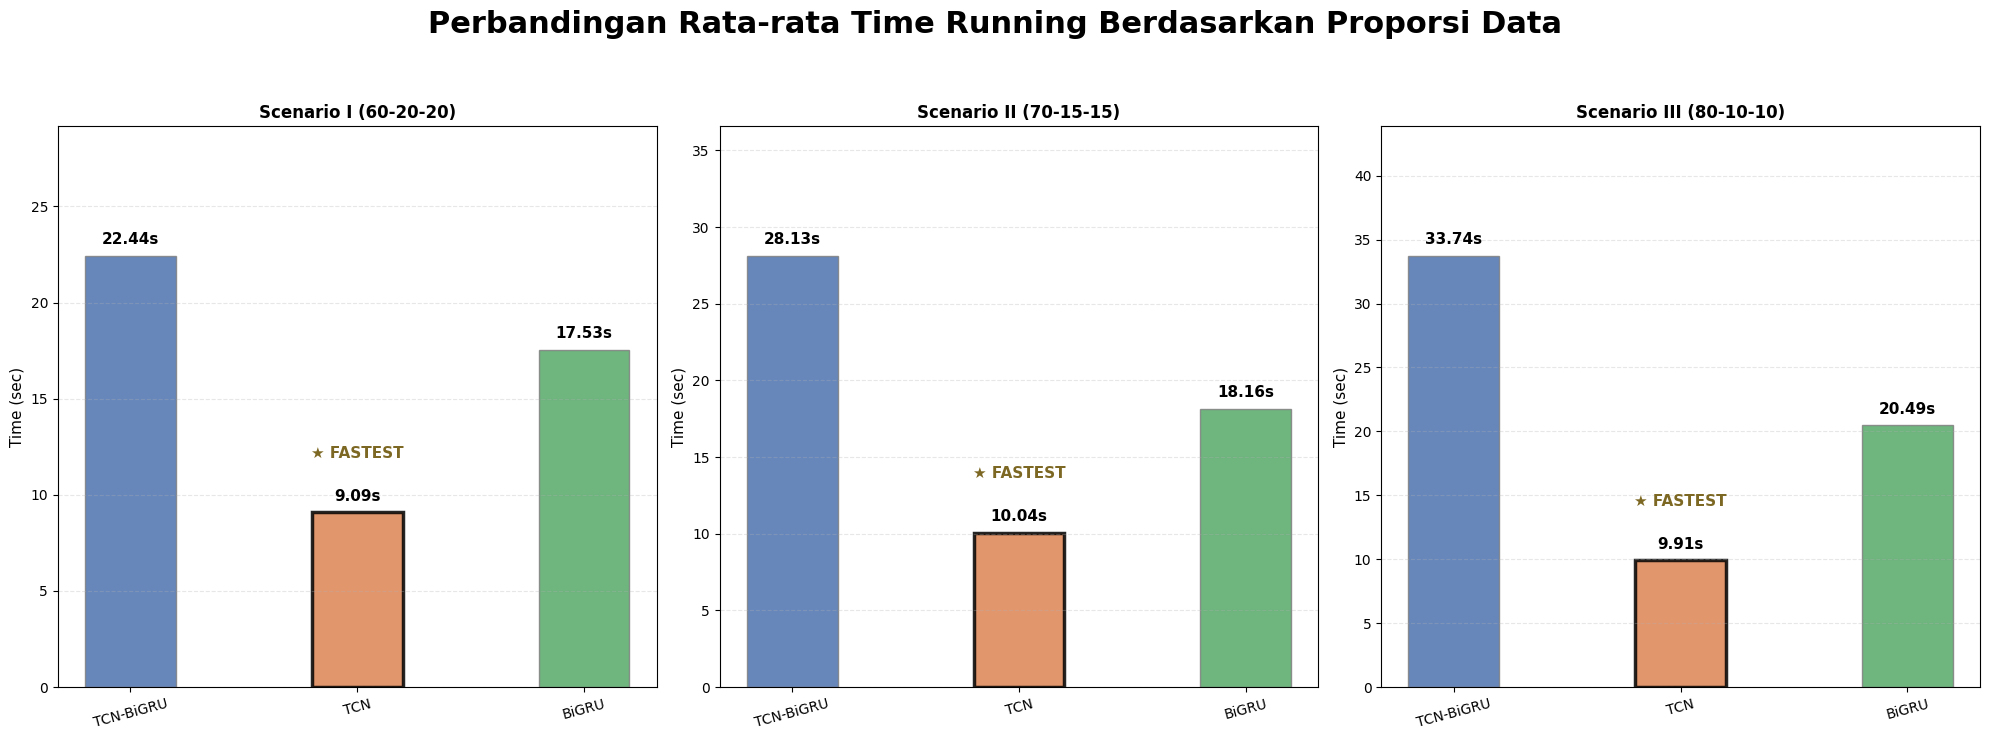

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. READ DATA LANGSUNG DARI FILE EXCEL REKAP TUNING KAMU
# =================================================================
path_tcn_bigru = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn_bigru.xlsx"
path_tcn       = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn.xlsx"
path_bigru     = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_bigru.xlsx"

df_tcn_bigru = pd.read_excel(path_tcn_bigru)
df_tcn       = pd.read_excel(path_tcn)
df_bigru     = pd.read_excel(path_bigru)

# Mapping nama split dari excel ke nama skenario untuk judul panel grafik
split_map = {
    "0.6-0.2-0.2": "Scenario I (60-20-20)",
    "0.7-0.15-0.15": "Scenario II (70-15-15)",
    "0.8-0.1-0.1": "Scenario III (80-10-10)"
}

algos = ["TCN-BiGRU", "TCN", "BiGRU"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

# =================================================================
# 2. HITUNG RATA-RATA TIME (SEC) PER SPLIT DAN PER ALGORITMA
# =================================================================
data_time_real = {}

for split_val, scenario_name in split_map.items():
    data_time_real[scenario_name] = {
        # Filter berdasarkan nilai split lalu hitung rata-rata kolom Time (sec)
        "TCN-BiGRU": df_tcn_bigru[df_tcn_bigru["Split"] == split_val]["Time (sec)"].mean(),
        "TCN":       df_tcn[df_tcn["Split"] == split_val]["Time (sec)"].mean(),
        "BiGRU":     df_bigru[df_bigru["Split"] == split_val]["Time (sec)"].mean()
    }

# =================================================================
# 3. PROSES PLOTTING 3 PANEL SCENARIO TIME RUNNING
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Perbandingan Rata-rata Time Running Berdasarkan Proporsi Data", 
             fontsize=22, fontweight='bold', y=1.05)

scenarios = list(split_map.values())

for idx, scenario_name in enumerate(scenarios):
    ax = axes[idx]
    algo_values = data_time_real[scenario_name]
    times = [algo_values[algo] for algo in algos]
    
    # Plot grafik batang dengan layout identik grafik MAPE-mu
    bars = ax.bar(algos, times, color=colors, alpha=0.85, edgecolor='grey', width=0.4)
    
    # Logika otomatis mencari model FASTEST (Waktu terkecil)
    idx_fastest = np.argmin(times)
    bars[idx_fastest].set_edgecolor('black')
    bars[idx_fastest].set_linewidth(2.5)
    
    # Beri padding batas atas Y-axis lokal agar teks melayang aman (30% ekstra ruang)
    max_time_local = max(times)
    ax.set_ylim(0, max_time_local * 1.3)
    
    # Tambahkan teks nilai rata-rata detik di atas setiap ujung bar
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (max_time_local * 0.02), 
                 f"{h:.2f}s", ha='center', va='bottom', fontsize=11, fontweight='bold')
        
    # Tambahkan penanda "★ FASTEST" di atas model pemenang durasi terkecil
    ax.text(bars[idx_fastest].get_x() + bars[idx_fastest].get_width()/2, 
            bars[idx_fastest].get_height() + (max_time_local * 0.12), 
            "★ FASTEST", ha='center', va='bottom', 
            fontsize=11, fontweight='bold', color="#7D6823")
    
    # Styling atribut visual seirama dengan rancangan proposalmu
    ax.set_title(scenario_name, fontsize=12, fontweight='bold')
    ax.set_ylabel("Time (sec)", fontsize=11)
    ax.set_xticklabels(algos, rotation=15, fontsize=10)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_33164/2824623911.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algos, rotation=15, fontsize=10)
/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_33164/2824623911.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algos, rotation=15, fontsize=10)
/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_33164/2824623911.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algos, rotation=15, fontsize=10)


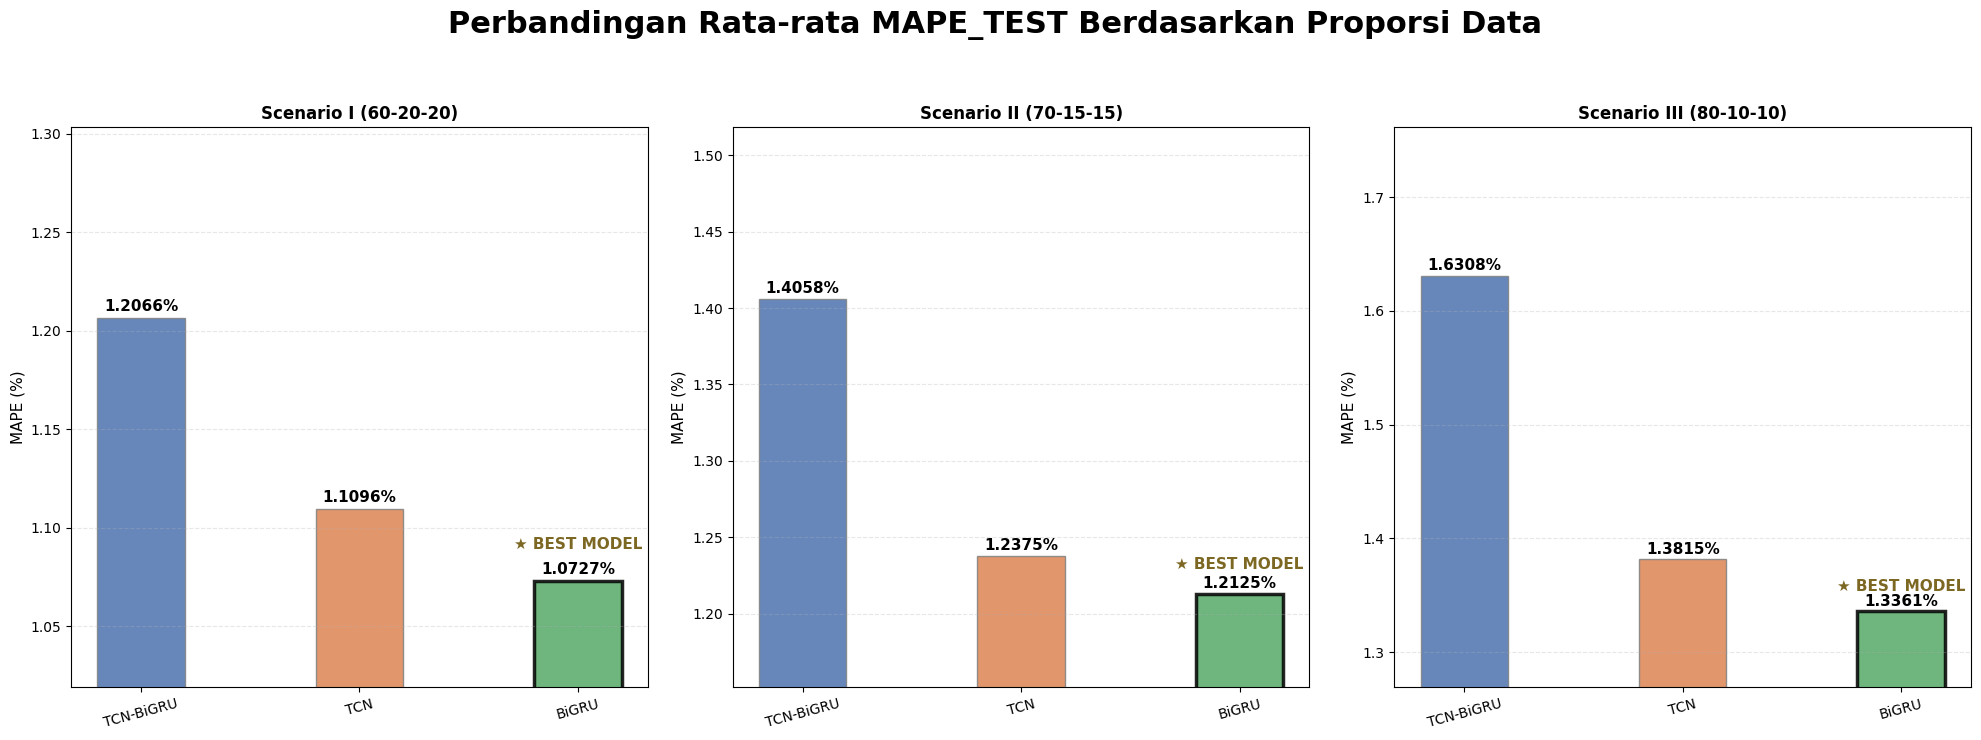

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. READ DATA LANGSUNG DARI FILE EXCEL REKAP TUNING KAMU
# =================================================================
path_tcn_bigru = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn_bigru.xlsx"
path_tcn       = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn.xlsx"
path_bigru     = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_bigru.xlsx"

df_tcn_bigru = pd.read_excel(path_tcn_bigru)
df_tcn       = pd.read_excel(path_tcn)
df_bigru     = pd.read_excel(path_bigru)

# Mapping nama split dari excel ke nama skenario untuk judul panel grafik
split_map = {
    "0.6-0.2-0.2": "Scenario I (60-20-20)",
    "0.7-0.15-0.15": "Scenario II (70-15-15)",
    "0.8-0.1-0.1": "Scenario III (80-10-10)"
}

algos = ["TCN-BiGRU", "TCN", "BiGRU"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

# =================================================================
# 2. HITUNG RATA-RATA MAPE (%) PER SPLIT DAN PER ALGORITMA
# =================================================================
data_mape_real = {}

for split_val, scenario_name in split_map.items():
    data_mape_real[scenario_name] = {
        # Filter berdasarkan nilai split lalu hitung rata-rata kolom MAPE (%)
        "TCN-BiGRU": df_tcn_bigru[df_tcn_bigru["Split"] == split_val]["MAPE (%)"].mean(),
        "TCN":       df_tcn[df_tcn["Split"] == split_val]["MAPE (%)"].mean(),
        "BiGRU":     df_bigru[df_bigru["Split"] == split_val]["MAPE (%)"].mean()
    }

# =================================================================
# 3. PROSES PLOTTING 3 PANEL SCENARIO MAPE (%)
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Perbandingan Rata-rata MAPE_TEST Berdasarkan Proporsi Data", 
             fontsize=22, fontweight='bold', y=1.05)

scenarios = list(split_map.values())

for idx, scenario_name in enumerate(scenarios):
    ax = axes[idx]
    algo_values = data_mape_real[scenario_name]
    mapes = [algo_values[algo] for algo in algos]
    
    # Plot grafik batang
    bars = ax.bar(algos, mapes, color=colors, alpha=0.85, edgecolor='grey', width=0.4)
    
    # Logika otomatis mencari model dengan MAPE TERENDAH (Nilai Minimum)
    idx_best = np.argmin(mapes)
    bars[idx_best].set_edgecolor('black')
    bars[idx_best].set_linewidth(2.5)
    
    # Mengatur limit sumbu Y secara lokal (dinamis) agar memberikan ruang teks di atas bar
    mape_min, mape_max = min(mapes), max(mapes)
    ax.set_ylim(mape_min * 0.95, mape_max * 1.08)
    
    # Tambahkan teks nilai rata-rata persentase MAPE di atas setiap bar
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002, 
                 f"{h:.4f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
        
    # Tambahkan penanda "★ BEST MODEL" melayang di atas bar dengan MAPE terkecil
    ax.text(bars[idx_best].get_x() + bars[idx_best].get_width()/2, 
            bars[idx_best].get_height() + 0.015, 
            "★ BEST MODEL", ha='center', va='bottom', 
            fontsize=11, fontweight='bold', color="#7D6823")
    
    # Kosmetik styling layout agar identik dengan desain grafismu
    ax.set_title(scenario_name, fontsize=12, fontweight='bold')
    ax.set_ylabel("MAPE (%)", fontsize=11)
    ax.set_xticklabels(algos, rotation=15, fontsize=10)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_33164/2951696614.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algos, rotation=15, fontsize=10)
/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_33164/2951696614.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algos, rotation=15, fontsize=10)
/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_33164/2951696614.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algos, rotation=15, fontsize=10)


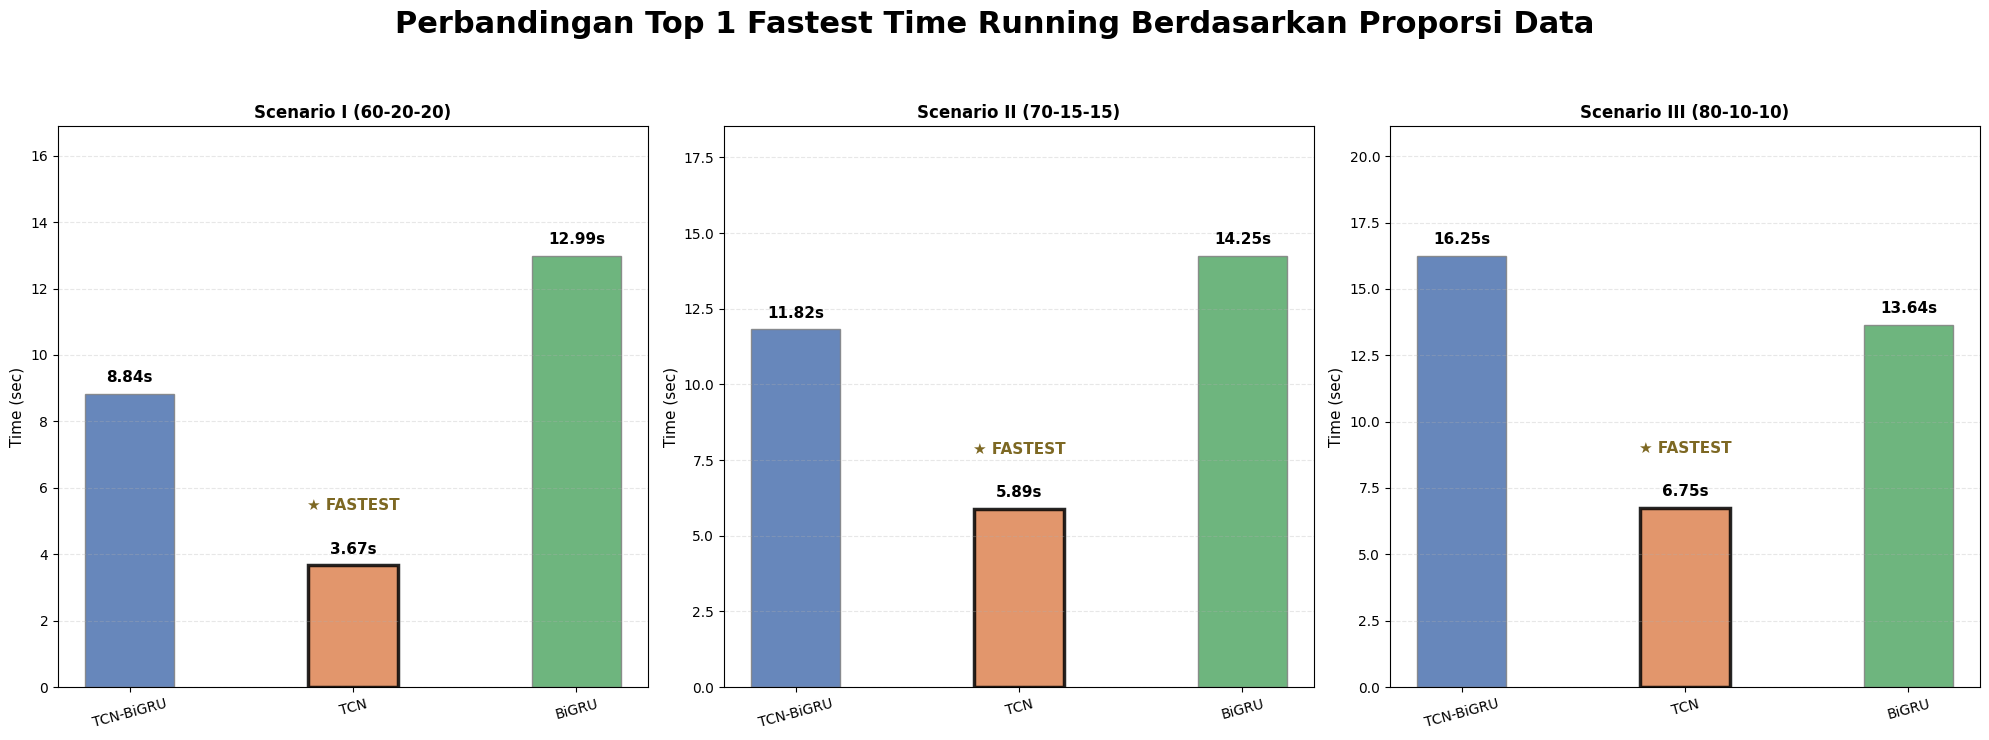

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. READ DATA LANGSUNG DARI FILE EXCEL REKAP TUNING KAMU
# =================================================================
path_tcn_bigru = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn_bigru.xlsx"
path_tcn       = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn.xlsx"
path_bigru     = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_bigru.xlsx"

df_tcn_bigru = pd.read_excel(path_tcn_bigru)
df_tcn       = pd.read_excel(path_tcn)
df_bigru     = pd.read_excel(path_bigru)

# Mapping nama split dari excel ke nama skenario untuk judul panel grafik
split_map = {
    "0.6-0.2-0.2": "Scenario I (60-20-20)",
    "0.7-0.15-0.15": "Scenario II (70-15-15)",
    "0.8-0.1-0.1": "Scenario III (80-10-10)"
}

algos = ["TCN-BiGRU", "TCN", "BiGRU"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

# =================================================================
# 2. EKSTRAK NILAI TOP 1 FASTEST (MINIMUM RUNNING TIME) PER SPLIT
# =================================================================
data_time_top1 = {}

for split_val, scenario_name in split_map.items():
    data_time_top1[scenario_name] = {
        # Mengambil nilai minimum (.min()) dari kolom Time (sec) untuk performa tercepat
        "TCN-BiGRU": df_tcn_bigru[df_tcn_bigru["Split"] == split_val]["Time (sec)"].min(),
        "TCN":       df_tcn[df_tcn["Split"] == split_val]["Time (sec)"].min(),
        "BiGRU":     df_bigru[df_bigru["Split"] == split_val]["Time (sec)"].min()
    }

# =================================================================
# 3. PROSES PLOTTING 3 PANEL SCENARIO (FASTEST TIME RUNNING)
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Perbandingan Top 1 Fastest Time Running Berdasarkan Proporsi Data", 
             fontsize=22, fontweight='bold', y=1.05)

scenarios = list(split_map.values())

for idx, scenario_name in enumerate(scenarios):
    ax = axes[idx]
    algo_values = data_time_top1[scenario_name]
    times = [algo_values[algo] for algo in algos]
    
    # Plot grafik batang dengan layout identik grafik MAPE-mu sebelumnya
    bars = ax.bar(algos, times, color=colors, alpha=0.85, edgecolor='grey', width=0.4)
    
    # Logika mencari model tercepat global di panel skenario ini untuk di-highlight bingkai hitam
    idx_fastest = np.argmin(times)
    bars[idx_fastest].set_edgecolor('black')
    bars[idx_fastest].set_linewidth(2.5)
    
    # Beri padding batas atas Y-axis lokal agar teks melayang aman (30% ekstra ruang kosong)
    max_time_local = max(times)
    ax.set_ylim(0, max_time_local * 1.3)
    
    # Tambahkan teks nilai waktu tercepat (detik) tepat di atas masing-masing bar
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (max_time_local * 0.02), 
                 f"{h:.2f}s", ha='center', va='bottom', fontsize=11, fontweight='bold')
        
    # Tambahkan penanda "★ FASTEST" melayang tinggi tepat di atas model dengan durasi tersingkat
    ax.text(bars[idx_fastest].get_x() + bars[idx_fastest].get_width()/2, 
            bars[idx_fastest].get_height() + (max_time_local * 0.12), 
            "★ FASTEST", ha='center', va='bottom', 
            fontsize=11, fontweight='bold', color="#7D6823")
    
    # Atur kosmetik visual agar seirama dengan susunan bab TA kamu
    ax.set_title(scenario_name, fontsize=12, fontweight='bold')
    ax.set_ylabel("Time (sec)", fontsize=11)
    ax.set_xticklabels(algos, rotation=15, fontsize=10)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

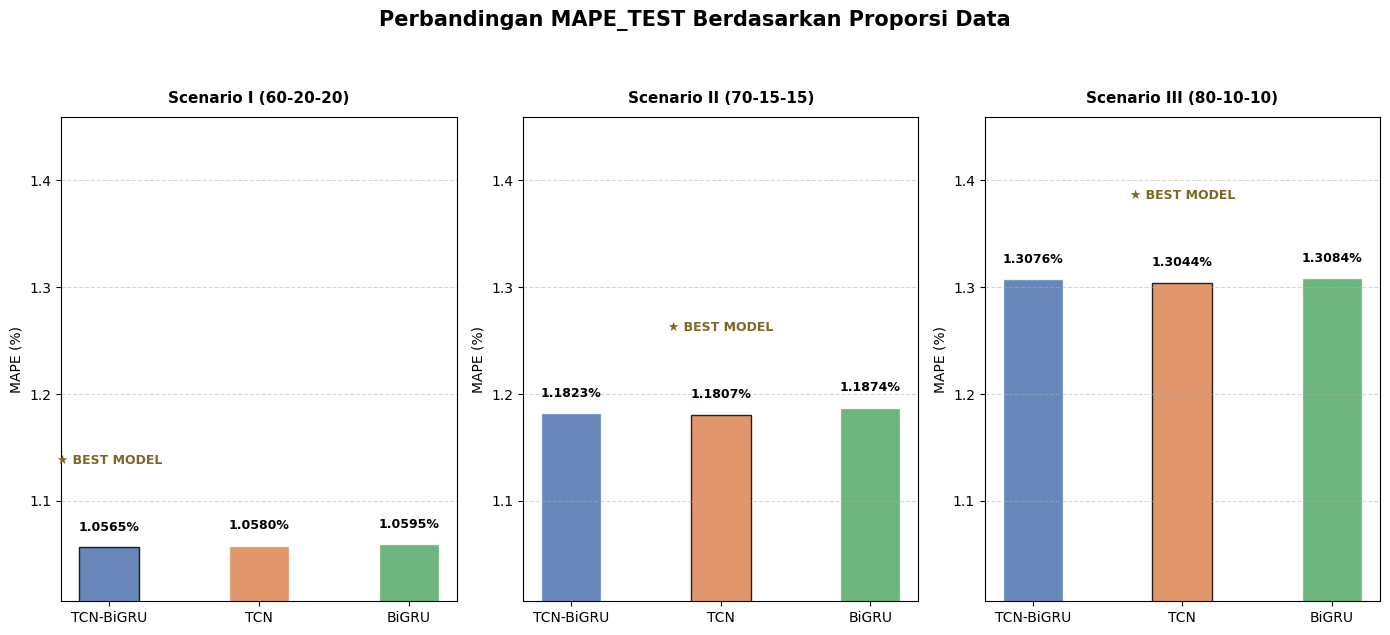

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# MAPE PER SCENARIO SPLIT (RAMPING VERSION)
# =============================================================
split_labels  = ["0.6-0.2-0.2", "0.7-0.15-0.15", "0.8-0.1-0.1"]
split_titles  = ["Scenario I (60-20-20)", "Scenario II (70-15-15)", "Scenario III (80-10-10)"]
models        = ["TCN-BiGRU", "TCN", "BiGRU"]
colors        = ["#4C72B0", "#DD8452", "#55A868"]
width         = 0.4  # REVISI: Diubah dari 0.5 ke 0.4 agar batang lebih slim

# Menyiapkan data mape per split untuk looping
split_info = []
all_mape_values = [] # Untuk mencari min/max global

for label, title in zip(split_labels, split_titles):
    mape_values = []
    for pkl in [tcn_bigru, tcn, bigru]:
        match = next((r for r in pkl["all_results"] if r["split"] == label), None)
        val = match["best_mape"] if match else 0
        mape_values.append(val)
        all_mape_values.append(val)
    split_info.append((title, mape_values))

# --- HITUNG SKALA Y GLOBAL ---
global_min = min(all_mape_values)
global_max = max(all_mape_values)
global_range = global_max - global_min
y_limit_lower = global_min - (global_range * 0.2)
y_limit_upper = global_max + (global_range * 0.6) # Ruang ekstra untuk bintang gold

# REVISI: Ukuran lebar total diturunkan dari 20 menjadi 14 agar setiap kotak otomatis meramping
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle("Perbandingan MAPE_TEST Berdasarkan Proporsi Data", fontsize=15, fontweight='bold', y=1.05)

for ax, (title, values) in zip(axes, split_info):
    # Plot Bar
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=width)
    
    # Styling Subplot
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel("MAPE (%)")
    
    # Atur skala Y disamakan untuk semua subplot
    ax.set_ylim(y_limit_lower, y_limit_upper)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=0) # REVISI: Diubah ke 0 agar teks model lurus dan rapi karena ruang sudah ramping

    # Cari nilai terkecil (Best) untuk skenario ini
    min_mape = min(values)

    # Anotasi angka dan Label ★ BEST MODEL (Gold)
    for bar, val in zip(bars, values):
        # Tampilkan angka MAPE di atas setiap bar
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (global_range * 0.05),
                f"{val:.4f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Logika khusus untuk MAPE paling kecil (Best Performance)
        if val == min_mape:
            bar.set_edgecolor('black')
            bar.set_linewidth(1)
            
            # Tambahkan teks ★ BEST MODEL dengan warna Gold (#7D6823)
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (global_range * 0.3),
                    "★ BEST MODEL", 
                    ha='center', va='bottom', 
                    fontsize=9, fontweight='bold', color='#7D6823')

plt.tight_layout()
plt.show()

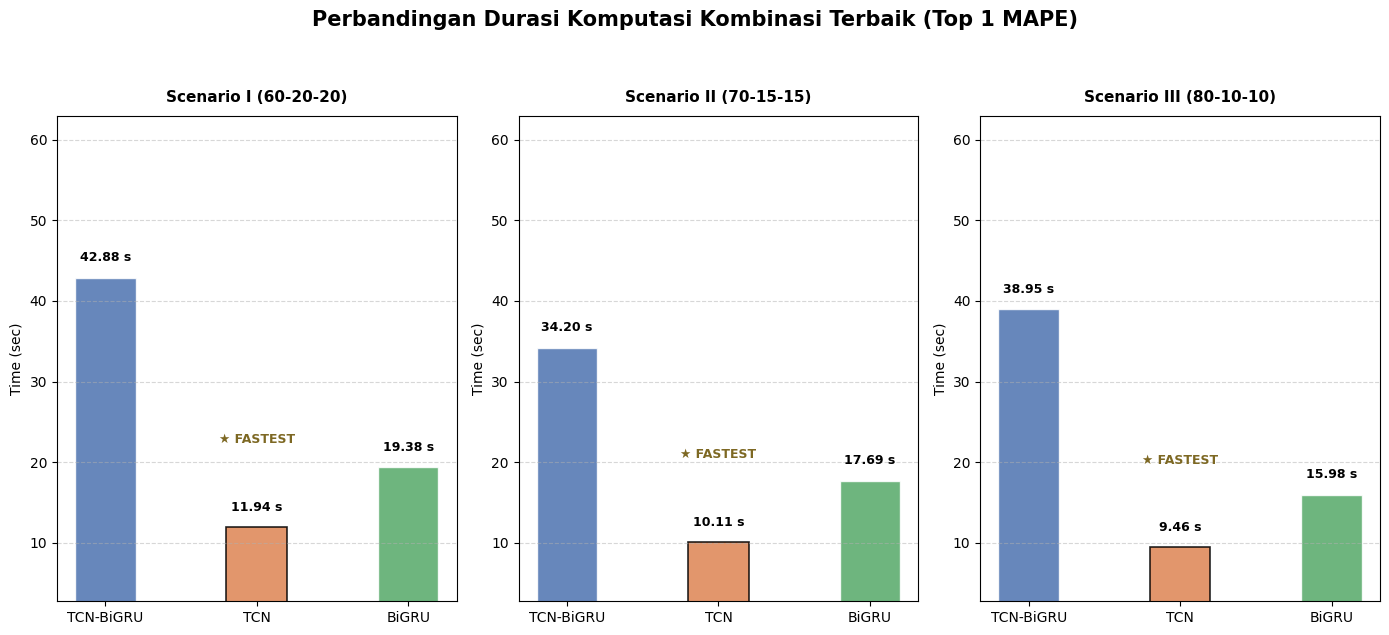

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# 1. LOAD DATA EXCEL
# =============================================================
path_tcn_bigru = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn_bigru.xlsx"
path_tcn       = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn.xlsx"
path_bigru     = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_bigru.xlsx"

df_tcn_bigru = pd.read_excel(path_tcn_bigru)
df_tcn       = pd.read_excel(path_tcn)
df_bigru     = pd.read_excel(path_bigru)

# =============================================================
# 2. EKSTRAKSI TIME RUNNING DARI TOP 1 MAPE PER SPLIT
# =============================================================
split_labels  = ["0.6-0.2-0.2", "0.7-0.15-0.15", "0.8-0.1-0.1"]
split_titles  = ["Scenario I (60-20-20)", "Scenario II (70-15-15)", "Scenario III (80-10-10)"]
models        = ["TCN-BiGRU", "TCN", "BiGRU"]
colors        = ["#4C72B0", "#DD8452", "#55A868"]
width         = 0.4  # Batang slim

split_info_time = []
all_time_values = []

for label, title in zip(split_labels, split_titles):
    time_values = []
    for df in [df_tcn_bigru, df_tcn, df_bigru]:
        # Filter berdasarkan split saat ini
        df_split = df[df["Split"] == label]
        
        if not df_split.empty:
            # Cari baris dengan MAPE (%) terkecil (Top 1 Best MAPE)
            idx_best_mape = df_split["MAPE (%)"].idxmin()
            # Ambil nilai kolom 'Time (sec)' dari baris tersebut
            val_time = df_split.loc[idx_best_mape, "Time (sec)"]
        else:
            val_time = 0
            
        time_values.append(val_time)
        all_time_values.append(val_time)
        
    split_info_time.append((title, time_values))

# --- HITUNG SKALA Y GLOBAL UNTUK WAKTU ---
global_min_t = min(all_time_values)
global_max_t = max(all_time_values)
global_range_t = global_max_t - global_min_t
if global_range_t == 0: global_range_t = 1 

y_limit_lower_t = max(0, global_min_t - (global_range_t * 0.2)) 
y_limit_upper_t = global_max_t + (global_range_t * 0.6) 

# =============================================================
# 3. VISUALISASI (STRUKTUR SAMA PERSIS DENGAN SEBELUMNYA)
# =============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle("Perbandingan Durasi Komputasi Kombinasi Terbaik (Top 1 MAPE)", fontsize=15, fontweight='bold', y=1.05)

for ax, (title, values) in zip(axes, split_info_time):
    # Plot Bar
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=width)
    
    # Styling Subplot
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel("Time (sec)")
    ax.set_ylim(y_limit_lower_t, y_limit_upper_t)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=0) 

    # Cari nilai waktu tercepat (paling efisien) di skenario ini
    min_time = min(values)

    # Anotasi angka dan Label ★ FASTEST (Gold)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (global_range_t * 0.05),
                f"{val:.2f} s", ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Beri penanda jika dia yang paling cepat waktu runningnya
        if val == min_time:
            bar.set_edgecolor('black')
            bar.set_linewidth(1.2)
            
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (global_range_t * 0.3),
                    "★ FASTEST", 
                    ha='center', va='bottom', 
                    fontsize=9, fontweight='bold', color='#7D6823')

plt.tight_layout()
plt.show()

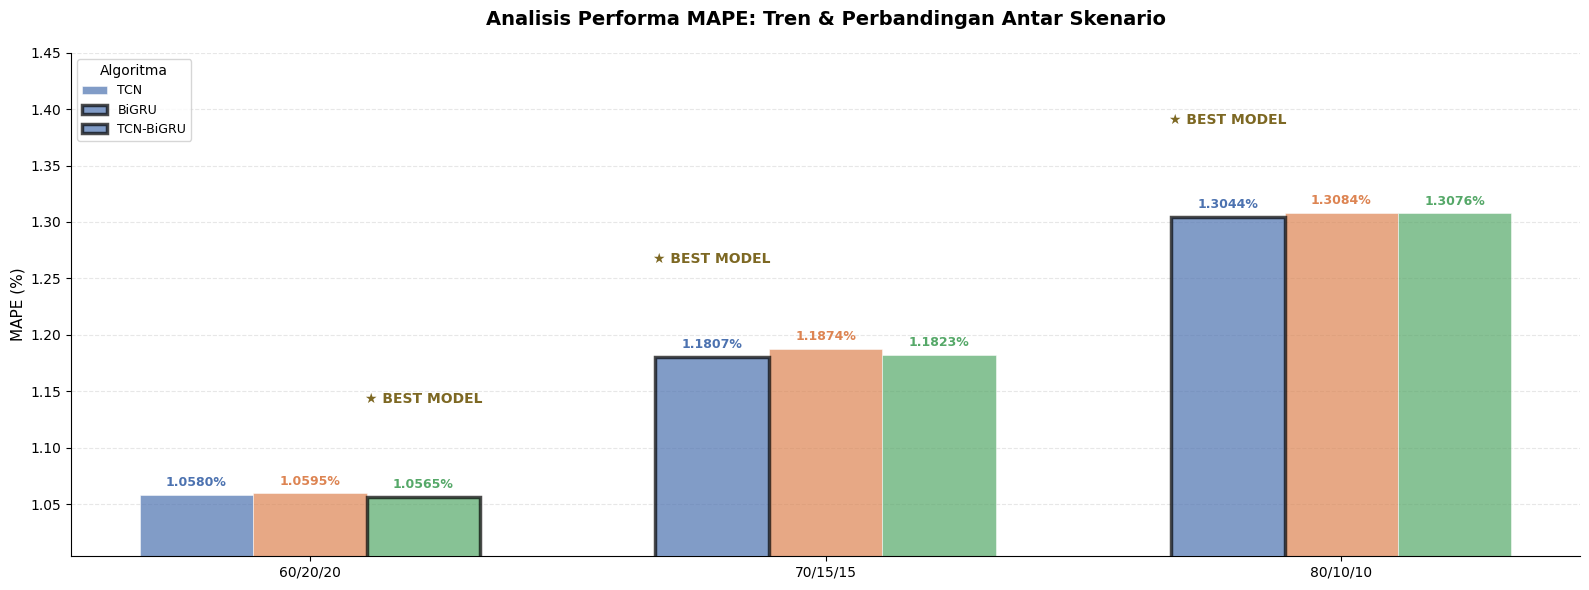

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Membersihkan sisa plot agar kanvas tidak menumpuk
plt.close('all')

# 1. Perkecil tinggi figsize agar tidak 'melar' ke bawah
fig, ax = plt.subplots(figsize=(16, 6))

# Ekstraksi data
all_data = []
for pkl in algo_pkls:
    mape_algo = []
    for split in split_labels:
        match = next((r for r in pkl["all_results"] if r["split"] == split), None)
        mape_algo.append(match["best_mape"] if match else 0)
    all_data.append(mape_algo)

x = np.arange(len(split_display))
width = 0.22 

# --- MODIFIKASI: Gambar Bar & Line Tren ---
for i, (name, color) in enumerate(zip(algo_names, colors)):
    pos = x + (i * width) - width
    
    # Render Bar satu per satu untuk kontrol highlight model terbaik per skenario
    for j, (p, val) in enumerate(zip(pos, all_data[i])):
        # Cek apakah ini model terbaik di skenario split ke-j
        current_split_mapes = [all_data[a_idx][j] for a_idx in range(len(algo_names))]
        is_best = (val == min(current_split_mapes))
        
        # Highlight best model dengan garis pinggir hitam tebal
        edge_c = 'black' if is_best else 'white'
        line_w = 2.5 if is_best else 0.5
        z_ord = 3 if is_best else 2
        
        bar_obj = ax.bar(p, val, width, color=color, alpha=0.7, 
                         edgecolor=edge_c, linewidth=line_w, zorder=z_ord)
        
        # Tambahkan teks MAPE di atas bar
        ax.text(p, val + 0.005, f'{val:.4f}%', ha='center', va='bottom', 
                fontsize=9, fontweight='bold', color=color)

    # # Gambar Line Tren di belakang bar agar tetap terlihat jalurnya
    # ax.plot(pos, all_data[i], color=color, marker='o', linewidth=2, 
    #         markersize=5, alpha=0.8, zorder=4, label=name if i==i else "")

# 2. Tambahkan Label ★ BEST MODEL (Gold)
for s_idx in range(len(split_display)):
    current_mapes = [all_data[a_idx][s_idx] for a_idx in range(len(algo_names))]
    min_val, max_val = min(current_mapes), max(current_mapes)
    best_algo_idx = current_mapes.index(min_val)
    best_x_pos = x[s_idx] + (best_algo_idx * width) - width
    
    # Offset y yang proporsional agar label tidak menabrak angka
    y_offset = 0.08 
    
    ax.text(best_x_pos, min_val + y_offset, 
            "★ BEST MODEL", ha='center', va='bottom', 
            fontsize=10, fontweight='black', color='#7D6823',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

# Kosmetik Plot
ax.set_title("Analisis Performa MAPE: Tren & Perbandingan Antar Skenario", fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel("MAPE (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(split_display)
ax.legend(algo_names, title="Algoritma", loc='upper left', fontsize=9)

# Grid & Spines
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Kunci agar tidak kepanjangan
y_all = [val for sublist in all_data for val in sublist]
ax.set_ylim(min(y_all) * 0.95, 1.45) 

plt.tight_layout()
plt.show()

In [ ]:
# ===============================
# LOAD TUNING DATA DARI PICKLE
# ===============================
df_tuning_tcn_bigru = pd.DataFrame(tcn_bigru["tuning_table_data"])
df_tuning_tcn       = pd.DataFrame(tcn["tuning_table_data"])
df_tuning_bigru     = pd.DataFrame(bigru["tuning_table_data"])

# Tambahkan kolom nama algo
df_tuning_tcn_bigru["Algo"] = "TCN-BiGRU"
df_tuning_tcn["Algo"]       = "TCN"
df_tuning_bigru["Algo"]     = "BiGRU"

# Gabungkan semua
df_all_tuning = pd.concat([df_tuning_tcn_bigru, df_tuning_tcn, df_tuning_bigru], ignore_index=True)

print("Kolom tersedia:", df_all_tuning.columns.tolist())
display(df_all_tuning.head(15))

Kolom tersedia: ['Kombinasi Ke-', 'Split', 'Filter', 'Kernel', 'GRU Units', 'Batch Size', 'LR', 'Best Epoch', 'MAPE (%)', 'Time (sec)', 'Algo']


,Kombinasi Ke-,Split,Filter,Kernel,GRU Units,Batch Size,LR,Best Epoch,MAPE (%),Time (sec),Algo
0,1,0.6-0.2-0.2,32.0,2.0,32.0,8,0.0010,12,1.0829,20.00,TCN-BiGRU
1,2,0.6-0.2-0.2,32.0,2.0,32.0,8,0.0015,23,1.0593,28.52,TCN-BiGRU
2,3,0.6-0.2-0.2,32.0,2.0,32.0,16,0.0010,10,1.1540,11.90,TCN-BiGRU
3,4,0.6-0.2-0.2,32.0,2.0,32.0,16,0.0015,11,1.1144,12.42,TCN-BiGRU
4,5,0.6-0.2-0.2,32.0,2.0,32.0,8,0.0010,15,1.0849,22.00,TCN-BiGRU
5,6,0.6-0.2-0.2,32.0,2.0,32.0,8,0.0015,10,1.0745,18.78,TCN-BiGRU
6,7,0.6-0.2-0.2,32.0,2.0,32.0,16,0.0010,12,1.1774,13.07,TCN-BiGRU
7,8,0.6-0.2-0.2,32.0,2.0,32.0,16,0.0015,2,1.4375,8.84,TCN-BiGRU
8,9,0.6-0.2-0.2,32.0,2.0,64.0,8,0.0010,15,1.0806,24.94,TCN-BiGRU
9,10,0.6-0.2-0.2,32.0,2.0,64.0,8,0.0015,17,1.0888,26.98,TCN-BiGRU


In [ ]:
df_tuning_tcn_bigru = pd.DataFrame(tcn_bigru["tuning_table_data"])
df_tuning_tcn       = pd.DataFrame(tcn["tuning_table_data"])
df_tuning_bigru     = pd.DataFrame(bigru["tuning_table_data"])

df_tuning_tcn_bigru["Algo"] = "TCN-BiGRU"
df_tuning_tcn["Algo"]       = "TCN"
df_tuning_bigru["Algo"]     = "BiGRU"

# Suntikkan nilai dropout terbaik ke dalam tabel tuning masing-masing
df_tuning_tcn_bigru["Dropout"] = params_tcn_bigru[4] # indeks ke-4 sesuai kode df_params-mu
df_tuning_tcn["Dropout"]       = params_tcn[3]       # indeks ke-3 sesuai kode df_params-mu
df_tuning_bigru["Dropout"]     = params_bigru[1]     # indeks ke-1 sesuai kode df_params-mu

param_cols_map = {
    "TCN-BiGRU": [c for c in df_tuning_tcn_bigru.columns if c in ["Filter", "Kernel", "GRU Units", "Dropout", "Batch Size", "LR"]],
    "TCN":       [c for c in df_tuning_tcn.columns       if c in ["Filter", "Kernel", "Dropout", "Batch Size", "LR"]],
    "BiGRU":     [c for c in df_tuning_bigru.columns     if c in ["GRU Units", "Dropout", "Batch Size", "LR"]],
}
tuning_map = {
    "TCN-BiGRU": df_tuning_tcn_bigru,
    "TCN":       df_tuning_tcn,
    "BiGRU":     df_tuning_bigru,
}
color_map = {
    "TCN-BiGRU": "#4C72B0",
    "TCN":       "#DD8452",
    "BiGRU":     "#55A868",
}
n_cols = max(len(v) for v in param_cols_map.values())
n_rows = len(param_cols_map)

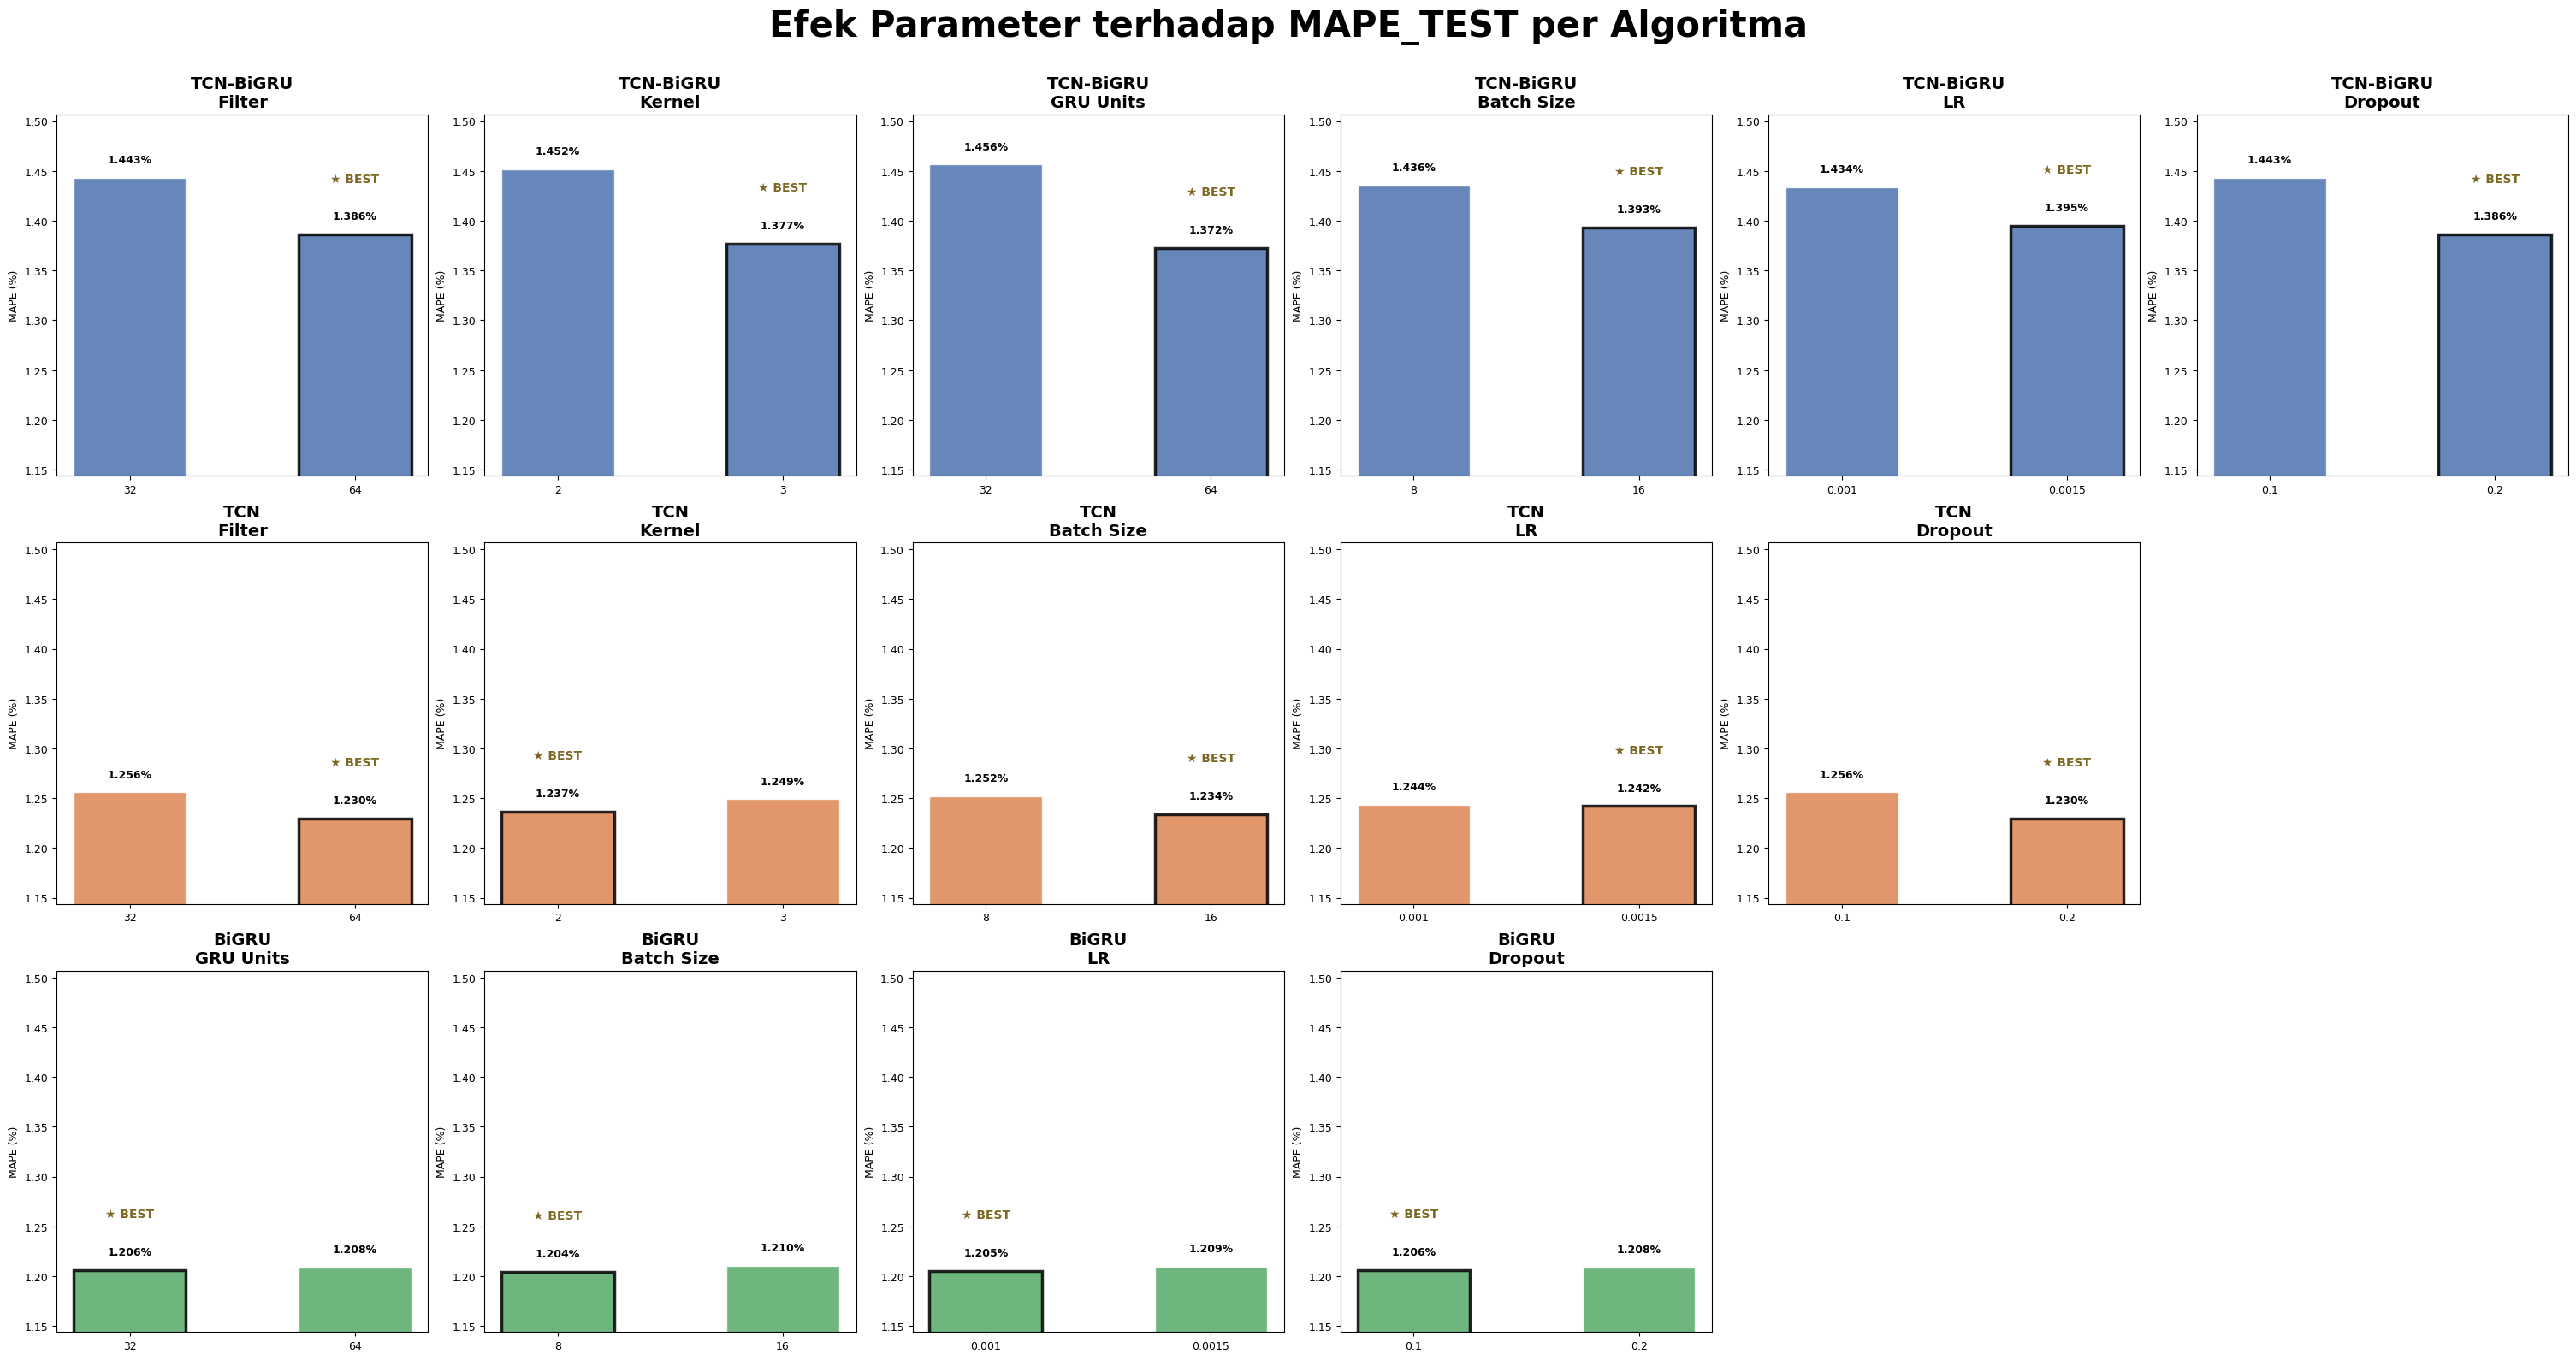

In [ ]:
# ===============================
# 1. CARI RENTANG MAPE GLOBAL
# ===============================
all_mape_values = []
for algo_name, df_a in tuning_map.items():
    param_cols = param_cols_map[algo_name]
    for p in param_cols:
        all_mape_values.extend(df_a.groupby(p)["MAPE (%)"].mean().tolist())

# Kita ambil min dan max global untuk skala Y yang konsisten
global_mape_min = min(all_mape_values)
global_mape_max = max(all_mape_values)

# Tambahkan padding 40% di atas agar teks "★ BEST" tidak terpotong
y_limit_lower = global_mape_min * 0.95 
y_limit_upper = global_mape_max + (global_mape_max - global_mape_min) * 0.2

# ===============================
# 2. GRAFIK MAPE DENGAN SKALA SERAGAM
# ===============================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 15), layout='constrained')
fig.suptitle("Efek Parameter terhadap MAPE_TEST per Algoritma", 
             fontsize=30, fontweight='bold', y=1.05)

for row_idx, (algo_name, param_cols) in enumerate(param_cols_map.items()):
    df_a  = tuning_map[algo_name]
    color = color_map[algo_name]

    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]

        if col_idx < len(param_cols):
            param   = param_cols[col_idx]
            grouped = df_a.groupby(param)["MAPE (%)"].mean().reset_index()

            bars = ax.bar(grouped[param].astype(str), grouped["MAPE (%)"],
                          color=color, alpha=0.85, edgecolor='white', width=0.5)

            # --- SET SKALA Y SERAGAM ---
            ax.set_ylim(y_limit_lower, y_limit_upper)
            
            # Rentang lokal untuk padding teks (opsional, bisa pakai global_range)
            global_range = global_mape_max - global_mape_min

            for bar, val in zip(bars, grouped["MAPE (%)"]):
                ax.text(bar.get_x() + bar.get_width()/2, 
                        val + (global_range * 0.05), 
                        f"{val:.3f}%", ha='center', va='bottom', 
                        fontsize=9, fontweight='bold')
                
            # --- LOGIKA BINTANG BEST MODEL ---
            best_idx = grouped["MAPE (%)"].idxmin()
            bars[best_idx].set_edgecolor('black')
            bars[best_idx].set_linewidth(2.5)
            
            ax.text(bars[best_idx].get_x() + bars[best_idx].get_width()/2, 
                    bars[best_idx].get_height() + (global_range * 0.2), 
                    "★ BEST", ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color="#7D6823")

            ax.set_title(f"{algo_name}\n{param}", fontsize=14, fontweight='bold')
            ax.set_ylabel("MAPE (%)", fontsize=9)
            ax.tick_params(axis='both', labelsize=9)

        else:
            ax.axis('off')

plt.show()

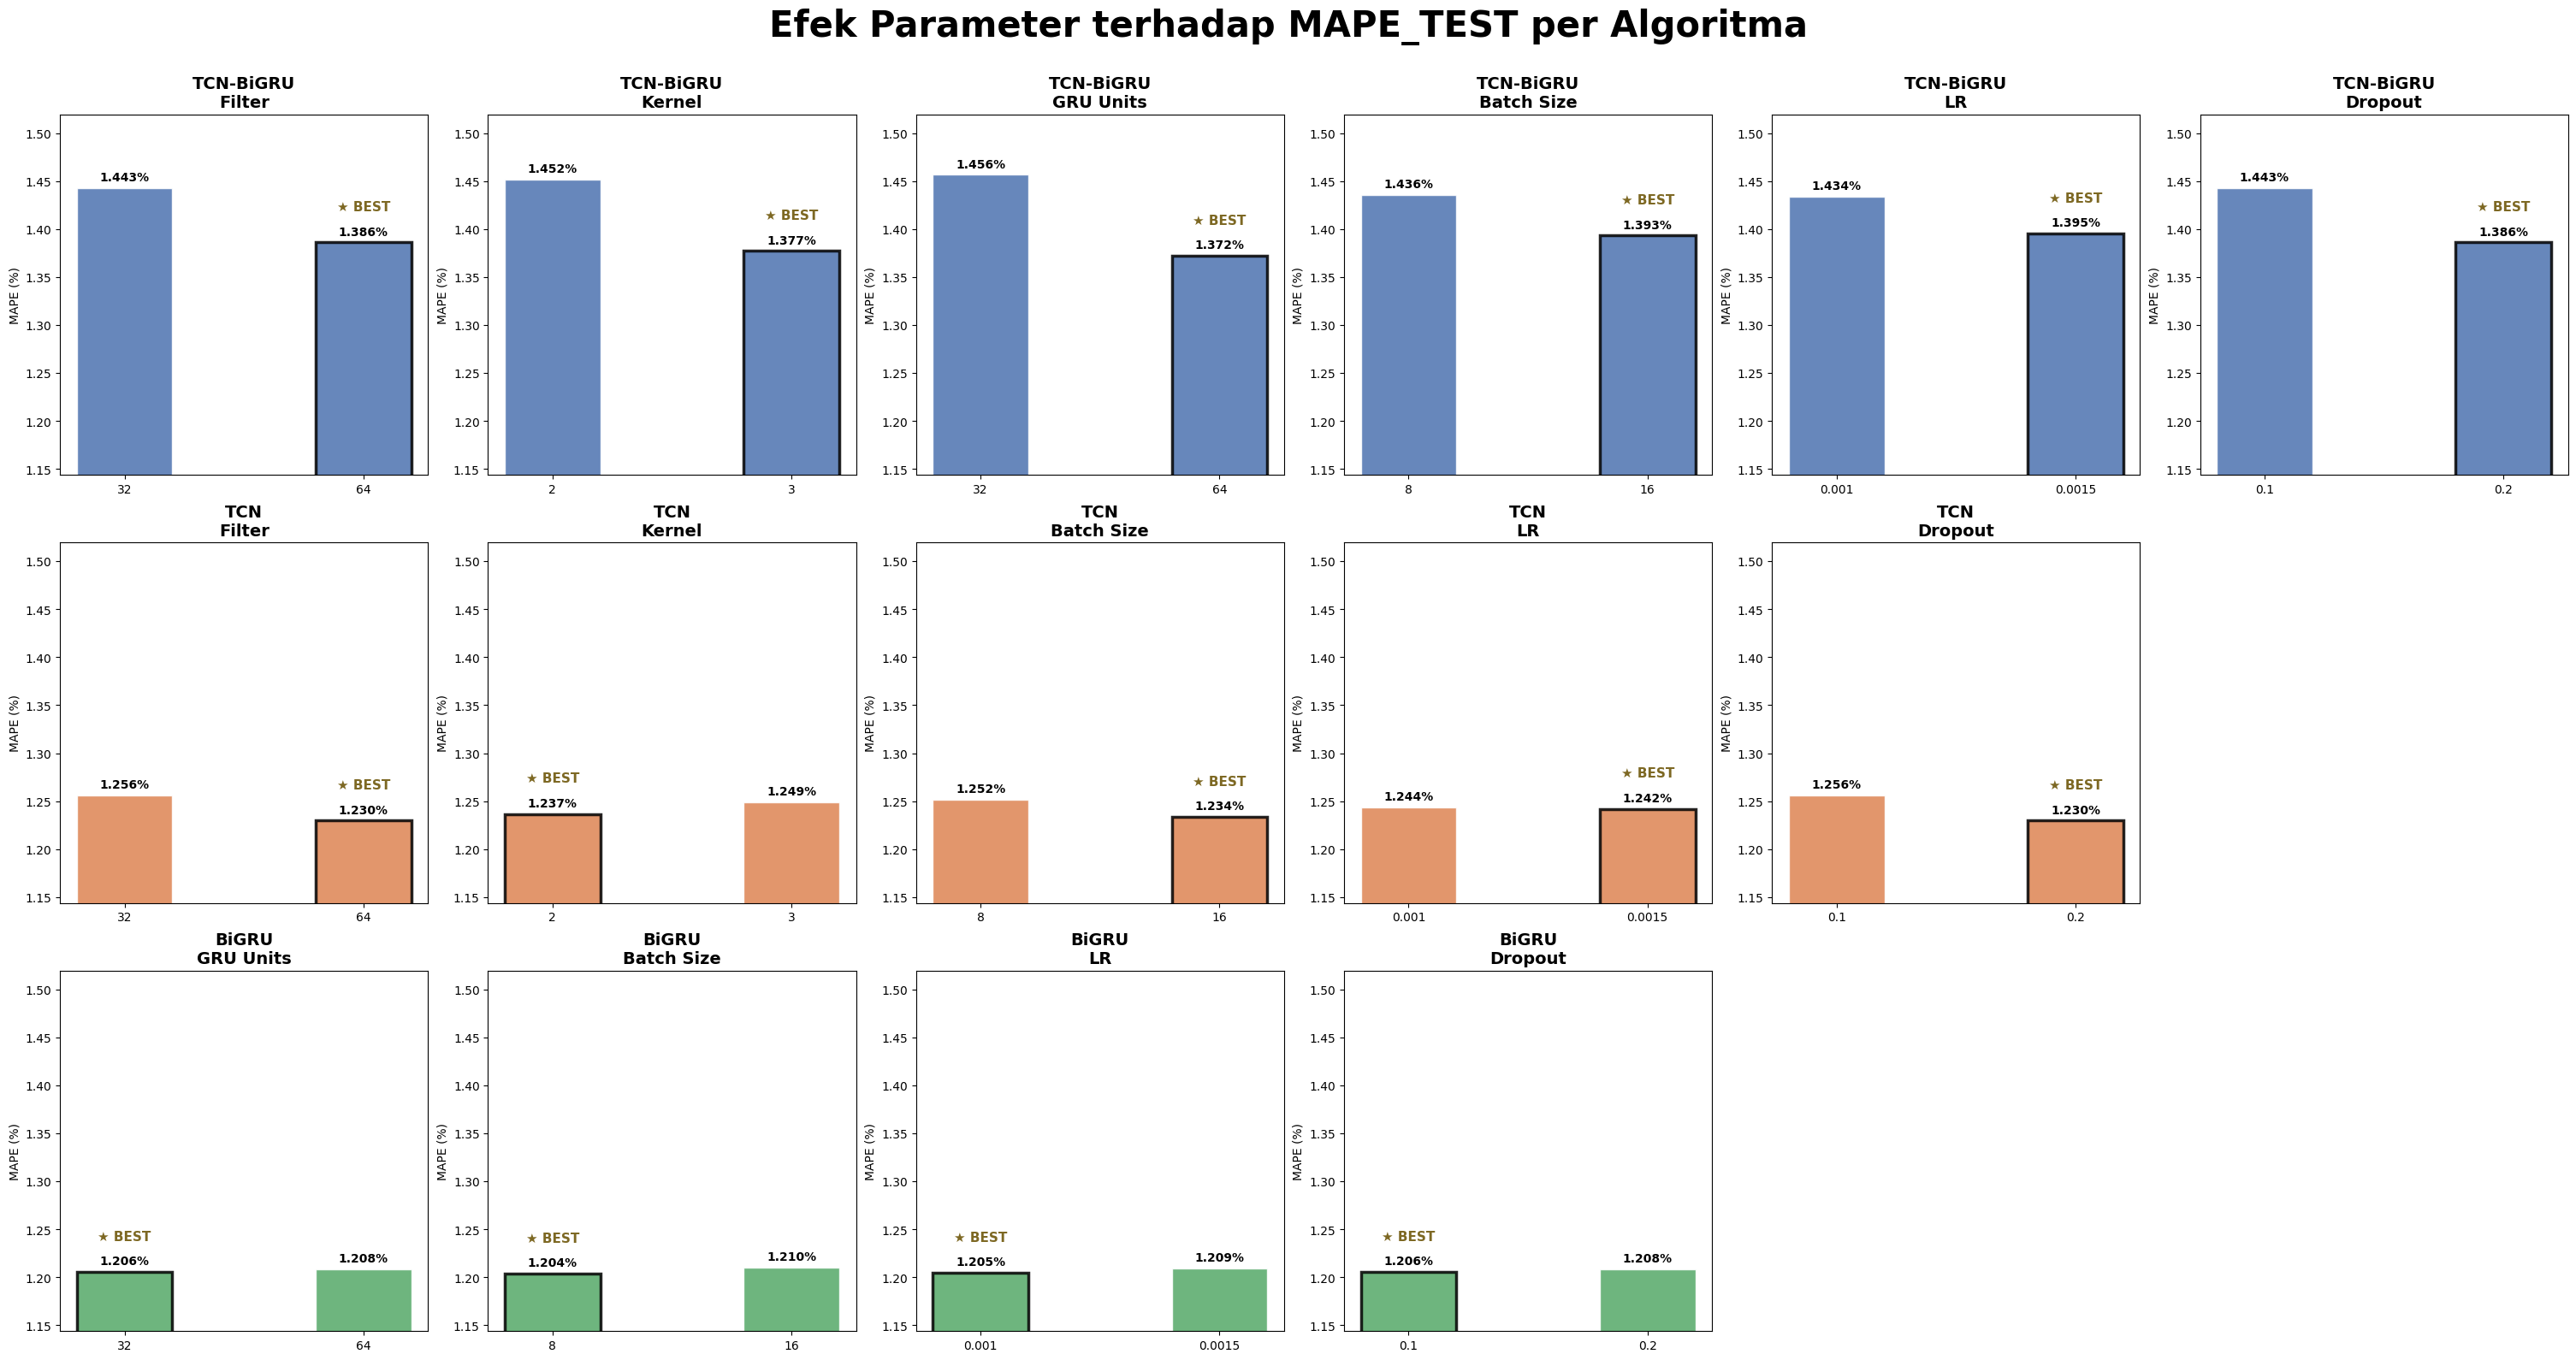

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =================================================================
# 1. LOAD & PREPARE DATAFRAME
# =================================================================
df_tuning_tcn_bigru = pd.DataFrame(tcn_bigru["tuning_table_data"])
df_tuning_tcn       = pd.DataFrame(tcn["tuning_table_data"])
df_tuning_bigru     = pd.DataFrame(bigru["tuning_table_data"])

df_tuning_tcn_bigru["Algo"] = "TCN-BiGRU"
df_tuning_tcn["Algo"]       = "TCN"
df_tuning_bigru["Algo"]     = "BiGRU"


# =================================================================
# 2. FUNGSI SUNTIK DROPOUT OTOMATIS (Mencegah ValueError)
# =================================================================
def inject_dropout_by_combination(df_tuning):
    # Cari tahu berapa banyak kombinasi unik di model ini
    total_kombinasi_unik = df_tuning["Kombinasi Ke-"].nunique()
    setengah = total_kombinasi_unik // 2
    
    # Buat mapper otomatis: setengah awal diisi 0.1, setengah akhir diisi 0.2
    mapper = {i+1: (0.1 if i < setengah else 0.2) for i in range(total_kombinasi_unik)}
    
    # Petakan ke dalam baris dataframe berdasarkan kolom 'Kombinasi Ke-'
    return df_tuning["Kombinasi Ke-"].map(mapper)

# Eksekusi suntikan Dropout asli (0.1 dan 0.2) ke masing-masing DataFrame
df_tuning_tcn_bigru["Dropout"] = inject_dropout_by_combination(df_tuning_tcn_bigru)
df_tuning_tcn["Dropout"]       = inject_dropout_by_combination(df_tuning_tcn)
df_tuning_bigru["Dropout"]     = inject_dropout_by_combination(df_tuning_bigru)


# =================================================================
# 3. KANALISASI MAPPING PARAMETER & STRUKTUR GRAFIK
# =================================================================
param_cols_map = {
    "TCN-BiGRU": [c for c in df_tuning_tcn_bigru.columns if c in ["Filter", "Kernel", "GRU Units", "Dropout", "Batch Size", "LR"]],
    "TCN":       [c for c in df_tuning_tcn.columns       if c in ["Filter", "Kernel", "Dropout", "Batch Size", "LR"]],
    "BiGRU":     [c for c in df_tuning_bigru.columns     if c in ["GRU Units", "Dropout", "Batch Size", "LR"]],
}

tuning_map = {
    "TCN-BiGRU": df_tuning_tcn_bigru,
    "TCN":       df_tuning_tcn,
    "BiGRU":     df_tuning_bigru,
}

color_map = {
    "TCN-BiGRU": "#4C72B0",
    "TCN":       "#DD8452",
    "BiGRU":     "#55A868",
}

n_cols = max(len(v) for v in param_cols_map.values())
n_rows = len(param_cols_map)


# =================================================================
# 4. HITUNG SKALA Y GLOBAL (BIAR TINGGI BATANG SERAGAM & RAPI)
# =================================================================
all_mape_values = []
for algo_name, df_a in tuning_map.items():
    param_cols = param_cols_map[algo_name]
    for p in param_cols:
        all_mape_values.extend(df_a.groupby(p)["MAPE (%)"].mean().tolist())

global_mape_min = min(all_mape_values)
global_mape_max = max(all_mape_values)

# Sediakan padding atas agar text "★ BEST" tidak keluar dari batas grafik
y_limit_lower = global_mape_min * 0.95 
y_limit_upper = global_mape_max + (global_mape_max - global_mape_min) * 0.25
global_range  = global_mape_max - global_mape_min


# =================================================================
# 5. PROSES DRAWING GRAFIK MATPLOTLIB
# =================================================================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 15), layout='constrained')
fig.suptitle("Efek Parameter terhadap MAPE_TEST per Algoritma", 
             fontsize=30, fontweight='bold', y=1.05)

for row_idx, (algo_name, param_cols) in enumerate(param_cols_map.items()):
    df_a  = tuning_map[algo_name]
    color = color_map[algo_name]

    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]

        if col_idx < len(param_cols):
            param   = param_cols[col_idx]
            grouped = df_a.groupby(param)["MAPE (%)"].mean().reset_index()

            # Plot Batang Grafik
            bars = ax.bar(grouped[param].astype(str), grouped["MAPE (%)"],
                          color=color, alpha=0.85, edgecolor='white', width=0.4)

            # Set limit sumbu Y seragam
            ax.set_ylim(y_limit_lower, y_limit_upper)
            
            # Beri teks nilai persentase di atas setiap batang
            for bar, val in zip(bars, grouped["MAPE (%)"]):
                ax.text(bar.get_x() + bar.get_width()/2, 
                        val + (global_range * 0.02), 
                        f"{val:.3f}%", ha='center', va='bottom', 
                        fontsize=10, fontweight='bold')
                
            # Logika Otomatis Menandai Bintang pada Model Terbaik (MAPE Terendah)
            best_idx = grouped["MAPE (%)"].idxmin()
            bars[best_idx].set_edgecolor('black')
            bars[best_idx].set_linewidth(2.5)
            
            ax.text(bars[best_idx].get_x() + bars[best_idx].get_width()/2, 
                    bars[best_idx].get_height() + (global_range * 0.12), 
                    "★ BEST", ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', color="#7D6823")

            # Atur Labeling Grafik
            ax.set_title(f"{algo_name}\n{param}", fontsize=14, fontweight='bold')
            ax.set_ylabel("MAPE (%)", fontsize=10)
            ax.tick_params(axis='both', labelsize=10)

        else:
            # Sembunyikan sisa kotak sub-plot yang kosong agar terlihat clean
            ax.axis('off')

plt.show()

In [ ]:
print("Kolom TCN-BiGRU:", df_tuning_tcn_bigru.columns.tolist())
print("Kolom TCN:", df_tuning_tcn.columns.tolist())
print("Kolom BiGRU:", df_tuning_bigru.columns.tolist())

Kolom TCN-BiGRU: ['Kombinasi Ke-', 'Split', 'Filter', 'Kernel', 'GRU Units', 'Batch Size', 'LR', 'Best Epoch', 'MAPE (%)', 'Time (sec)', 'Algo']
Kolom TCN: ['Kombinasi Ke-', 'Split', 'Filter', 'Kernel', 'Batch Size', 'LR', 'Best Epoch', 'MAPE (%)', 'Time (sec)', 'Algo']
Kolom BiGRU: ['Kombinasi Ke-', 'Split', 'GRU Units', 'Batch Size', 'LR', 'Best Epoch', 'MAPE (%)', 'Time (sec)', 'Algo']


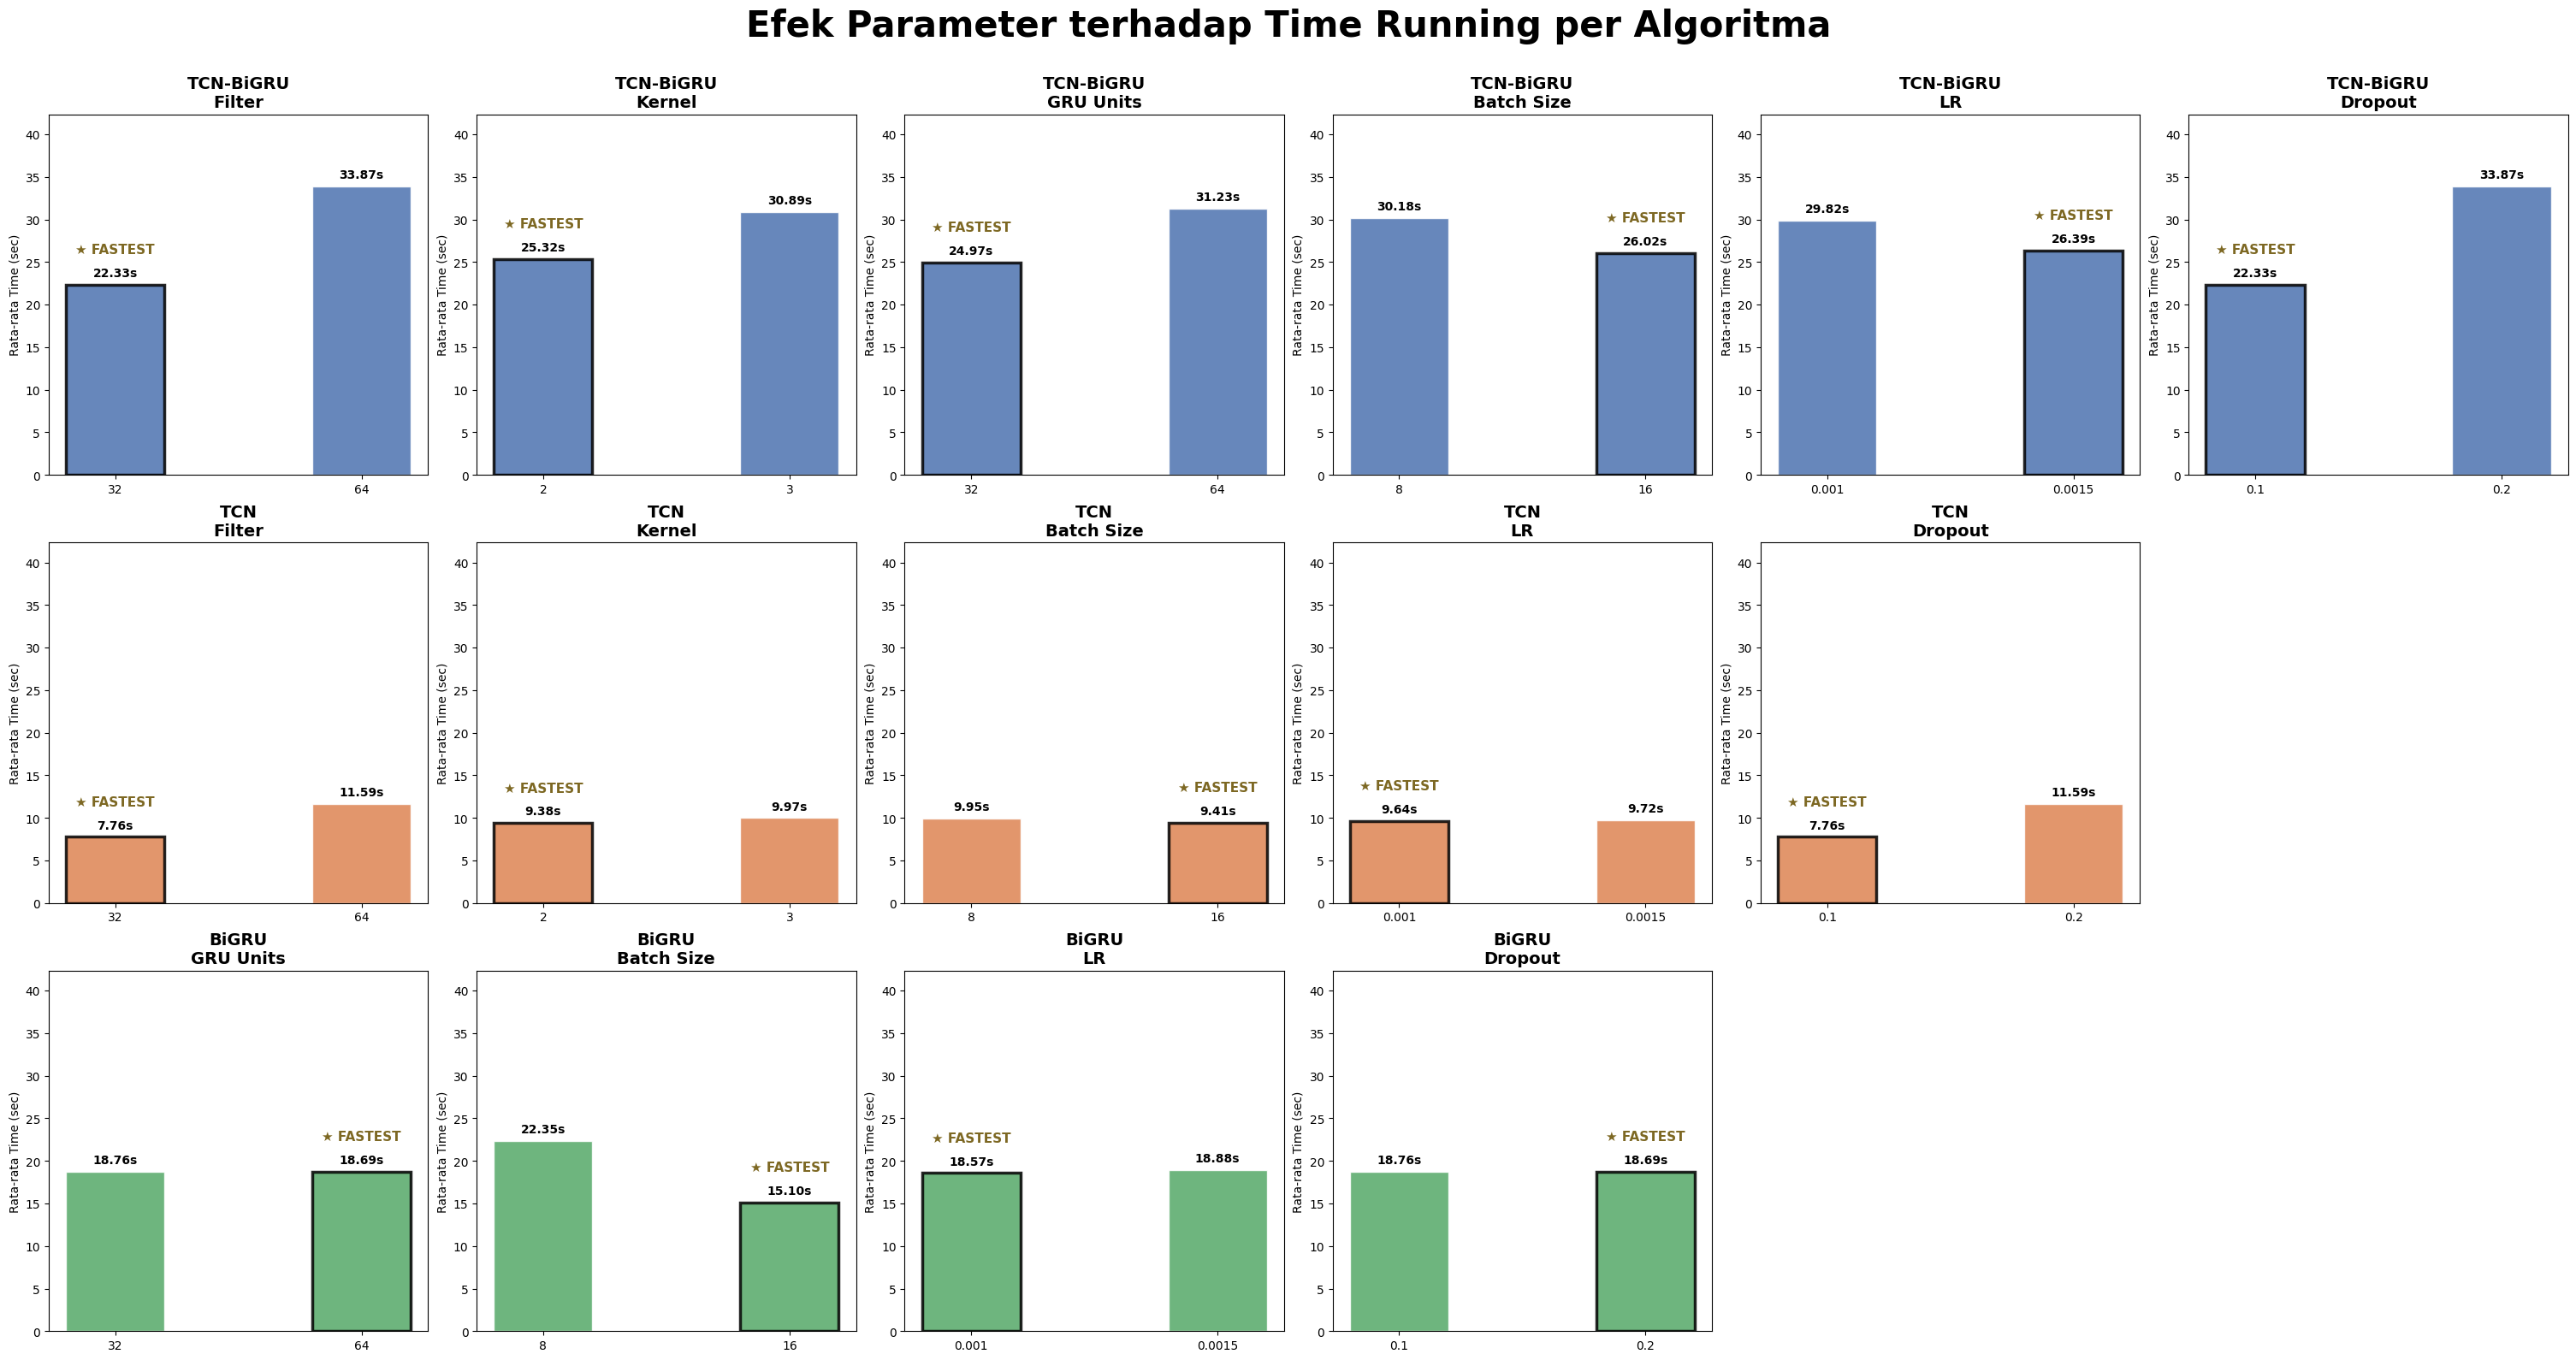

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# *Pastikan blok kode suntik dropout yang sebelumnya sudah dieksekusi terlebih dahulu 
# agar kolom "Dropout" sudah tersedia di dalam df_tuning_tcn_bigru, dll.

# =================================================================
# 1. KANALISASI MAPPING PARAMETER & STRUKTUR GRAFIK (IKUT SERTAKAN DROPOUT)
# =================================================================
param_cols_map = {
    "TCN-BiGRU": [c for c in df_tuning_tcn_bigru.columns if c in ["Filter", "Kernel", "GRU Units", "Dropout", "Batch Size", "LR"]],
    "TCN":       [c for c in df_tuning_tcn.columns       if c in ["Filter", "Kernel", "Dropout", "Batch Size", "LR"]],
    "BiGRU":     [c for c in df_tuning_bigru.columns     if c in ["GRU Units", "Dropout", "Batch Size", "LR"]],
}

tuning_map = {
    "TCN-BiGRU": df_tuning_tcn_bigru,
    "TCN":       df_tuning_tcn,
    "BiGRU":     df_tuning_bigru,
}

color_map = {
    "TCN-BiGRU": "#4C72B0",
    "TCN":       "#DD8452",
    "BiGRU":     "#55A868",
}

n_cols = max(len(v) for v in param_cols_map.values())
n_rows = len(param_cols_map)


# =================================================================
# 2. CARI NILAI MAKSIMUM GLOBAL UNTUK SKALA Y SERAGAM
# =================================================================
all_means = []
for algo_name, df_a in tuning_map.items():
    param_cols = param_cols_map[algo_name]
    for p in param_cols:
        all_means.extend(df_a.groupby(p)["Time (sec)"].mean().tolist())

global_max_time = max(all_means)

# Beri padding atas sekitar 25% agar teks label "★ FASTEST" tidak terpotong bingkai
y_limit_upper = global_max_time * 1.25


# =================================================================
# 3. PROSES PLOTTING TIME RUNNING DENGAN MATPLOTLIB
# =================================================================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 15), layout='constrained')
fig.suptitle("Efek Parameter terhadap Time Running per Algoritma",
             fontsize=30, fontweight='bold', y=1.05)

for row_idx, (algo_name, param_cols) in enumerate(param_cols_map.items()):
    df_a  = tuning_map[algo_name]
    color = color_map[algo_name]

    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]

        if col_idx < len(param_cols):
            param   = param_cols[col_idx]
            grouped = df_a.groupby(param)["Time (sec)"].mean().reset_index()

            # Plot Batang Grafik Waktu
            bars = ax.bar(grouped[param].astype(str), grouped["Time (sec)"],
                          color=color, alpha=0.85, edgecolor='white', width=0.4)

            # Set skala Y seragam dari 0 sampai batas atas global
            ax.set_ylim(0, y_limit_upper)

            # Cetak label teks durasi detik (s) di atas setiap batang
            for bar, val in zip(bars, grouped["Time (sec)"]):
                ax.text(bar.get_x() + bar.get_width()/2,
                        val + (global_max_time * 0.02), 
                        f"{val:.2f}s", ha='center', va='bottom',
                        fontsize=10, fontweight='bold')

            # LOGIKA HIGHLIGHT TERCEPAT (Mencari Nilai Minimum/idxmin)
            best_idx = grouped["Time (sec)"].idxmin()
            bars[best_idx].set_edgecolor('black')
            bars[best_idx].set_linewidth(2.5)
            
            # Beri tanda bintang FASTEST di atas batang yang paling rendah durasinya
            ax.text(bars[best_idx].get_x() + bars[best_idx].get_width()/2,
                    bars[best_idx].get_height() + (global_max_time * 0.1),
                    "★ FASTEST", ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color="#7D6823")

            # Mengatur atribut teks dan label pada Subplot
            ax.set_title(f"{algo_name}\n{param}", fontsize=14, fontweight='bold')
            ax.set_ylabel("Rata-rata Time (sec)", fontsize=10)
            ax.tick_params(axis='both', labelsize=10)
        else:
            # Sembunyikan sisa kotak kosong agar layout rapi dan bersih
            ax.axis('off')

plt.show()

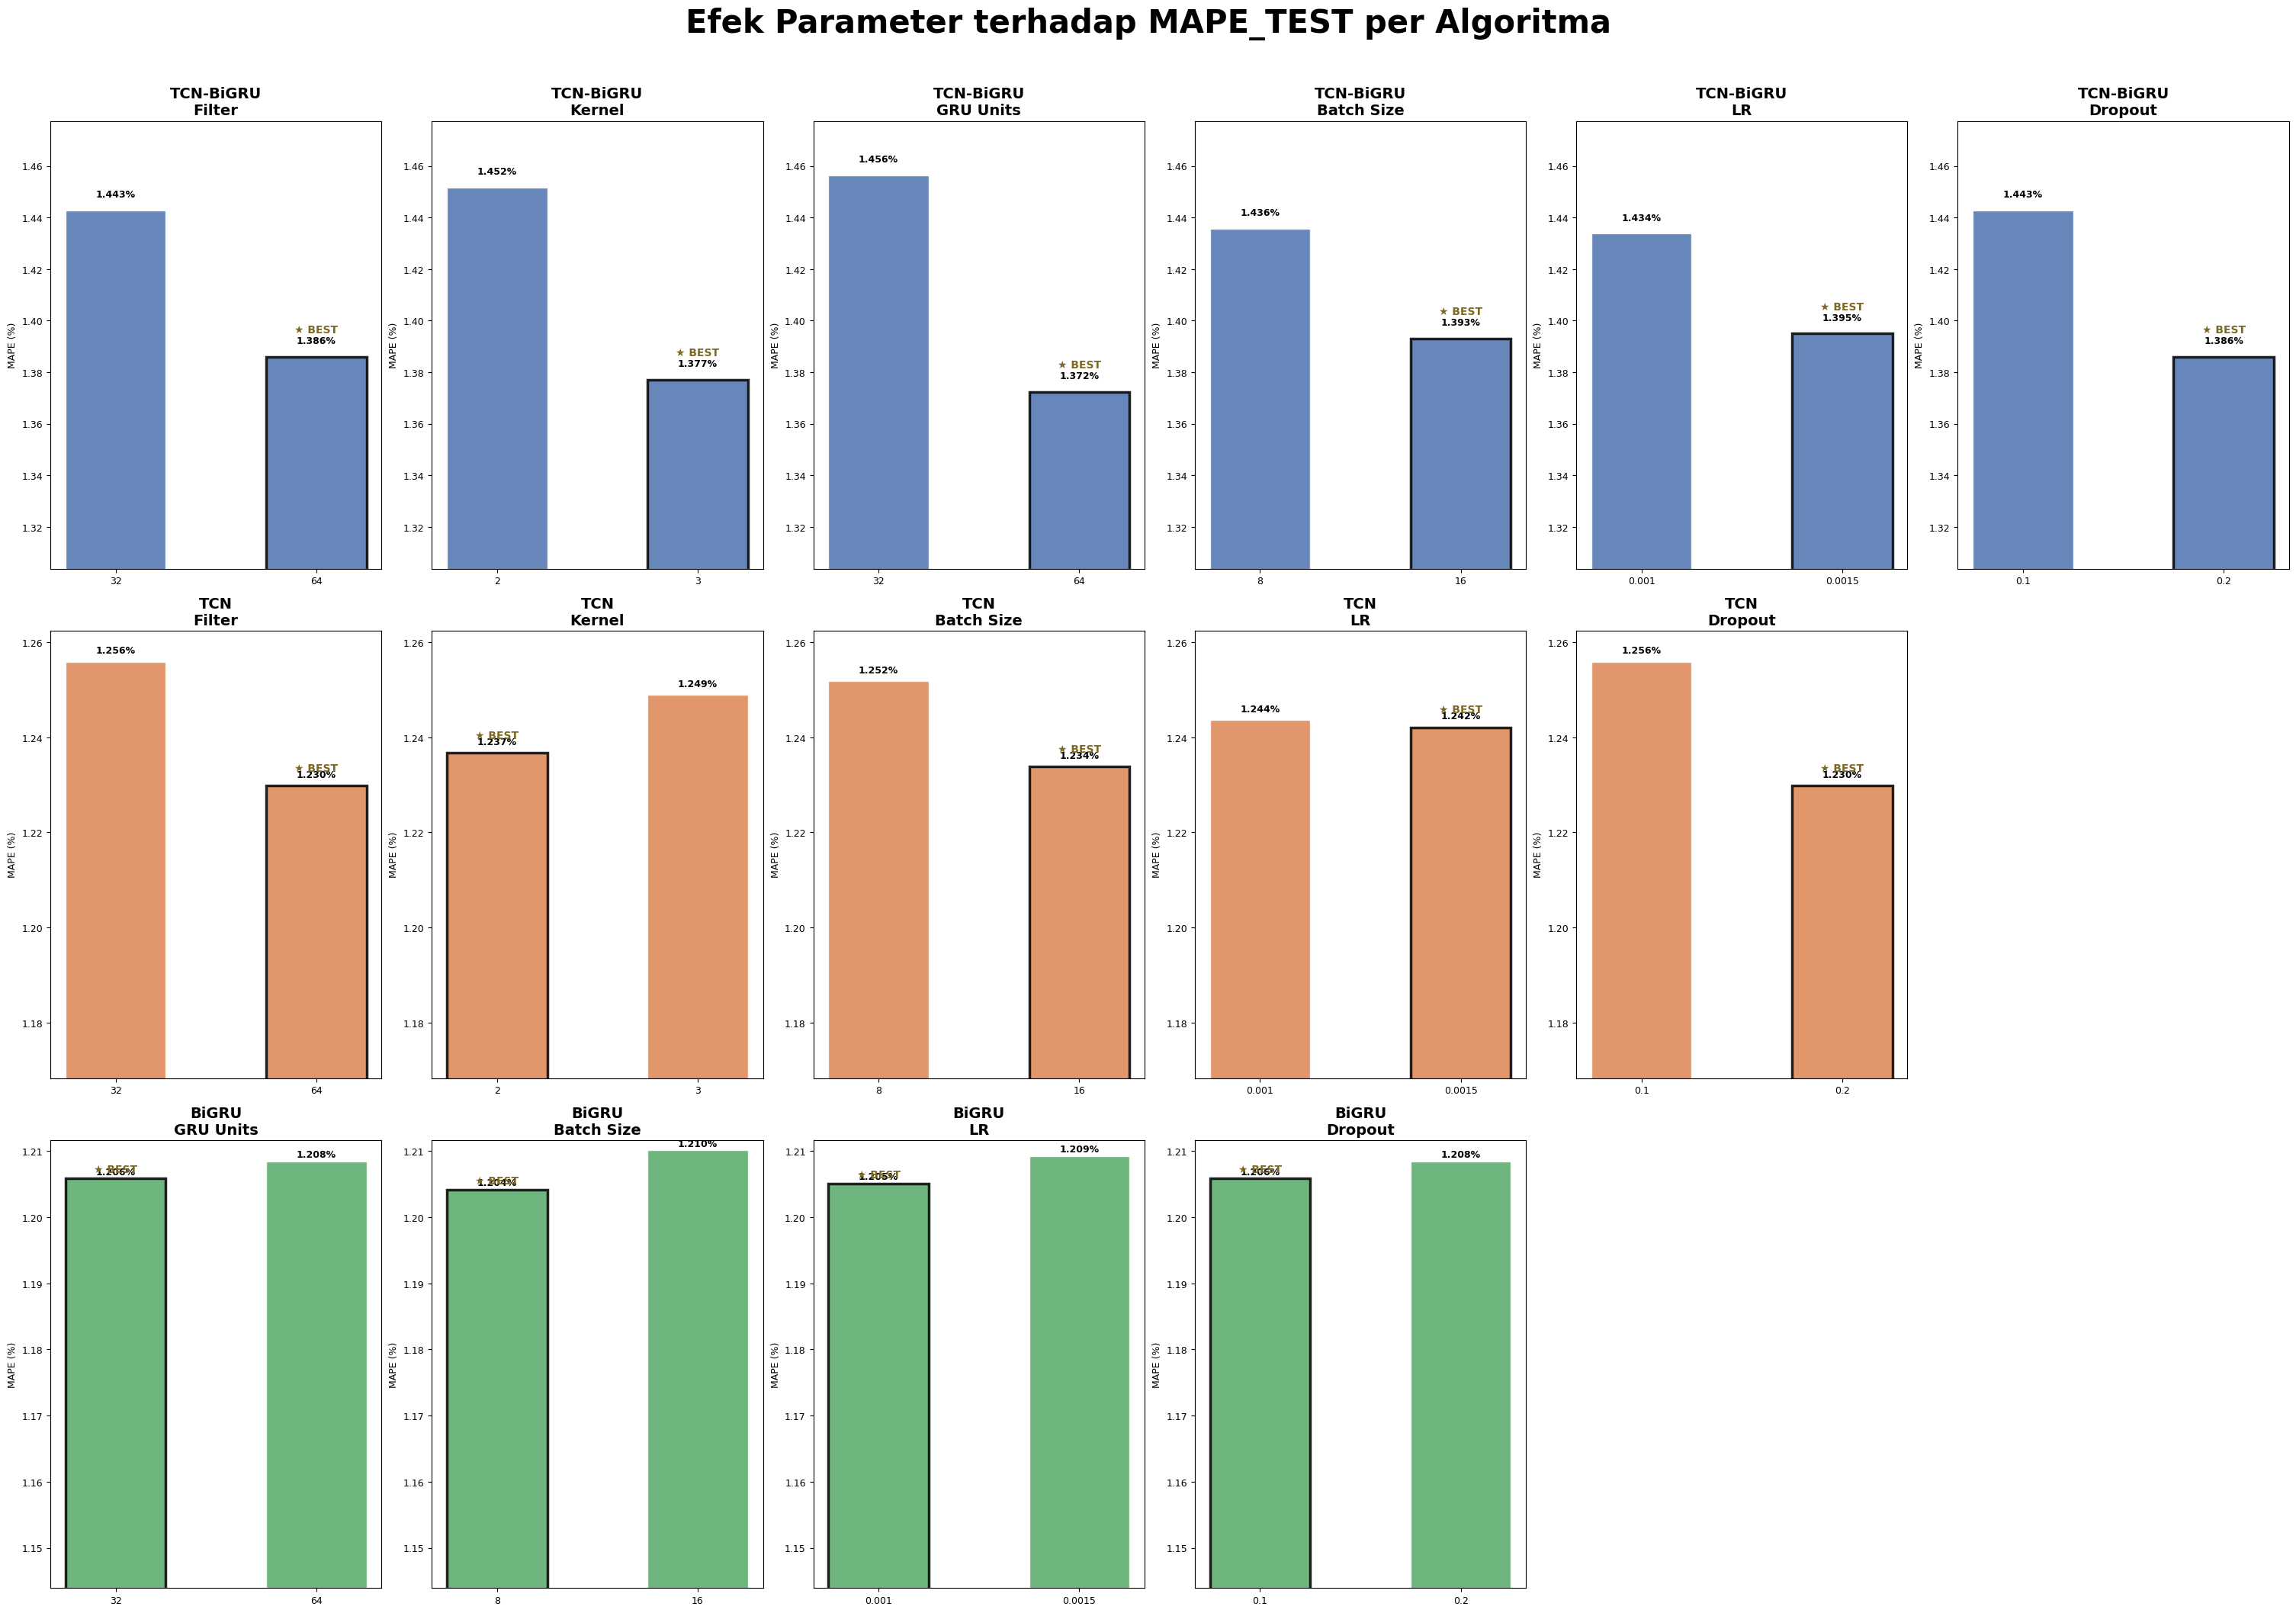

In [ ]:
# ===============================
# GRAFIK MAPE — SKALA PER ALGO
# ===============================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 20), layout='constrained')
fig.suptitle("Efek Parameter terhadap MAPE_TEST per Algoritma",
             fontsize=30, fontweight='bold', y=1.05)

for row_idx, (algo_name, param_cols) in enumerate(param_cols_map.items()):
    df_a  = tuning_map[algo_name]
    color = color_map[algo_name]

    # ← Hitung batas Y khusus algo ini saja
    algo_mape_values = []
    for p in param_cols:
        algo_mape_values.extend(df_a.groupby(p)["MAPE (%)"].mean().tolist())
    algo_min = min(algo_mape_values)
    algo_max = max(algo_mape_values)
    algo_range = algo_max - algo_min if algo_max != algo_min else 0.1
    y_lower = algo_min * 0.95
    y_upper = algo_max + algo_range * 0.25  # padding buat ★ BEST

    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]
        if col_idx < len(param_cols):
            param   = param_cols[col_idx]
            grouped = df_a.groupby(param)["MAPE (%)"].mean().reset_index()
            bars = ax.bar(grouped[param].astype(str), grouped["MAPE (%)"],
                          color=color, alpha=0.85, edgecolor='white', width=0.5)

            ax.set_ylim(y_lower, y_upper)  # ← skala per algo

            for bar, val in zip(bars, grouped["MAPE (%)"]):
                ax.text(bar.get_x() + bar.get_width()/2,
                        val + algo_range * 0.05,
                        f"{val:.3f}%", ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

            best_idx = grouped["MAPE (%)"].idxmin()
            bars[best_idx].set_edgecolor('black')
            bars[best_idx].set_linewidth(2.5)
            ax.text(bars[best_idx].get_x() + bars[best_idx].get_width()/2,
                    bars[best_idx].get_height() + algo_range * 0.1,
                    "★ BEST", ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color="#7D6823")

            ax.set_title(f"{algo_name}\n{param}", fontsize=14, fontweight='bold')
            ax.set_ylabel("MAPE (%)", fontsize=9)
            ax.tick_params(axis='both', labelsize=9)
        else:
            ax.axis('off')

plt.show()

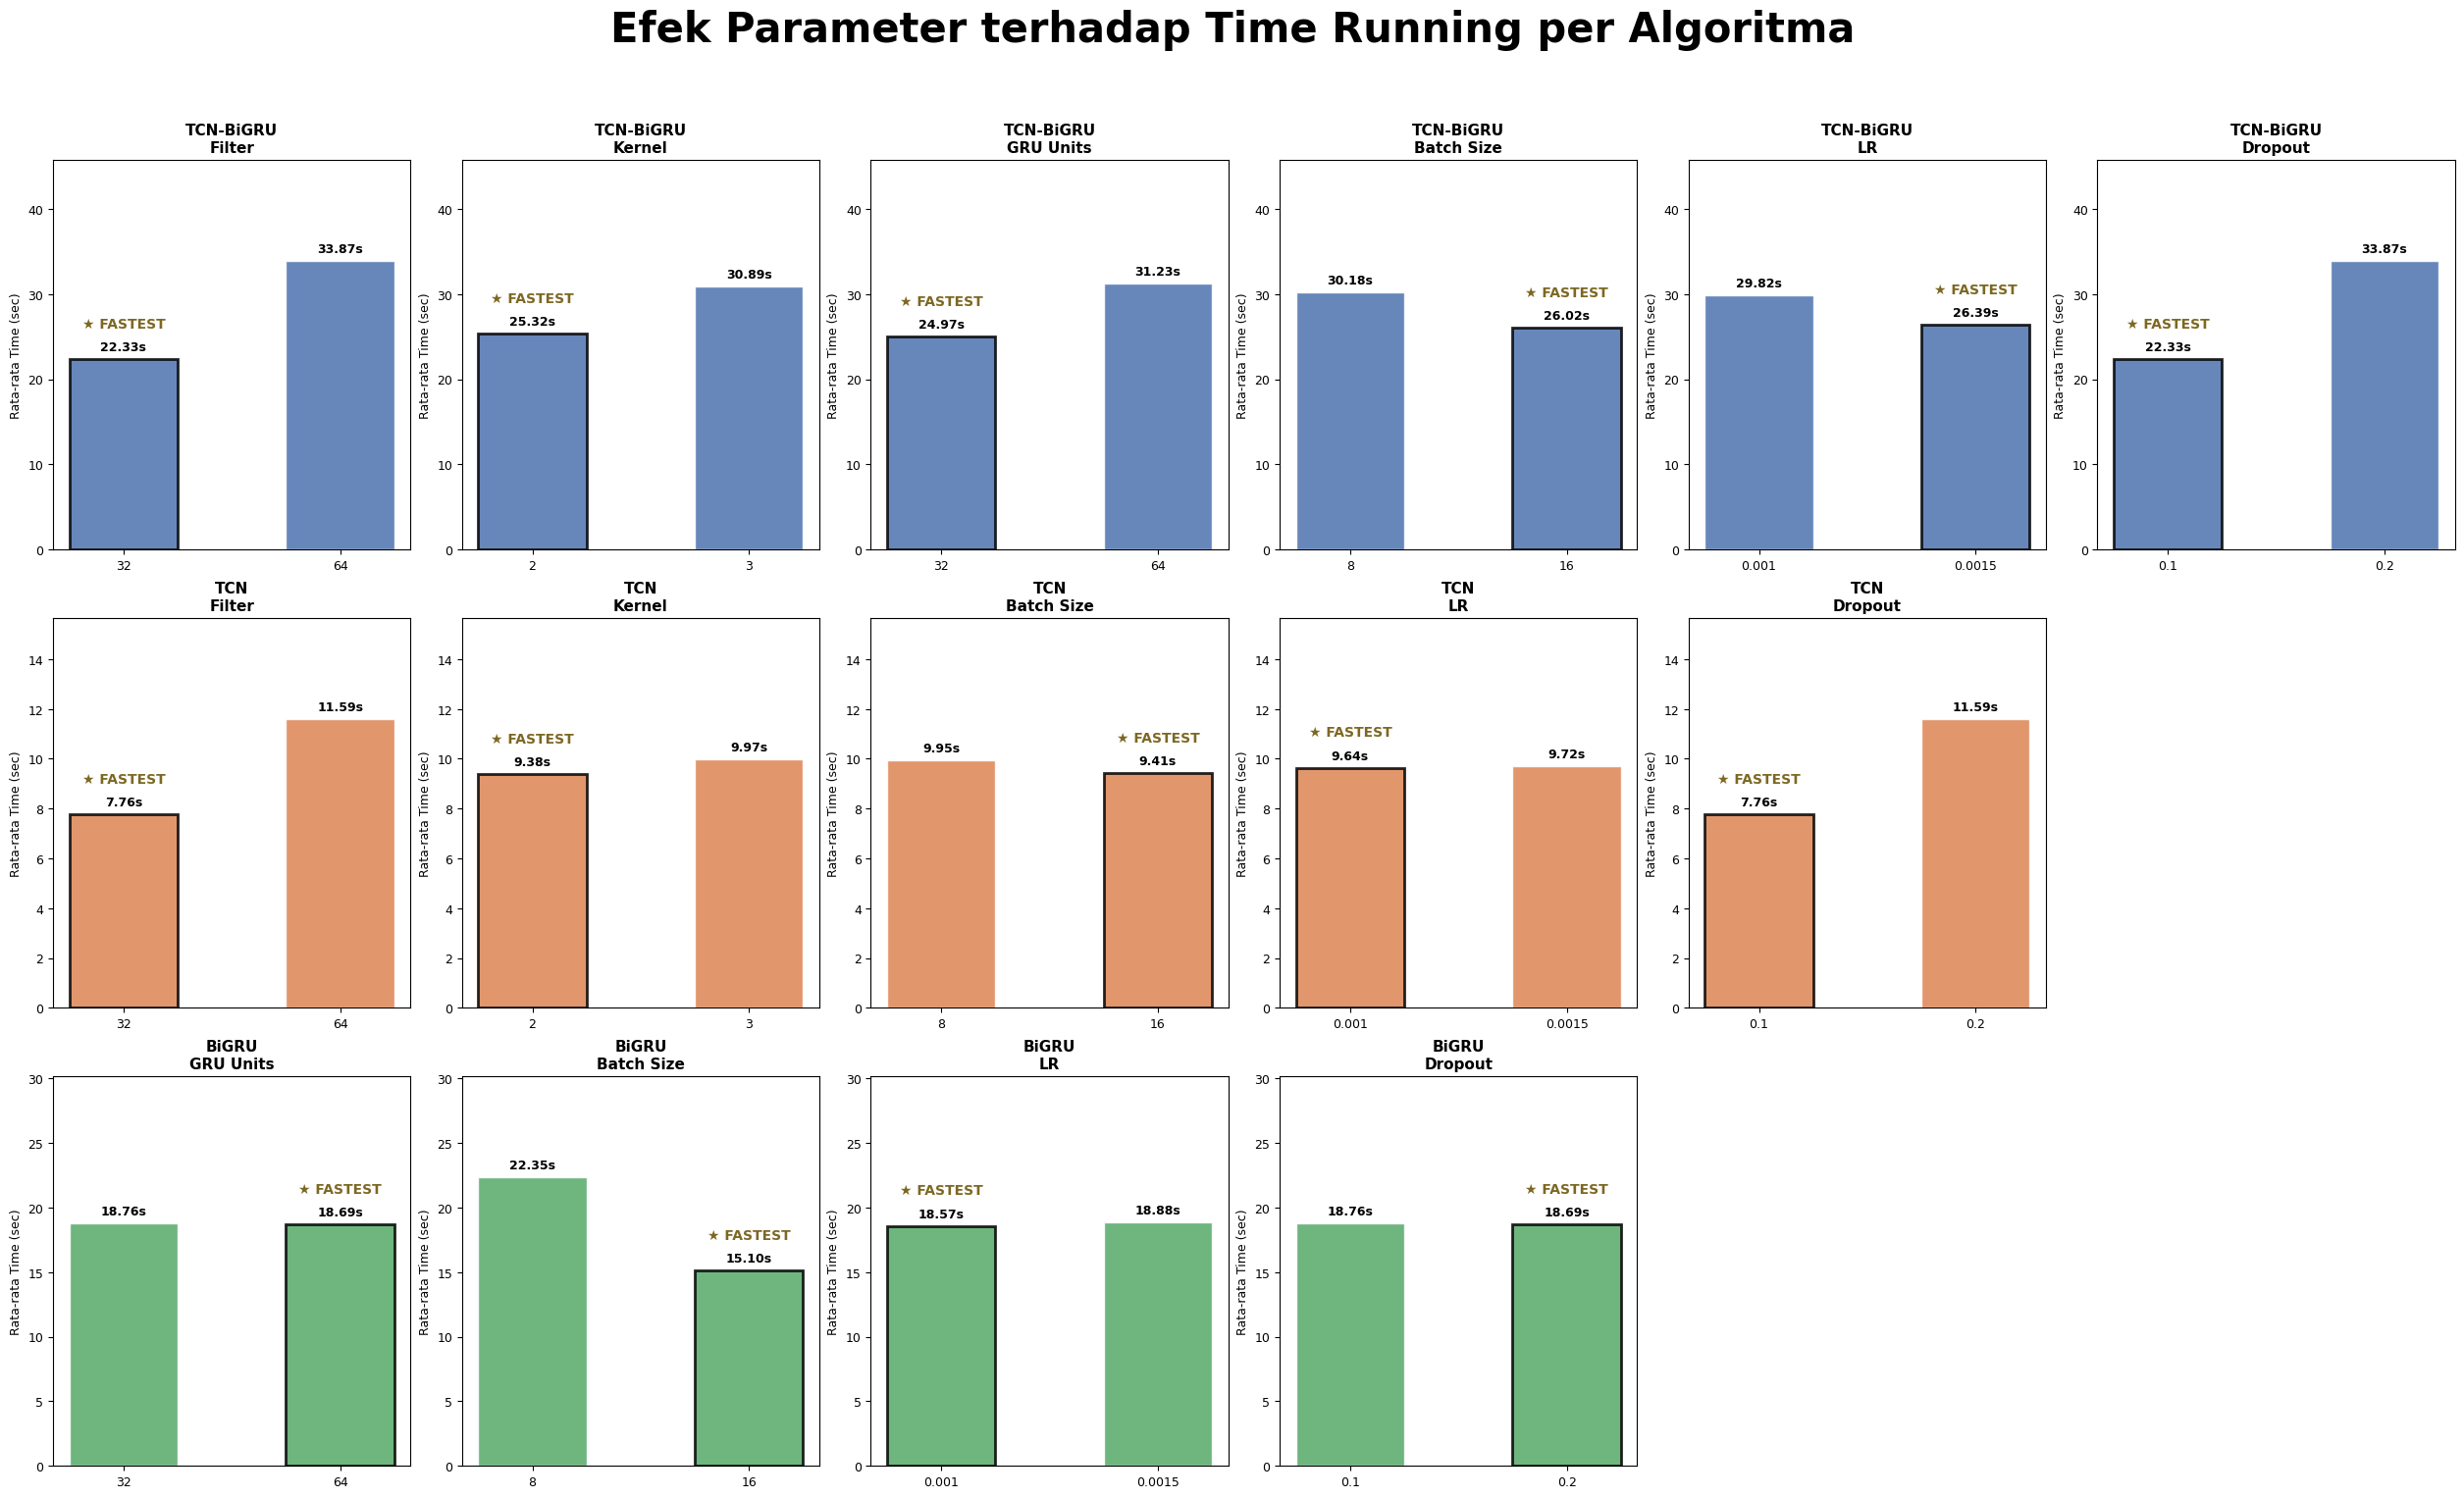

In [ ]:
# ===============================
# GRAFIK TIME — SKALA PER ALGO
# ===============================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 14), layout='constrained')
fig.suptitle("Efek Parameter terhadap Time Running per Algoritma",
             fontsize=30, fontweight='bold', y=1.08)

for row_idx, (algo_name, param_cols) in enumerate(param_cols_map.items()):
    df_a  = tuning_map[algo_name]
    color = color_map[algo_name]

    # ← Hitung batas Y khusus algo ini saja
    algo_time_values = []
    for p in param_cols:
        algo_time_values.extend(df_a.groupby(p)["Time (sec)"].mean().tolist())
    algo_max_time = max(algo_time_values)
    y_upper = algo_max_time * 1.35  # padding buat ★ FASTEST

    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]
        if col_idx < len(param_cols):
            param   = param_cols[col_idx]
            grouped = df_a.groupby(param)["Time (sec)"].mean().reset_index()
            bars = ax.bar(grouped[param].astype(str), grouped["Time (sec)"],
                          color=color, alpha=0.85, edgecolor='white', width=0.5)

            ax.set_ylim(0, y_upper)  # ← skala per algo, mulai dari 0

            for bar, val in zip(bars, grouped["Time (sec)"]):
                ax.text(bar.get_x() + bar.get_width()/2,
                        val + algo_max_time * 0.02,
                        f"{val:.2f}s", ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

            best_idx = grouped["Time (sec)"].idxmin()
            bars[best_idx].set_edgecolor('black')
            bars[best_idx].set_linewidth(2)
            ax.text(bars[best_idx].get_x() + bars[best_idx].get_width()/2,
                    bars[best_idx].get_height() + algo_max_time * 0.1,
                    "★ FASTEST", ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color="#7D6823")

            ax.set_title(f"{algo_name}\n{param}", fontsize=11, fontweight='bold')
            ax.set_ylabel("Rata-rata Time (sec)", fontsize=9)
            ax.tick_params(axis='both', labelsize=9)
        else:
            ax.axis('off')

plt.show()

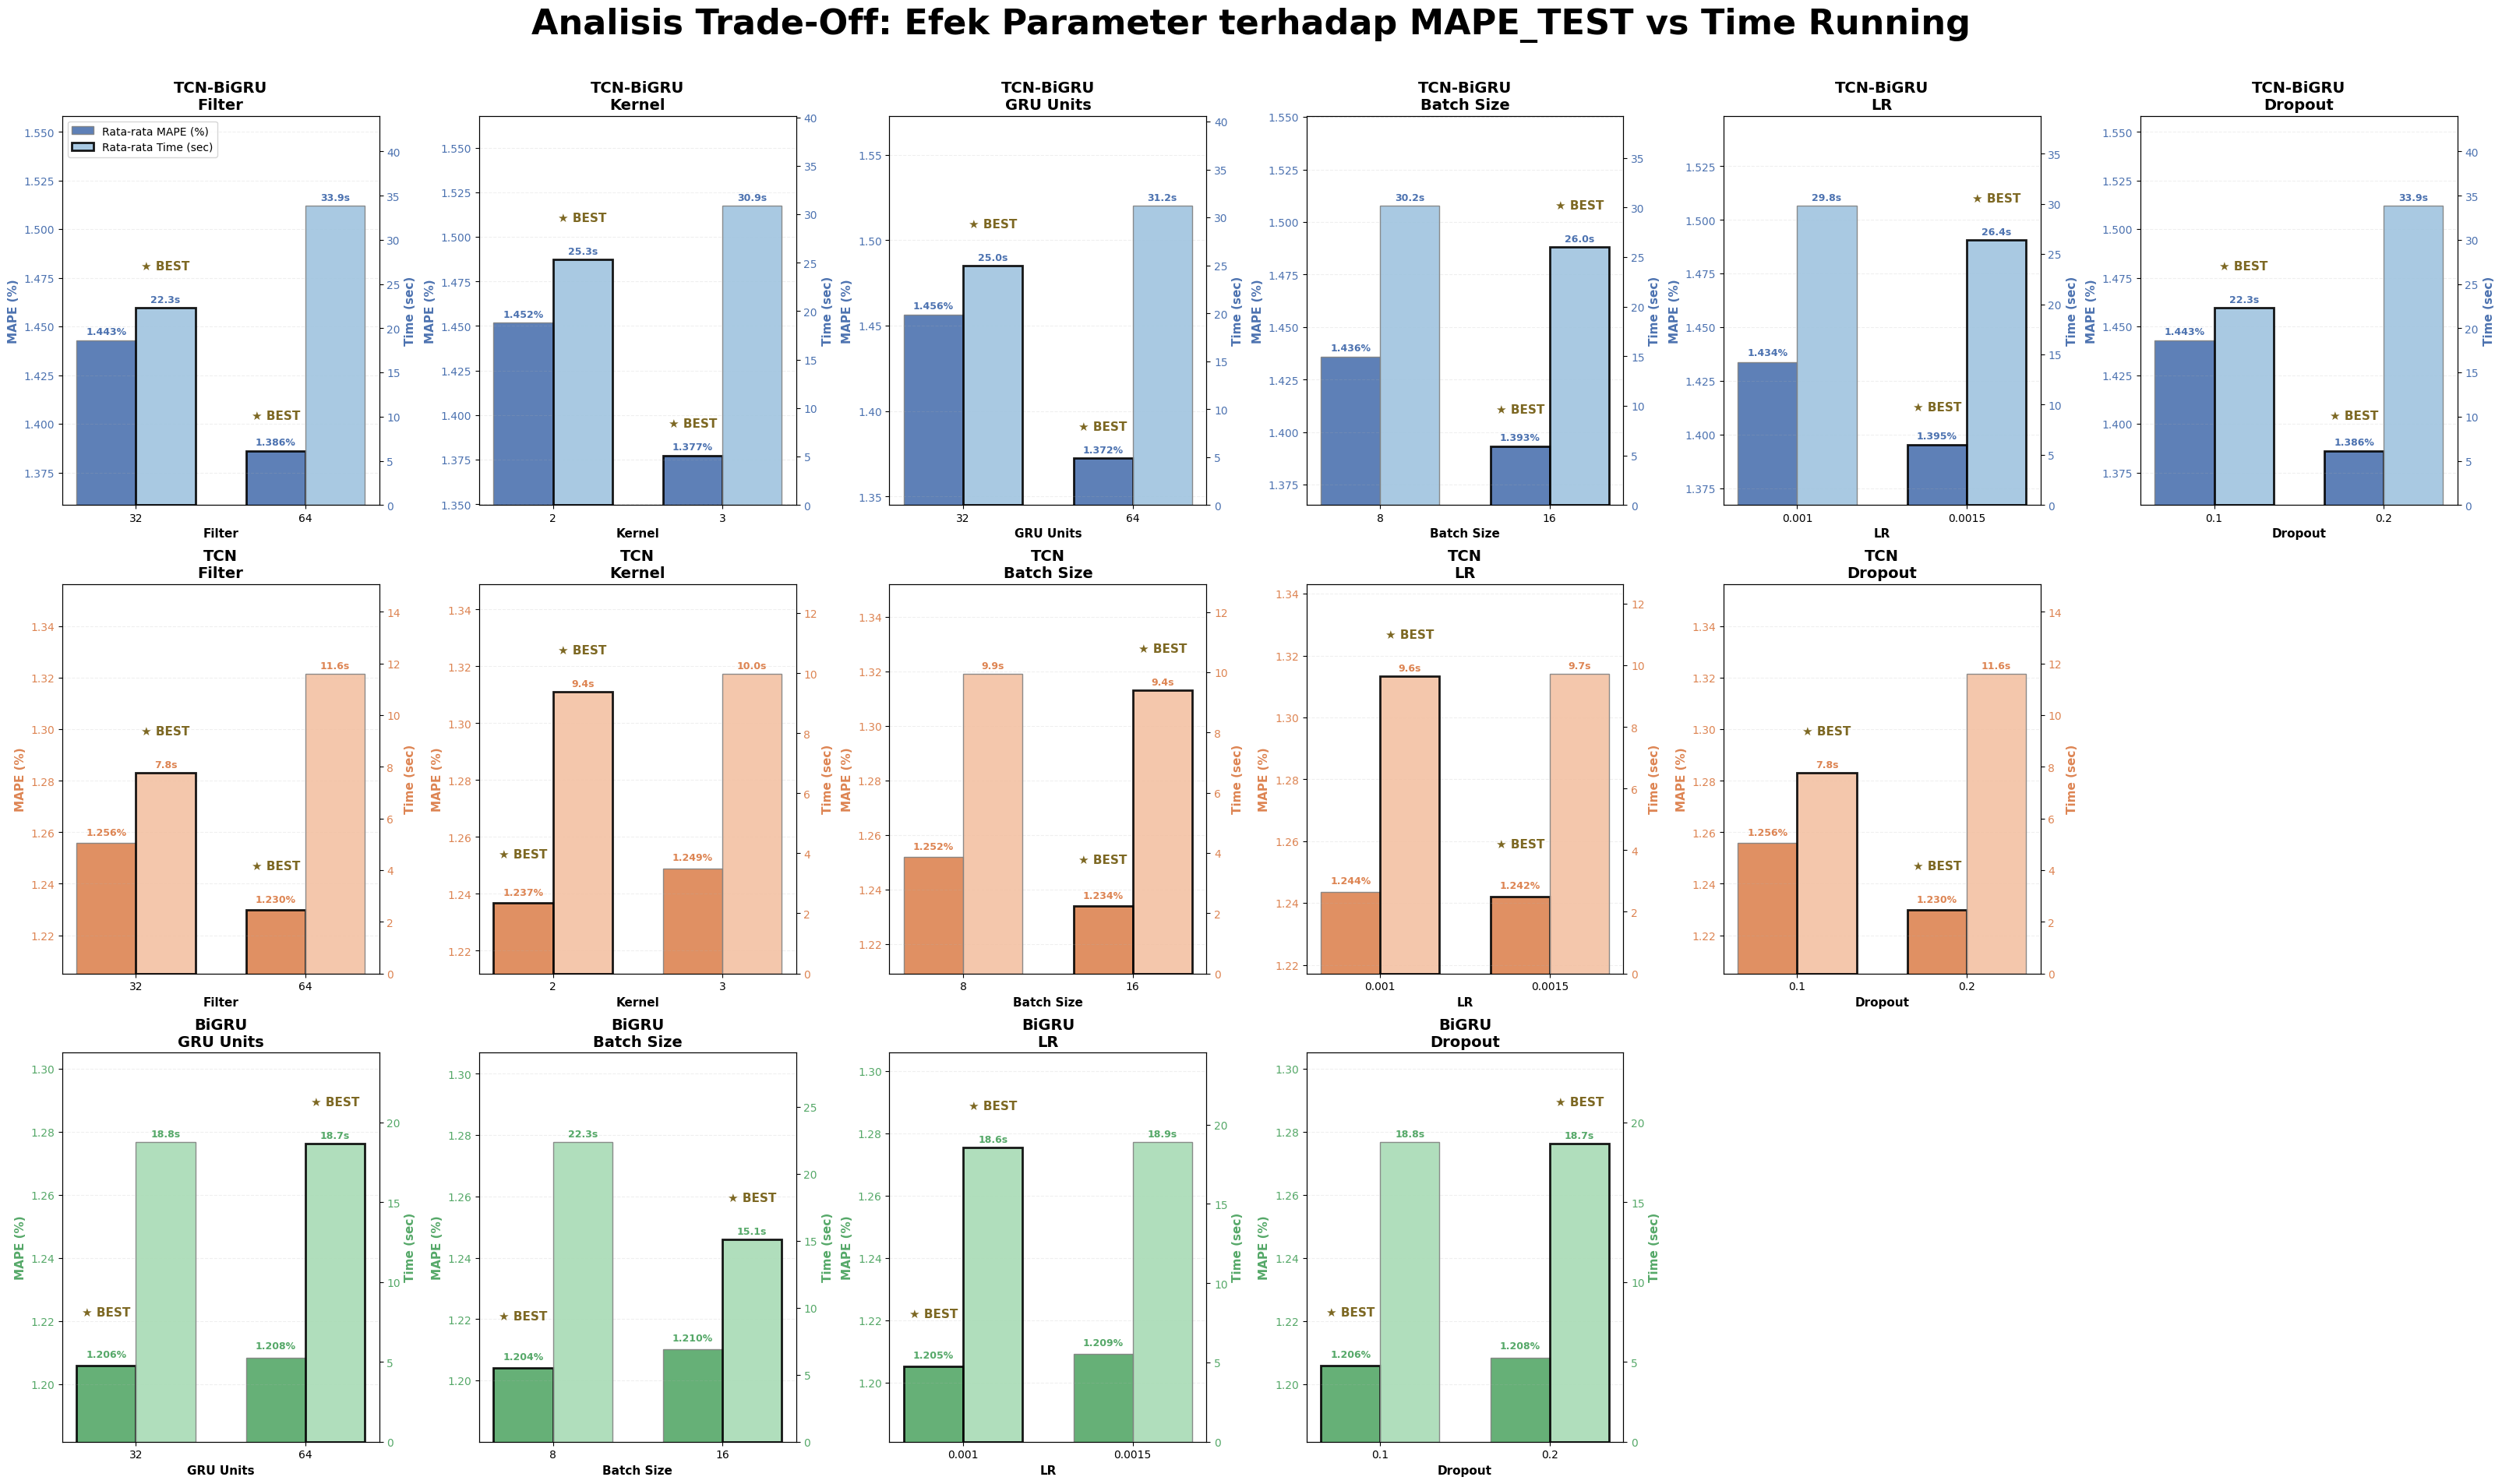

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. KANALISASI MAPPING PARAMETER & STRUKTUR GRAFIK
# =================================================================
param_cols_map = {
    "TCN-BiGRU": [c for c in df_tuning_tcn_bigru.columns if c in ["Filter", "Kernel", "GRU Units", "Dropout", "Batch Size", "LR"]],
    "TCN":       [c for c in df_tuning_tcn.columns       if c in ["Filter", "Kernel", "Dropout", "Batch Size", "LR"]],
    "BiGRU":     [c for c in df_tuning_bigru.columns     if c in ["GRU Units", "Dropout", "Batch Size", "LR"]],
}

tuning_map = {
    "TCN-BiGRU": df_tuning_tcn_bigru,
    "TCN":       df_tuning_tcn,
    "BiGRU":     df_tuning_bigru,
}

color_pairs = {
    "TCN-BiGRU": {"mape": "#4C72B0", "time": "#A0C4DF"},  
    "TCN":       {"mape": "#DD8452", "time": "#F3C1A3"},  
    "BiGRU":     {"mape": "#55A868", "time": "#A8DBB5"},  
}

n_cols = max(len(v) for v in param_cols_map.values())
n_rows = len(param_cols_map)

# =================================================================
# 2. PROSES PLOTTING DOUBLE BAR (ANTI-TABRAKAN VERSION)
# =================================================================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(32, 18), layout='constrained')
fig.suptitle("Analisis Trade-Off: Efek Parameter terhadap MAPE_TEST vs Time Running", 
             fontsize=32, fontweight='bold', y=1.05)

for row_idx, (algo_name, param_cols) in enumerate(param_cols_map.items()):
    df_a = tuning_map[algo_name]
    c_mape = color_pairs[algo_name]["mape"]
    c_time = color_pairs[algo_name]["time"]

    for col_idx in range(n_cols):
        ax1 = axes[row_idx][col_idx]

        if col_idx < len(param_cols):
            param = param_cols[col_idx]
            
            # Groupby untuk mengambil rata-rata MAPE dan Time
            grouped = df_a.groupby(param)[["MAPE (%)", "Time (sec)"]].mean().reset_index()
            
            x_labels = grouped[param].astype(str).tolist()
            x_indexes = np.arange(len(x_labels))
            bar_width = 0.35  
            
            # Cari indeks performa terbaik (Minimum)
            idx_best_mape = grouped["MAPE (%)"].idxmin()
            idx_best_time = grouped["Time (sec)"].idxmin()
            
            # --- SUMBU Y KIRI (MAPE) ---
            bars_mape = ax1.bar(x_indexes - bar_width/2, grouped["MAPE (%)"], 
                                width=bar_width, color=c_mape, alpha=0.9, 
                                edgecolor='grey', label="Rata-rata MAPE (%)")
            
            ax1.set_xlabel(param, fontsize=11, fontweight='bold')
            ax1.set_ylabel("MAPE (%)", color=c_mape, fontsize=11, fontweight='bold')
            ax1.tick_params(axis='y', labelcolor=c_mape, labelsize=10)
            ax1.set_xticks(x_indexes)
            ax1.set_xticklabels(x_labels, fontsize=10)
            
            # Beri padding sumbu Y kiri agak longgar ke atas agar bintang aman
            mape_min, mape_max = grouped["MAPE (%)"].min(), grouped["MAPE (%)"].max()
            ax1.set_ylim(mape_min * 0.98, mape_max * 1.08) 
            
            # Render nilai MAPE & Bintang Terbaik
            for i, bar in enumerate(bars_mape):
                h = bar.get_height()
                
                # Teks angka persentase dipasang tepat di atas bar (+0.002)
                ax1.text(bar.get_x() + bar.get_width()/2, h + 0.002, 
                         f"{h:.3f}%", ha='center', va='bottom', fontsize=9, fontweight='bold', color=c_mape)
                
                # Jika bar ini adalah MAPE terendah, beri bintang melompat tinggi di atas angka (+0.015)
                if i == idx_best_mape:
                    bar.set_edgecolor('black')
                    bar.set_linewidth(2)
                    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.015, 
                             "★ BEST", ha='center', va='bottom', fontsize=11, fontweight='bold', color="#7D6823")

            # --- SUMBU Y KANAN (TIME RUNNING) ---
            ax2 = ax1.twinx()
            bars_time = ax2.bar(x_indexes + bar_width/2, grouped["Time (sec)"], 
                                width=bar_width, color=c_time, alpha=0.9, 
                                edgecolor='grey', label="Rata-rata Time (sec)")
            
            ax2.set_ylabel("Time (sec)", color=c_mape, fontsize=11, fontweight='bold')
            ax2.tick_params(axis='y', labelcolor=c_mape, labelsize=10)
            
            # Beri padding sumbu Y kanan 30% ekstra ruang ke atas
            time_max = grouped["Time (sec)"].max()
            ax2.set_ylim(0, time_max * 1.3)
            
            # Render nilai Waktu & Bintang Tercepat
            for i, bar in enumerate(bars_time):
                h = bar.get_height()
                
                # Teks durasi waktu dipasang tepat di atas bar
                ax2.text(bar.get_x() + bar.get_width()/2, h + (time_max * 0.01), 
                         f"{h:.1f}s", ha='center', va='bottom', fontsize=9, fontweight='bold', color=c_mape)
                
                # Jika bar ini adalah waktu tercepat, beri bintang di atasnya
                if i == idx_best_time:
                    bar.set_edgecolor('black')
                    bar.set_linewidth(2)
                    ax2.text(bar.get_x() + bar.get_width()/2, h + (time_max * 0.12), 
                             "★ BEST", ha='center', va='bottom', fontsize=11, fontweight='bold', color="#7D6823")
            
            # Tampilkan Legend gabungan hanya di kotak pertama biar clean
            if row_idx == 0 and col_idx == 0:
                lines1, labels1 = ax1.get_legend_handles_labels()
                lines2, labels2 = ax2.get_legend_handles_labels()
                ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

            ax1.set_title(f"{algo_name}\n{param}", fontsize=14, fontweight='bold')
            ax1.grid(True, axis='y', linestyle='--', alpha=0.2)

        else:
            # Sembunyikan sisa kotak kosong
            ax1.axis('off')

plt.show()

In [ ]:
import pandas as pd

# List untuk menampung hasil agregat
list_agregat = []

# Iterasi sesuai struktur yang Anda buat di kode plotting
for algo_name, param_cols in param_cols_map.items():
    df_a = tuning_map[algo_name]
    
    for param in param_cols:
        # Menghitung rata-rata MAPE dan Time untuk setiap parameter
        grouped = df_a.groupby(param)[["MAPE (%)", "Time (sec)"]].mean().reset_index()
        
        # Menambahkan kolom penanda agar tahu datanya milik siapa
        grouped['Model'] = algo_name
        grouped['Parameter'] = param
        grouped.rename(columns={param: 'Nilai_Parameter'}, inplace=True)
        
        list_agregat.append(grouped)

# Menggabungkan semua hasil ke dalam satu DataFrame
df_hasil_agregat = pd.concat(list_agregat, ignore_index=True)

# Mengatur urutan kolom agar rapi
df_hasil_agregat = df_hasil_agregat[['Model', 'Parameter', 'Nilai_Parameter', 'MAPE (%)', 'Time (sec)']]

# Export ke CSV
df_hasil_agregat.to_csv("hasil-agregat.csv", index=False)

print("File 'hasil-agregat.csv' berhasil dibuat.")

File 'hasil-agregat.csv' berhasil dibuat.


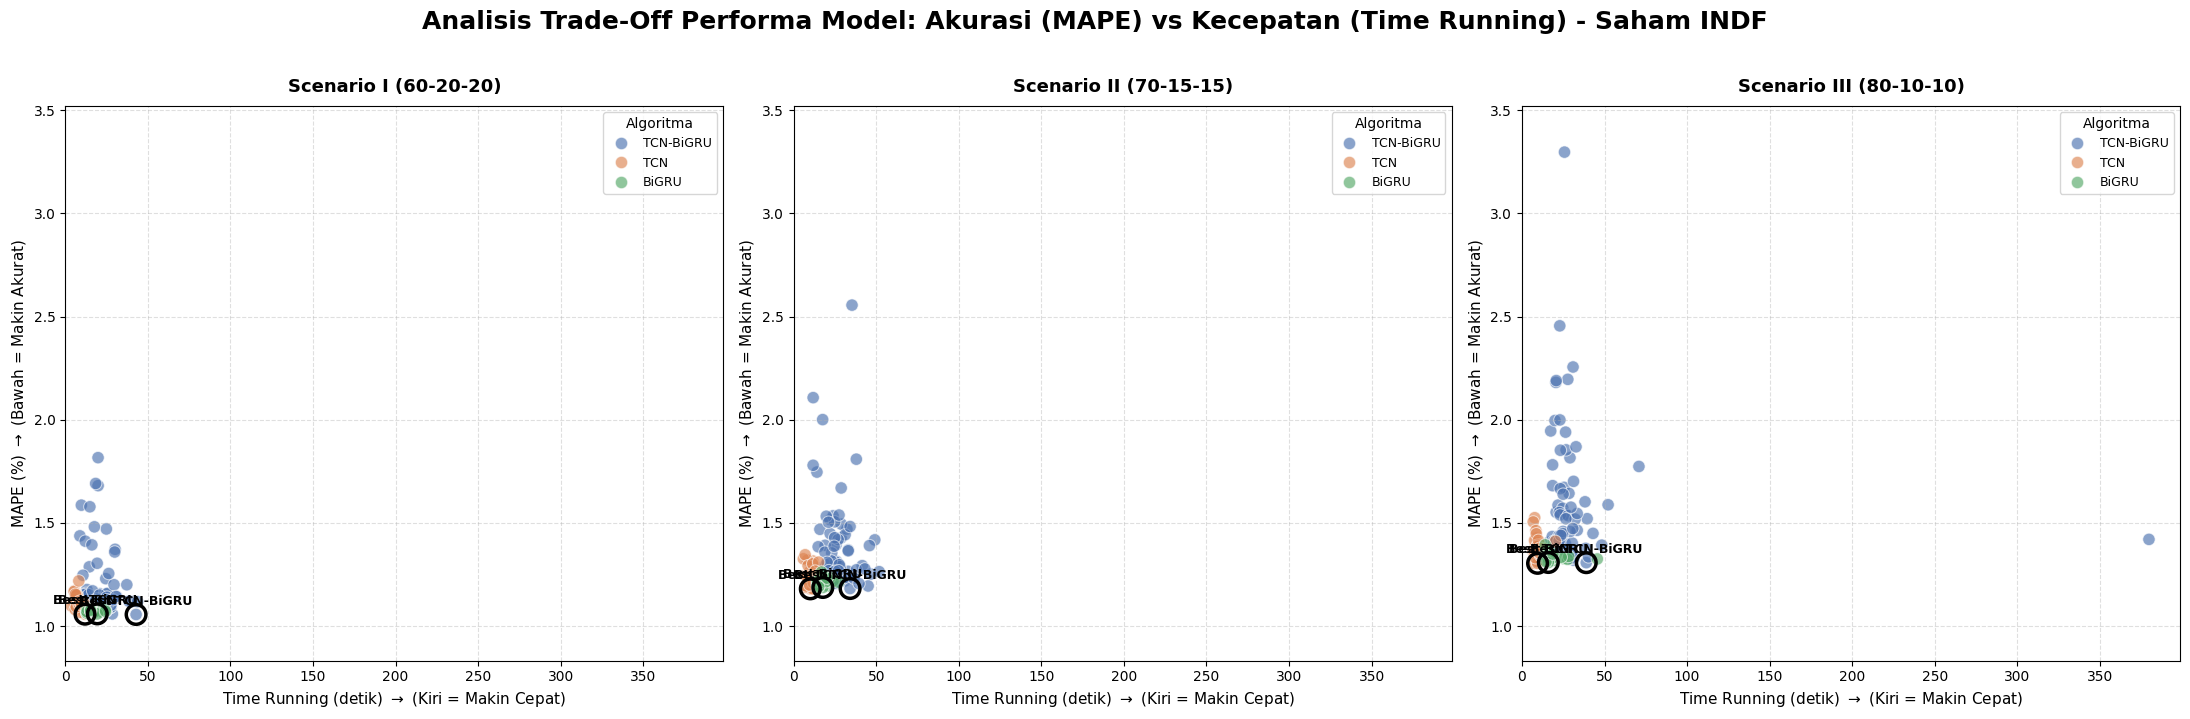

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =================================================================
# 1. READ DATA LANGSUNG DARI FILE EXCEL REKAP TUNING KAMU
# =================================================================
path_tcn_bigru = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn_bigru.xlsx"
path_tcn       = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn.xlsx"
path_bigru     = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_bigru.xlsx"

df_tcn_bigru = pd.read_excel(path_tcn_bigru)
df_tcn       = pd.read_excel(path_tcn)
df_bigru     = pd.read_excel(path_bigru)

# Beri label algoritma sebelum digabungkan
df_tcn_bigru['Algorithm'] = 'TCN-BiGRU'
df_tcn['Algorithm'] = 'TCN'
df_bigru['Algorithm'] = 'BiGRU'

# Gabungkan seluruh data percobaan
df_all = pd.concat([df_tcn_bigru, df_tcn, df_bigru], ignore_index=True)

# Definisikan mapping split dan konfigurasi visual
split_map = {
    "0.6-0.2-0.2": "Scenario I (60-20-20)",
    "0.7-0.15-0.15": "Scenario II (70-15-15)",
    "0.8-0.1-0.1": "Scenario III (80-10-10)"
}
algos = ["TCN-BiGRU", "TCN", "BiGRU"]
colors = {"TCN-BiGRU": "#4C72B0", "TCN": "#DD8452", "BiGRU": "#55A868"}

# =================================================================
# REVISI: HITUNG SKALA GLOBAL (BIAR FAIR)
# =================================================================
# Ambil min/max global dari keseluruhan data untuk sumbu X dan Y
x_min, x_max = df_all['Time (sec)'].min(), df_all['Time (sec)'].max()
y_min, y_max = df_all['MAPE (%)'].min(), df_all['MAPE (%)'].max()

# Beri sedikit padding/ruang ekstra (misal 5% untuk X, 10% untuk Y agar teks tidak terpotong)
x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.10

xlim_lower, xlim_upper = max(0, x_min - x_padding), x_max + x_padding
ylim_lower, ylim_upper = max(0, y_min - y_padding), y_max + y_padding

# =================================================================
# 2. PROSES PLOTTING GABUNGAN TRADEOFF (3 PANEL SCENARIO)
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Analisis Trade-Off Performa Model: Akurasi (MAPE) vs Kecepatan (Time Running) - Saham INDF", 
             fontsize=18, fontweight='bold', y=1.02)

for idx, (split_val, scenario_name) in enumerate(split_map.items()):
    ax = axes[idx]
    
    # Filter data khusus untuk split skenario ini
    df_scenario = df_all[df_all['Split'] == split_val].copy()
    
    # Plot scatter untuk seluruh kombinasi parameter
    sns.scatterplot(
        data=df_scenario, 
        x='Time (sec)', 
        y='MAPE (%)', 
        hue='Algorithm', 
        palette=colors,
        s=80, 
        alpha=0.65, 
        edgecolor='w',
        ax=ax
    )
    
    # Cari dan highlight titik "Top 1 Best MAPE" untuk setiap algoritma di skenario ini
    for algo in algos:
        df_algo = df_scenario[df_scenario['Algorithm'] == algo]
        if not df_algo.empty:
            # Temukan index dengan MAPE terkecil
            best_row = df_algo.loc[df_algo['MAPE (%)'].idxmin()]
            
            # Gambar lingkaran hitam tebal di titik terbaik tersebut
            ax.scatter(best_row['Time (sec)'], best_row['MAPE (%)'], 
                       s=200, facecolors='none', edgecolors='black', linewidths=2.5, zorder=5)
            
            # Tambahkan teks label penanda di atas/samping titik terbaiknya
            # REVISI: padding teks dinamis menggunakan persentase range Y global
            ax.text(best_row['Time (sec)'], best_row['MAPE (%)'] + (y_padding * 0.15), 
                    f"Best {algo}", fontsize=9, fontweight='bold', ha='center', va='bottom')

    # Kosmetik dan standarisasi visual tiap panel subplots
    ax.set_title(scenario_name, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(r"Time Running (detik) $\rightarrow$ (Kiri = Makin Cepat)", fontsize=11)
    ax.set_ylabel(r"MAPE (%) $\rightarrow$ (Bawah = Makin Akurat)", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # REVISI: Terapkan skala global yang sama untuk semua skenario
    ax.set_xlim(xlim_lower, xlim_upper)
    ax.set_ylim(ylim_lower, ylim_upper)
    
    # Atur posisi legend agar rapi di setiap panel
    ax.legend(title="Algoritma", loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

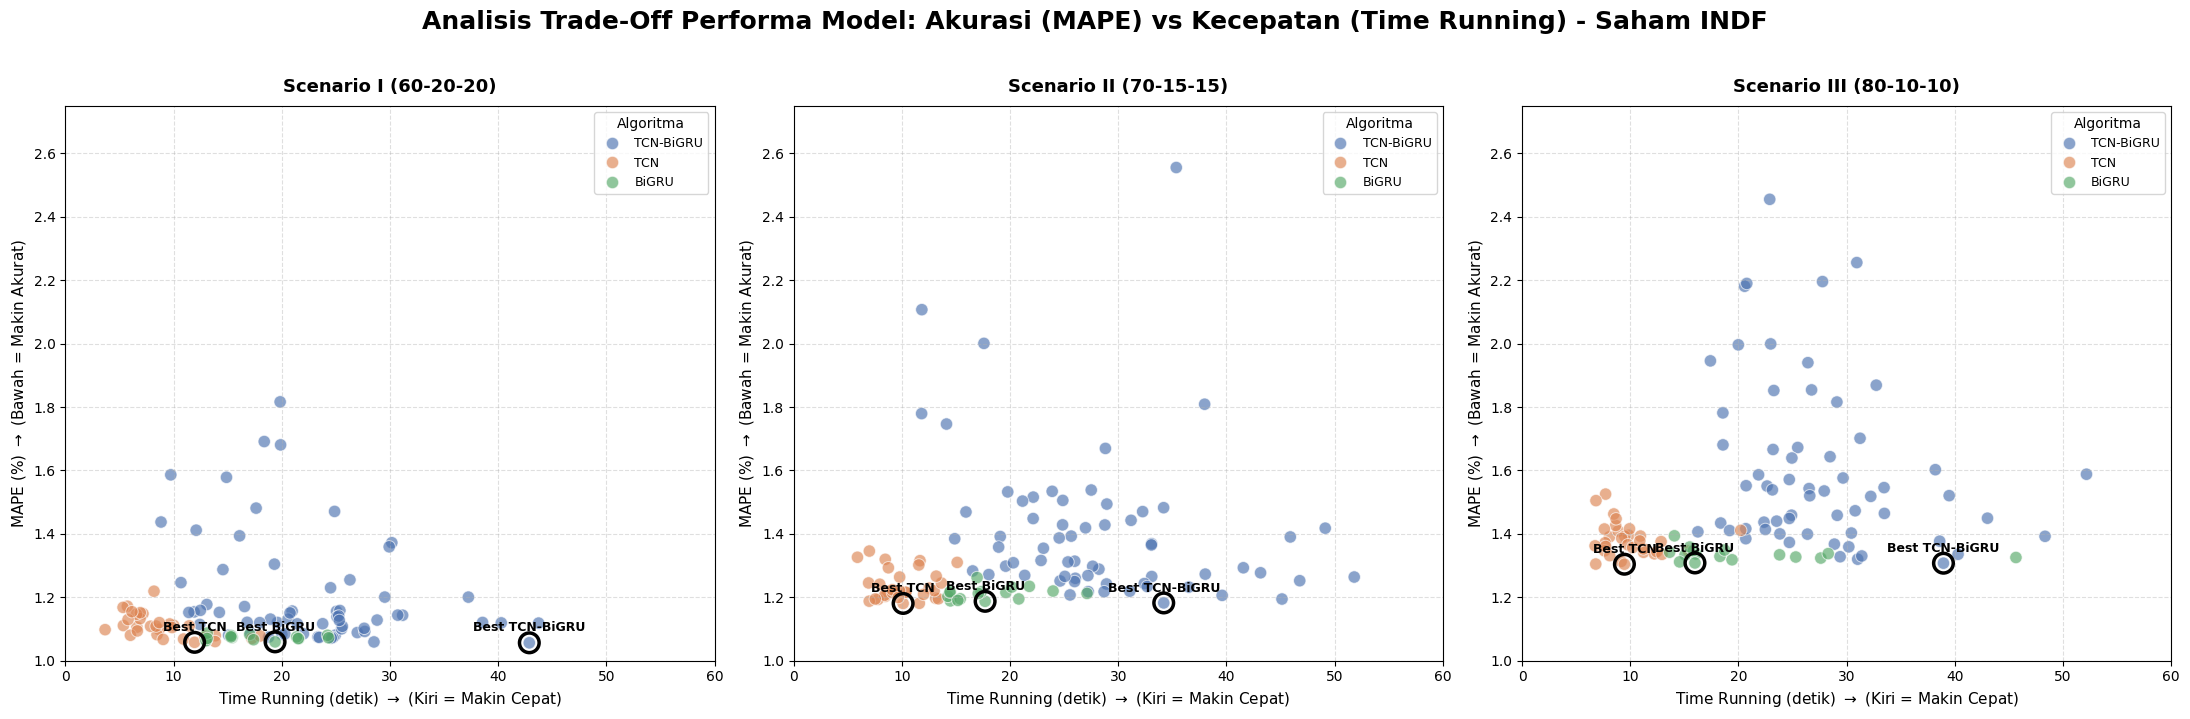

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =================================================================
# 1. READ DATA LANGSUNG DARI FILE EXCEL REKAP TUNING KAMU
# =================================================================
path_tcn_bigru = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn_bigru.xlsx"
path_tcn       = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_tcn.xlsx"
path_bigru     = "/Users/nida/Documents/#1 kulyah/TA/code/cabai/output_tunning/tabel_tuning_bigru.xlsx"

df_tcn_bigru = pd.read_excel(path_tcn_bigru)
df_tcn       = pd.read_excel(path_tcn)
df_bigru     = pd.read_excel(path_bigru)

# Beri label algoritma sebelum digabungkan
df_tcn_bigru['Algorithm'] = 'TCN-BiGRU'
df_tcn['Algorithm'] = 'TCN'
df_bigru['Algorithm'] = 'BiGRU'

# Gabungkan seluruh data percobaan
df_all = pd.concat([df_tcn_bigru, df_tcn, df_bigru], ignore_index=True)

# Definisikan mapping split dan konfigurasi visual
split_map = {
    "0.6-0.2-0.2": "Scenario I (60-20-20)",
    "0.7-0.15-0.15": "Scenario II (70-15-15)",
    "0.8-0.1-0.1": "Scenario III (80-10-10)"
}
algos = ["TCN-BiGRU", "TCN", "BiGRU"]
colors = {"TCN-BiGRU": "#4C72B0", "TCN": "#DD8452", "BiGRU": "#55A868"}

# =================================================================
# REVISI: ATUR SKALA MANUAL (MENGHILANGKAN OUTLIER)
# =================================================================
xlim_lower, xlim_upper = 0, 60   # Time Running dibatasi sampai 80 detik
ylim_lower, ylim_upper = 1, 2.75    # MAPE dibatasi dari 1% sampai 2.75%
y_padding = (ylim_upper - ylim_lower) * 0.10

# =================================================================
# 2. PROSES PLOTTING GABUNGAN TRADEOFF (3 PANEL SCENARIO)
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Analisis Trade-Off Performa Model: Akurasi (MAPE) vs Kecepatan (Time Running) - Saham INDF", 
             fontsize=18, fontweight='bold', y=1.02)

for idx, (split_val, scenario_name) in enumerate(split_map.items()):
    ax = axes[idx]
    
    # Filter data khusus untuk split skenario ini
    df_scenario = df_all[df_all['Split'] == split_val].copy()
    
    # Plot scatter untuk seluruh kombinasi parameter
    sns.scatterplot(
        data=df_scenario, 
        x='Time (sec)', 
        y='MAPE (%)', 
        hue='Algorithm', 
        palette=colors,
        s=80, 
        alpha=0.65, 
        edgecolor='w',
        ax=ax
    )
    
    # Cari dan highlight titik "Top 1 Best MAPE" untuk setiap algoritma di skenario ini
    for algo in algos:
        df_algo = df_scenario[df_scenario['Algorithm'] == algo]
        if not df_algo.empty:
            # Temukan index dengan MAPE terkecil
            best_row = df_algo.loc[df_algo['MAPE (%)'].idxmin()]
            
            # Gambar lingkaran hitam tebal di titik terbaik tersebut
            ax.scatter(best_row['Time (sec)'], best_row['MAPE (%)'], 
                       s=200, facecolors='none', edgecolors='black', linewidths=2.5, zorder=5)
            
            # Tambahkan teks label penanda di atas titik terbaiknya
            ax.text(best_row['Time (sec)'], best_row['MAPE (%)'] + (y_padding * 0.15), 
                    f"Best {algo}", fontsize=9, fontweight='bold', ha='center', va='bottom')

    # Kosmetik dan standarisasi visual tiap panel subplots
    ax.set_title(scenario_name, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(r"Time Running (detik) $\rightarrow$ (Kiri = Makin Cepat)", fontsize=11)
    ax.set_ylabel(r"MAPE (%) $\rightarrow$ (Bawah = Makin Akurat)", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Terapkan skala baru yang sudah dibatasi agar adil dan bebas outlier
    ax.set_xlim(xlim_lower, xlim_upper)
    ax.set_ylim(ylim_lower, ylim_upper)
    
    # Atur posisi legend agar rapi di setiap panel
    ax.legend(title="Algoritma", loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ===============================
# INSIGHT OTOMATIS PARAMETER
# ===============================
print("=" * 65)
print("💡 INSIGHT EFEK PARAMETER TERHADAP MAPE")
print("=" * 65)

for algo_name, df_a, param_cols in zip(
    ["TCN-BiGRU", "TCN", "BiGRU"],
    [df_tuning_tcn_bigru, df_tuning_tcn, df_tuning_bigru],
    [param_cols_map["TCN-BiGRU"], param_cols_map["TCN"], param_cols_map["BiGRU"]]
):
    print(f"\n📌 {algo_name}")
    for param in param_cols:
        grouped = df_a.groupby(param)["MAPE (%)"].mean()
        best_val  = grouped.idxmin()
        worst_val = grouped.idxmax()
        print(f"   {param.ljust(12)}: terbaik={best_val} ({grouped[best_val]:.4f}%), "
              f"terburuk={worst_val} ({grouped[worst_val]:.4f}%)")

print("=" * 65)

💡 INSIGHT EFEK PARAMETER TERHADAP MAPE

📌 TCN-BiGRU
   Filter      : terbaik=64 (1.3860%), terburuk=32 (1.4428%)
   Kernel      : terbaik=3 (1.3771%), terburuk=2 (1.4517%)
   GRU Units   : terbaik=64 (1.3724%), terburuk=32 (1.4564%)
   Batch Size  : terbaik=16 (1.3931%), terburuk=8 (1.4357%)
   LR          : terbaik=0.0015 (1.3951%), terburuk=0.001 (1.4337%)

📌 TCN
   Filter      : terbaik=64 (1.2298%), terburuk=32 (1.2559%)
   Kernel      : terbaik=2 (1.2367%), terburuk=3 (1.2489%)
   Batch Size  : terbaik=16 (1.2339%), terburuk=8 (1.2518%)
   LR          : terbaik=0.0015 (1.2421%), terburuk=0.001 (1.2436%)

📌 BiGRU
   GRU Units   : terbaik=32 (1.2058%), terburuk=64 (1.2084%)
   Batch Size  : terbaik=8 (1.2041%), terburuk=16 (1.2101%)
   LR          : terbaik=0.001 (1.2050%), terburuk=0.0015 (1.2092%)


In [ ]:
import pandas as pd
df=pd.read_csv("Data Historis INDF.csv",delimiter=";")
df['Terakhir'].describe()

count    2415.000000
mean        7.023333
std         0.792933
min         4.875000
25%         6.400000
50%         6.950000
75%         7.650000
max         9.150000
Name: Terakhir, dtype: float64